### Start of Test # 2 (19.3.26)

### Import packages

Available keys in .mat file: ['matrix']
Data shape: (68, 68)
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Fri Jan 24 14:45:59 2025', '__version__': '1.0', '__globals__': [], 'matrix': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  2.75371005, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  2.75371005,  0.        , ...,  0.        ,
         0.        ,  2.61450098],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 10.25416409],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  8.96293808],
       [ 0.        ,  0.        ,  2.61450098, ..., 10.25416409,
         8.96293808,  0.        ]])}
Time points: 68, Nodes: 68

Model fit correlation: 0.2922
Model fit distance: 0.9358
Number of iterations: 12

Fitted Jacobian eigenvalues (max real part): -2.3009

Differential e

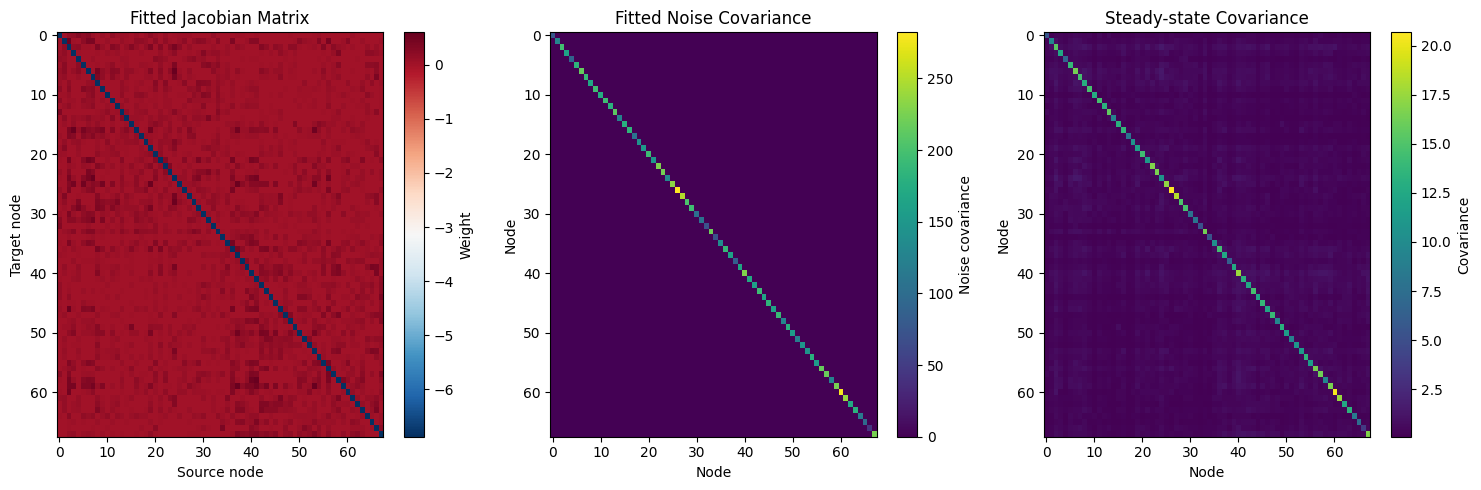

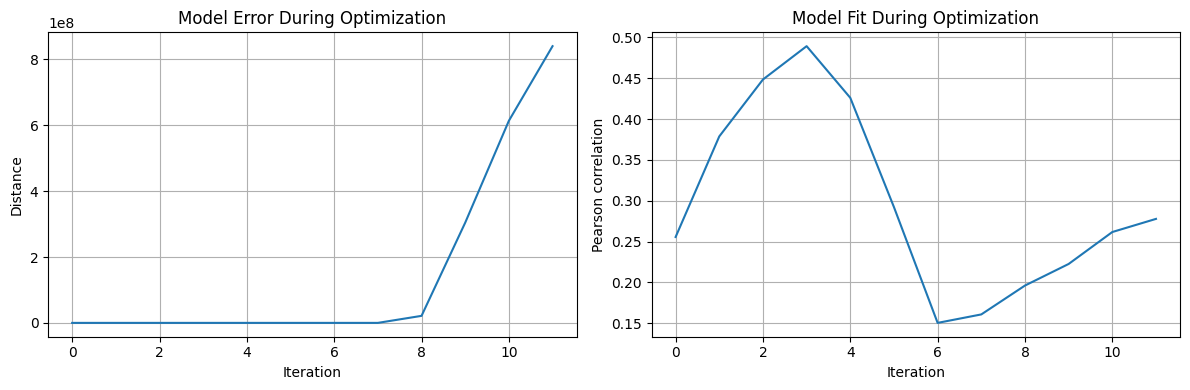

In [1]:
# Created on jan 2025
# https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012692

# numpy and scipy
import numpy as np
import scipy.stats as stt
import scipy.linalg as spl
import scipy.signal as spsg
import scipy.io as sio
from scipy.signal import welch, find_peaks
import os

# MOU model
from test_MOU_largenet import MOUv2

# classification scikit-learn
import sklearn.linear_model as skllm
import sklearn.preprocessing as skppr
import sklearn.pipeline as skppl
import sklearn.neighbors as sklnn

# plotting
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sb
import pandas as pd

import tqdm

# Import utility functions
from utils import *

#### Set up data parameters

In [2]:
data_dir = './' # data repo
res_dir = './' # results
presentation_figs_dir = 'C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\figs\\compare_emp_sim_matrices\\'
os.makedirs(presentation_figs_dir, exist_ok=True)
graph_format = 'png' # graph formatting

# data and model parameters
n_sub = 48
N = 68 # number of regions; size of network for AAL90

conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

situation_idx = 1 # set to 0 if using empirical data, to 1 if using data from the Reduced Wong-Wang model 
situations = ['empirical', 'simulated']

# Set number of time shifts for covariances Q
n_tau = 2

In [3]:
# Load data simulated with Reduced Wong-Wang model
#RWW_data_path = "c:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBOptim\\results\\simulated_bold.npy"

if situation_idx == 1: # using simulated data
    #RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\learning_rate_0.0325_max_steps_300\bold_gd.npy"
    RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_True_diagZero_False_diagZeroQ0_False\bold_gd.npy"
    TS_RWW = np.load(RWW_data_path) # for the moment only have controls
    n_subjects_RWW = TS_RWW.shape[0]
    n_conditions_RWW = TS_RWW.shape[-1]
    print(f"Simulated data shape: {TS_RWW.shape}")
    # Separate into CTR and SCZ if using simulated data
    TS_CTR = TS_RWW[:,:,:,0] 
    TS_SCZ = TS_RWW[:,:,:,1] 
    # Load empirical data for comparing and as util for reshaping simulated data
    TS_CTR_emp  = np.load('TS_Control.npy')
    print(f"Empirical data shape: {TS_CTR_emp.shape}")
    # We want to reshape into (n_subjects, n_regions, n_timepoints, n_conditions)
    n_time_points = TS_CTR_emp.shape[-1]
    new_array = TS_RWW.reshape(n_subjects_RWW, N, n_time_points, n_conditions_RWW) 
    print(f"Reshaped simulated data shape: {TS_CTR.shape}")
else:
    TS_CTR = np.load('TS_Control.npy')
    TS_SCZ = np.load('TS_Schizo.npy')
    print(f"Empirical data shape: {TS_CTR.shape}")
    # Separate the participants by condition
    condition_0 = TS_CTR[0:n_sub, 0:N, :]  # all participants (condition 0)
    condition_1 = TS_SCZ[:, 0:N, :]  # Last 48 participants (condition 1)

    # Determine the maximum number of participants in either condition (for alignment)
    max_participants = max(condition_0.shape[2], condition_1.shape[2])

    # Pad the smaller group to match the size of the larger one along the participant dimension
    condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
    condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

    # Stack the conditions along the fourth dimension
    new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

    print("New array shape:", new_array.shape)

Simulated data shape: (1, 152, 68, 2)
Empirical data shape: (116, 82, 152)
Reshaped simulated data shape: (1, 152, 68)


#### Subsampling data for testing

In [4]:
# Set to one if this is a test run with a few subjects
test_run = 1

if test_run:
    n_sub = 1

### Loading Q0, Q1 directly

In [5]:
if situation_idx == 1:  # using simulated data
    #data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_3_sub_zscore_True_diagZero_False_diagZeroQ0_True_2"
    #data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_False_diagZero_False_corrected"
    data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_True_diagZero_False_diagZeroQ0_False"
    Q0_file_name = "Q0_sim.npy"
    Q1_file_name = "Q1_sim.npy"

    Q0_file_path = os.path.join(data_path, Q0_file_name)
    Q1_file_path = os.path.join(data_path, Q1_file_name)

    Q0 = np.load(Q0_file_path)
    Q1 = np.load(Q1_file_path)
    print("Shape should be (n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q0.shape}") 
    print(f"Q1 shape: {Q1.shape}")

    ## Test : add identity (as if there was diag_zero = False)
    #for participant_idx in range(n_sub):
     #   for condition_idx in range(n_cond):
            #Q0[participant_idx, :, :, condition_idx] =  Q0[participant_idx, :, :, condition_idx] + np.eye(N)[None, :, :]
            #Q1[participant_idx, :, :, condition_idx] =  Q1[participant_idx, :, :, condition_idx] + np.eye(N)[None, :, :]

    Q_data = np.stack([Q0, Q1], axis=0)
else:
    Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
    Q1 = np.zeros((n_sub, N, N, n_cond))
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            # Get empirical time series of interest 
            ts = new_array[participant_idx,:,:,condition_idx]
            # Take the transpose for the lagged FC matrices computation
            X_emp = ts.T

            # Compute empirical lagged FC matrices
            Q_emp_single = lagged_fc_matrices(X_emp, n_tau=n_tau, diag_zero=False)
            Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
            Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

            Q0[participant_idx, :, :, condition_idx] = Q0_emp_single 
            Q1[participant_idx, :, :, condition_idx] = Q1_emp_single
    Q_data = np.stack([Q0, Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
    print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q_data.shape}")
    

Shape should be (n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (1, 68, 68, 2)
Q1 shape: (1, 68, 68, 2)


In [6]:
Q_data.shape

(2, 1, 68, 68, 2)

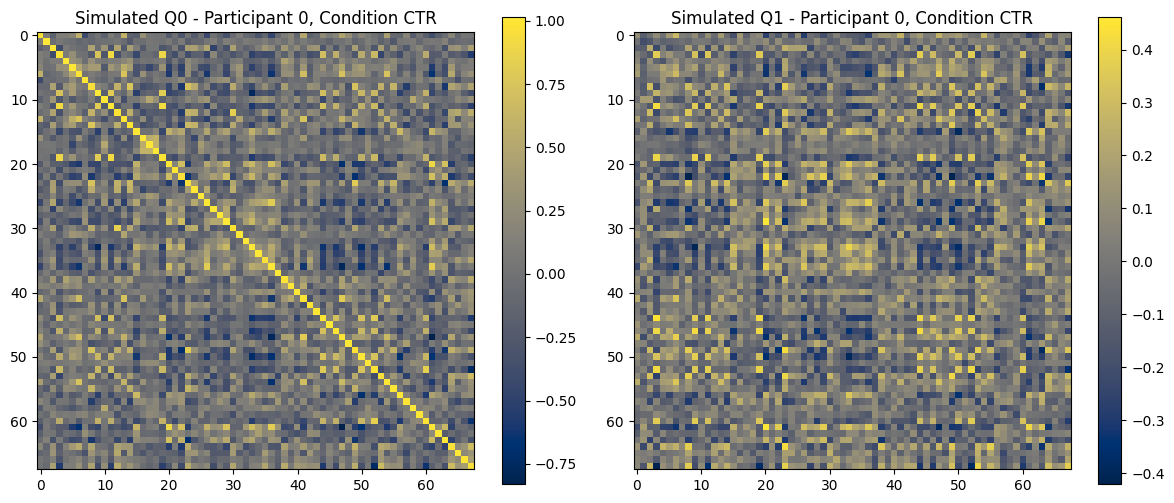

In [7]:
# Plot for one participant and condition
participant_plot = 0   
cond_plot = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(Q_data[0, participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"{situations[situation_idx].capitalize()} Q0 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(Q_data[1,participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"{situations[situation_idx].capitalize()} Q1 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.tight_layout()
plt.show()

### Start of test 1.0 : compare correlation Q0_emp/Q0_sim and Q1_emp/Q1_sim here to the ones in the results/ folder in TVBOptim

In [8]:
### TEST ; compute correlations 

#RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_3_sub_zscore_True_diagZero_False_diagZeroQ0_True_2"
#RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_False_diagZero_False_corrected"
RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\lr_0.0325_steps_300_1_sub_zscore_True_diagZero_False_diagZeroQ0_False"
RWW_Q0_file_name = "Q0_sim.npy"
RWW_Q1_file_name = "Q1_sim.npy"

Q0_file_path = os.path.join(RWW_data_path, RWW_Q0_file_name)
Q1_file_path = os.path.join(RWW_data_path, RWW_Q1_file_name)

RWW_Q0 = np.load(Q0_file_path)
RWW_Q1 = np.load(Q1_file_path)
print("Shape should be (n_subjects, n_regions, n_regions, n_conditions):")
print(f"Q0 shape: {RWW_Q0.shape}") 
print(f"Q1 shape: {RWW_Q1.shape}")

## Test : add identity (as if there was diag_zero = False)
# for participant_idx in range(n_sub):
#     for condition_idx in range(n_cond):
#         RWW_Q0[participant_idx, :, :, condition_idx] =  RWW_Q0[participant_idx, :, :, condition_idx] + np.eye(N)[None, :, :]

RWW_Q_data = np.stack([RWW_Q0, RWW_Q1], axis=0)
print("Simulated data shape:")
print(f"RWW_Q_data shape: {RWW_Q_data.shape}")

## Empirical data
TS_CTR = np.load('TS_Control.npy')
TS_SCZ = np.load('TS_Schizo.npy')
print(f"Empirical data shape: {TS_CTR.shape}")
# Separate the participants by condition
condition_0 = TS_CTR[0:n_sub, 0:N, :]  # all participants (condition 0)
condition_1 = TS_SCZ[0:n_sub, 0:N, :]  # Last 48 participants (condition 1)

# Determine the maximum number of participants in either condition (for alignment)
max_participants = max(condition_0.shape[2], condition_1.shape[2])

# Pad the smaller group to match the size of the larger one along the participant dimension
condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

# Stack the conditions along the fourth dimension
new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

emp_Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
emp_Q1 = np.zeros((n_sub, N, N, n_cond))
for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        # Get empirical time series of interest 
        ts = new_array[participant_idx,:,:,condition_idx]
        # Take the transpose for the lagged FC matrices computation
        X_emp = ts.T

        ## Test: add z-scoring and see how that goes
        # Z-score the empirical time series per region
        z_scored_emp = z_score_per_region(X_emp)
        ## End of test 

        # Compute empirical lagged FC matrices
        Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=False)
        emp_Q0[participant_idx, :, :, condition_idx] = Q_emp_single[0] 
        emp_Q1[participant_idx, :, :, condition_idx] = Q_emp_single[1]  # FC1 (lag-1)

        # Normalize the empirical FC matrices by their maximum absolute value
        # emp_Q0[participant_idx, :, :, condition_idx] /= np.max(np.abs(emp_Q0[participant_idx, :, :, condition_idx]))
        # emp_Q1[participant_idx, :, :, condition_idx] /= np.max(np.abs(emp_Q1[participant_idx, :, :, condition_idx]))

emp_Q_data = np.stack([emp_Q0, emp_Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
print(f"emp_Q0 shape: {emp_Q_data.shape}")

Shape should be (n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (1, 68, 68, 2)
Q1 shape: (1, 68, 68, 2)
Simulated data shape:
RWW_Q_data shape: (2, 1, 68, 68, 2)
Empirical data shape: (116, 82, 152)
Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):
emp_Q0 shape: (2, 1, 68, 68, 2)


### Checking symmetry of Q0

Symmetry diagnostics for empirical Q0:
 ----------
Shape: (68, 68)
Square: True
Finite: True
allclose(A, A.T): True
issymmetric tolerant: True
Max |A-A.T| off-diagonal: 3.886e-16 at (5, 64)
Relative asymmetry ||A-A.T||_F / ||A||_F: 1.038e-16
Top 10 asymmetric pairs (i, j, Aij, Aji, |diff|):
5 64 3.768e-01 3.768e-01 3.886e-16
54 64 5.164e-01 5.164e-01 3.331e-16
46 67 -4.369e-01 -4.369e-01 2.776e-16
26 64 -1.725e-01 -1.725e-01 2.776e-16
55 64 4.998e-01 4.998e-01 2.776e-16
16 65 -2.426e-01 -2.426e-01 2.220e-16
22 64 -5.212e-01 -5.212e-01 2.220e-16
8 64 5.580e-01 5.580e-01 2.220e-16
49 64 7.592e-01 7.592e-01 2.220e-16
19 67 -3.866e-01 -3.866e-01 2.220e-16


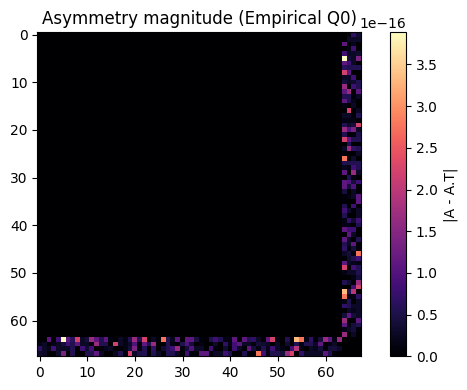

Symmetry diagnostics for RWW Q0:
 ----------
Shape: (68, 68)
Square: True
Finite: True
allclose(A, A.T): True
issymmetric tolerant: True
Max |A-A.T| off-diagonal: 5.551e-16 at (41, 64)
Relative asymmetry ||A-A.T||_F / ||A||_F: 1.285e-16
Top 10 asymmetric pairs (i, j, Aij, Aji, |diff|):
41 64 4.058e-01 4.058e-01 5.551e-16
49 67 5.564e-01 5.564e-01 5.551e-16
20 64 -5.388e-01 -5.388e-01 4.441e-16
52 67 -7.290e-01 -7.290e-01 4.441e-16
57 65 -4.203e-01 -4.203e-01 3.331e-16
44 67 -5.781e-01 -5.781e-01 3.331e-16
53 64 5.103e-01 5.103e-01 3.331e-16
60 64 -3.840e-01 -3.840e-01 3.331e-16
60 67 -6.396e-01 -6.396e-01 3.331e-16
27 64 -2.733e-01 -2.733e-01 3.331e-16


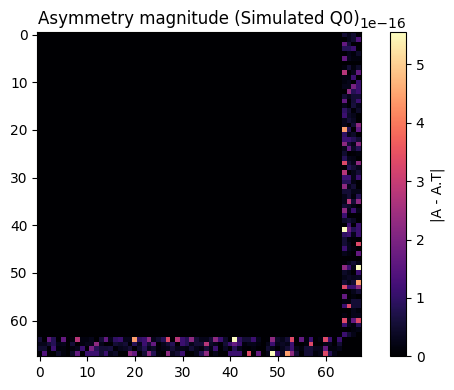

In [ ]:
def print_sym_diagnostics(Q_data_matrix, part_idx=0, cond_idx=0, sim=False, presentation_figs_dir=""):
    """
    Inputs
    -----------
    situ : bool, whether this is for simulated data (True) or empirical data (False), for title and saving purposes
    presentation_figs_dir : str, directory to save the diagnostic figure
    """
    # Set situations string for path personalization
    situations = ['empirical', 'simulated']

    # Select matrix of interest 
    A = Q_data_matrix[0, part_idx, :, :, cond_idx]

    # Print basic matrix information
    print("Shape:", A.shape)
    print("Square:", A.ndim == 2 and A.shape[0] == A.shape[1])
    print("Finite:", np.isfinite(A).all())

    # Tolerant test (better for float data)
    print("allclose(A, A.T):", np.allclose(A, A.T, atol=1e-10, rtol=1e-8, equal_nan=True))

    try:
        print("issymmetric tolerant:", spl.issymmetric(A, atol=1e-10, rtol=1e-8))
    except TypeError:
        print("Your SciPy issymmetric has no atol/rtol args; use np.allclose instead.")

    D = A - A.T
    absD = np.abs(D)
    np.fill_diagonal(absD, 0.0)

    max_diff = absD.max()
    i_max, j_max = np.unravel_index(np.argmax(absD), absD.shape)
    rel_asym = np.linalg.norm(D, "fro") / (np.linalg.norm(A, "fro") + 1e-15)

    print(f"Max |A-A.T| off-diagonal: {max_diff:.3e} at ({i_max}, {j_max})")
    print(f"Relative asymmetry ||A-A.T||_F / ||A||_F: {rel_asym:.3e}")

    # Top-k asymmetric pairs
    k = 10
    iu = np.triu_indices_from(A, k=1)
    diffs = np.abs(D[iu])
    order = np.argsort(diffs)[::-1][:k]

    print(f"Top {k} asymmetric pairs (i, j, Aij, Aji, |diff|):")

    for idx in order:
        i, j = iu[0][idx], iu[1][idx]
        print(i, j, f"{A[i, j]:.3e}", f"{A[j, i]:.3e}", f"{abs(A[i, j] - A[j, i]):.3e}")

    # Visual diagnostic
    fig = plt.figure(figsize=(6, 4))
    plt.imshow(absD, cmap="magma")
    plt.colorbar(label="|A - A.T|")
    if sim:
        plt.title("Asymmetry magnitude (Simulated Q0)")
    else:
        plt.title("Asymmetry magnitude (Empirical Q0)")
    plt.tight_layout()
    fig_path = os.path.join(presentation_figs_dir, f"asymmetric_indexes_{situations[sim]}_sub{part_idx}_cond{cond_idx}.png")
    fig.savefig(fig_path, format="png", dpi=300)
    plt.show()
    plt.close(fig)

A = emp_Q_data[0, participant_plot, :, :, cond_plot]
B = RWW_Q_data[0, participant_plot, :, :, cond_plot]

print("Symmetry diagnostics for empirical Q0:\n", "-"*10)
print_sym_diagnostics(emp_Q_data, part_idx=participant_plot, cond_idx=cond_plot, sim=False, presentation_figs_dir=presentation_figs_dir)
print("Symmetry diagnostics for RWW Q0:\n", "-"*10)
print_sym_diagnostics(RWW_Q_data, part_idx=participant_plot, cond_idx=cond_plot, sim=True, presentation_figs_dir=presentation_figs_dir)


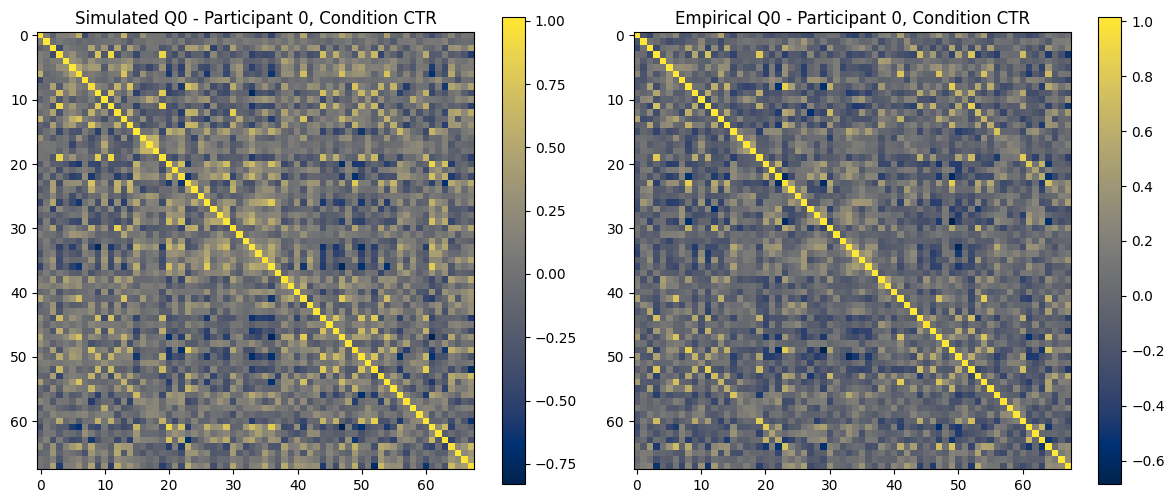

In [10]:
# Plot for one participant and condition
participant_plot = 0   
cond_plot = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(RWW_Q0[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Simulated Q0 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(emp_Q0[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Empirical Q0 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.tight_layout()
plt.show()

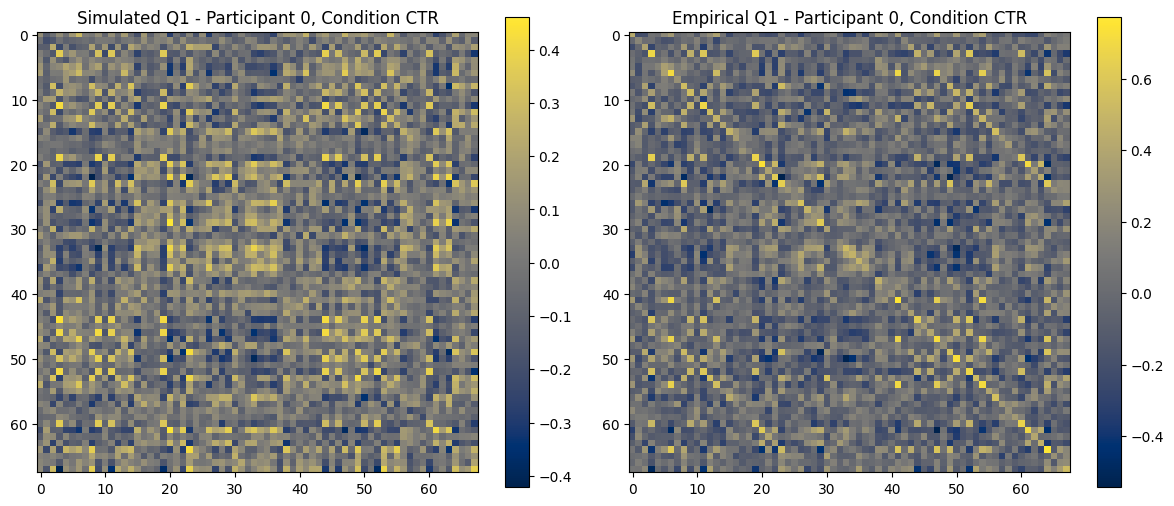

In [11]:
# Plot for one participant and condition
participant_plot = 0   
cond_plot = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(RWW_Q1[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Simulated Q1 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(emp_Q1[participant_plot, :, :, cond_plot], cmap='cividis')
plt.title(f"Empirical Q1 - Participant {participant_plot}, Condition {conds[cond_plot]}")
plt.colorbar()
plt.tight_layout()
plt.show()

Participant 0, Condition 0:
Correlation for Q0: 0.8995
Correlation for Q1: 0.8173


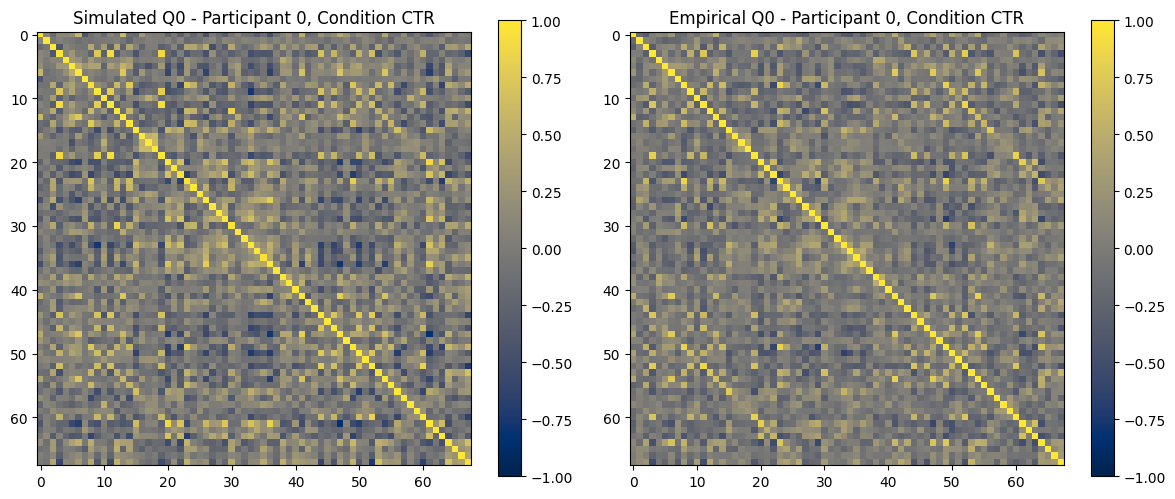

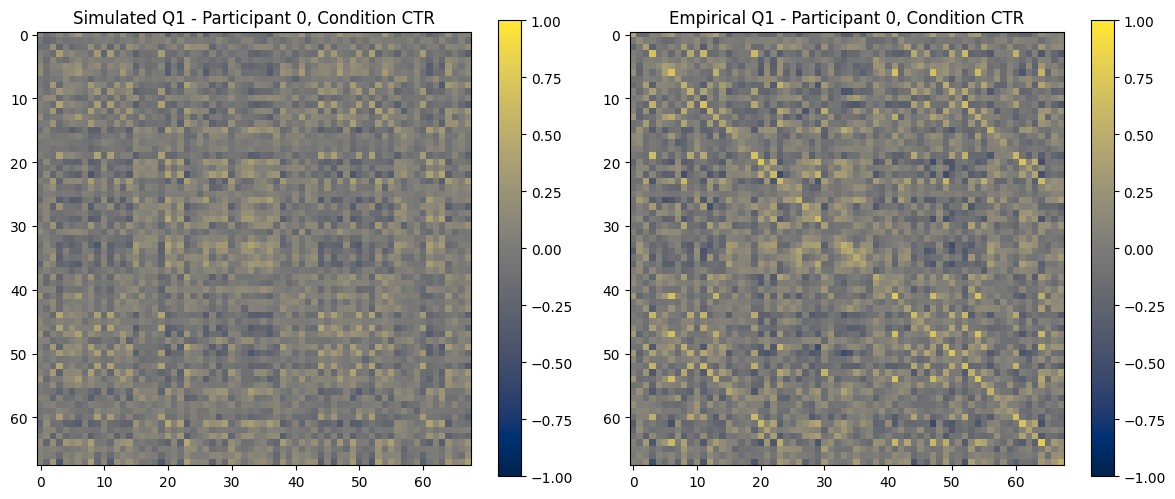

Participant 0, Condition 1:
Correlation for Q0: 0.9071
Correlation for Q1: 0.7843


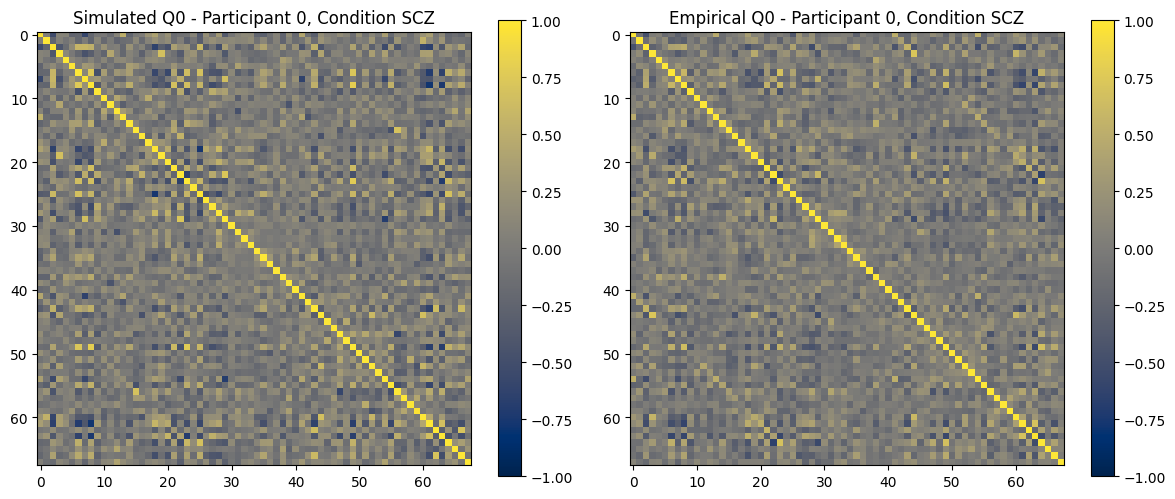

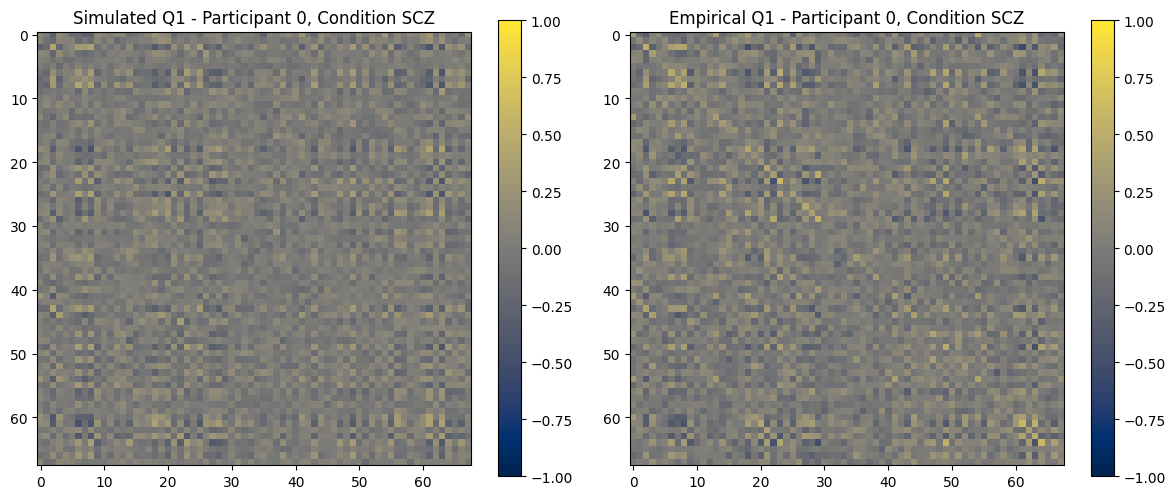

In [12]:
## Compute correlations between simulated and empirical FC0 and FC1 matrices for each participant and condition
for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        correlation_Q0_temp = np.corrcoef(RWW_Q0[participant_idx, :, :, condition_idx].flatten(), emp_Q0[participant_idx, :, :, condition_idx].flatten())
        correlation_Q1_temp = np.corrcoef(RWW_Q1[participant_idx, :, :, condition_idx].flatten(), emp_Q1[participant_idx, :, :, condition_idx].flatten())
        print(f"Participant {participant_idx}, Condition {condition_idx}:")
        print(f"Correlation for Q0: {correlation_Q0_temp[0, 1]:.4f}")
        print(f"Correlation for Q1: {correlation_Q1_temp[0, 1]:.4f}")
        # Plot Q0
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(RWW_Q0[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Simulated Q0 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.subplot(1, 2, 2)
        plt.imshow(emp_Q0[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Empirical Q0 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()
        # Plot Q1 
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(RWW_Q1[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Simulated Q1 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.subplot(1, 2, 2)
        plt.imshow(emp_Q1[participant_idx, :, :, condition_idx], vmin=-1, vmax=1, cmap='cividis')
        plt.title(f"Empirical Q1 - Participant {participant_idx}, Condition {conds[condition_idx]}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

### Histogram of values: empirical versus simulated


# ----------
Histogram of values 
 ----------


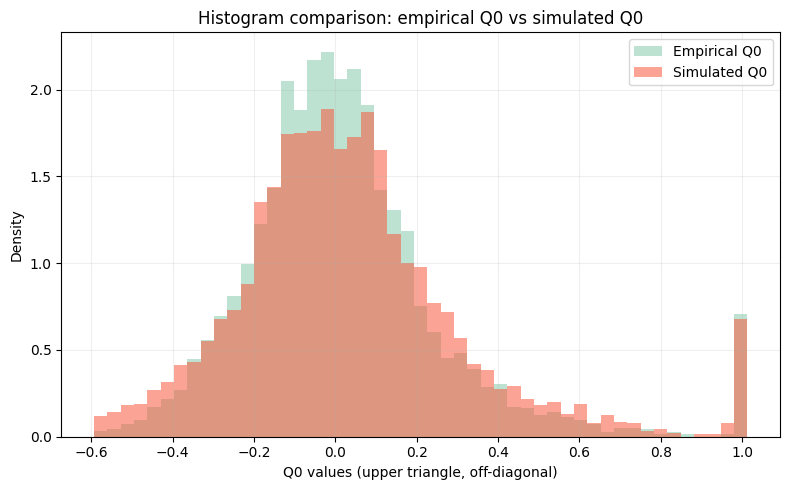

Bin size = 0.033, #bins = 50
Saved figure: C:\Users\Bruna\Documents\Cogmaster\M2\Stage\figs\compare_emp_sim_matrices\hist_Q0_emp_vs_sim.png

# ----------
Proportion of positives versus negatives 
 ----------
Q0 sign proportions (upper triangle selection)
diagonal_offset = 0 (0 includes diagonal, 1 excludes diagonal)
eps = 1e-12

Empirical Q0
  n_total: 4692
  positives: 2307 (49.17%)
  negatives: 2385 (50.83%)
  near-zero: 0 (0.00%)

Simulated Q0
  n_total: 4692
  positives: 2373 (50.58%)
  negatives: 2319 (49.42%)
  near-zero: 0 (0.00%)

Difference (Sim - Emp), in percentage points
  positives: 1.41 pp
  negatives: -1.41 pp
  near-zero: 0.00 pp


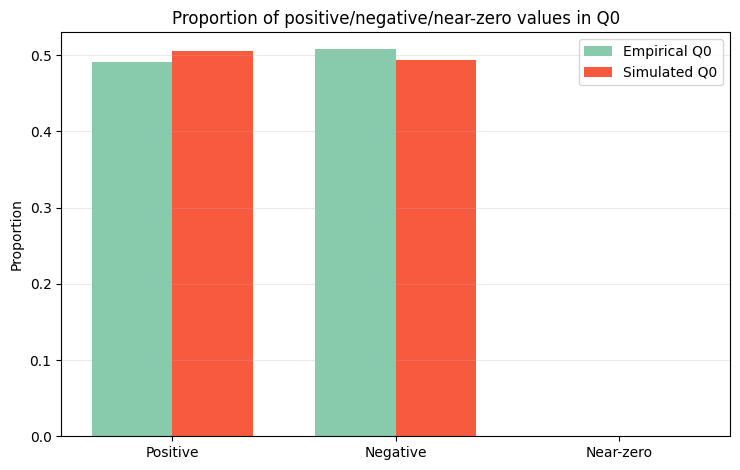

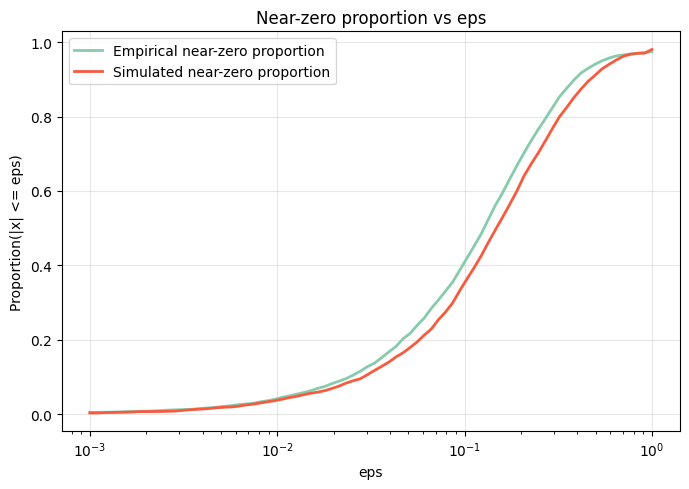

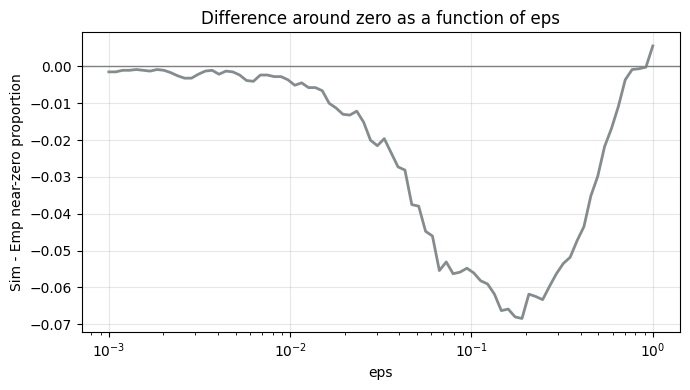

In [23]:
# Q0 matrices: expected shape (n_sub, N, N, n_cond)
Q0_emp = emp_Q_data[0]
Q0_sim = RWW_Q_data[0]

# Compare upper-triangle values 
diagonal_offset = 0 # Set to 1 if want to count the elements above the diagonal only, 0 if you want to include the diagonal
N = Q0_emp.shape[1] # Should be equal to 68 if using the DK atlas 
iu = np.triu_indices(N, k=diagonal_offset)

emp_vals = Q0_emp[:, iu[0], iu[1], :].ravel()
sim_vals = Q0_sim[:, iu[0], iu[1], :].ravel()

# Keep finite values only
emp_vals = emp_vals[np.isfinite(emp_vals)]
sim_vals = sim_vals[np.isfinite(sim_vals)]

# Shared bins for fair comparison
all_vals = np.concatenate([emp_vals, sim_vals])
vmin, vmax = np.percentile(all_vals, [0.5, 99.5])
n_bins = 50
bins = np.linspace(vmin, vmax, n_bins)

bin_size = (vmax - vmin) / (n_bins - 1)

print("\n#", "-"*10)
print("Histogram of values", "\n", "-"*10)

color_palette = ["#87CBAC", "#F85A3E"]
plt.figure(figsize=(8, 5))
plt.hist(emp_vals, bins=bins, density=True, alpha=0.55, label="Empirical Q0", color=color_palette[0])
plt.hist(sim_vals, bins=bins, density=True, alpha=0.55, label="Simulated Q0", color=color_palette[1])
plt.xlabel("Q0 values (upper triangle, off-diagonal)")
plt.ylabel("Density")
plt.title(f"Histogram comparison: empirical Q0 vs simulated Q0")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

fig_path = os.path.join(presentation_figs_dir, "hist_Q0_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Bin size = {bin_size:.3f}, #bins = {n_bins}")
print("Saved figure:", fig_path)

## Compute proportions of positive, negative, and near-zero values in the upper triangle of Q0 for empirical and simulated data
print("\n#", "-"*10)
print("Proportion of positives versus negatives", "\n", "-"*10)
# small tolerance around zero (to avoid tiny numerical noise being counted as +/-)
eps = 1e-12

def sign_proportions(x, eps=1e-12):
    n = x.size
    n_pos = np.sum(x > eps)
    n_neg = np.sum(x < -eps)
    n_zero = np.sum(np.abs(x) <= eps)
    return {
        "n_total": int(n),
        "n_pos": int(n_pos),
        "n_neg": int(n_neg),
        "n_zero": int(n_zero),
        "prop_pos": n_pos / n,
        "prop_neg": n_neg / n,
        "prop_zero": n_zero / n,
    }

emp_stats = sign_proportions(emp_vals, eps=eps)
sim_stats = sign_proportions(sim_vals, eps=eps)

# -------- Print summary --------
print("Q0 sign proportions (upper triangle selection)")
print(f"diagonal_offset = {diagonal_offset} (0 includes diagonal, 1 excludes diagonal)")
print(f"eps = {eps}\n")

print("Empirical Q0")
print(f"  n_total: {emp_stats['n_total']}")
print(f"  positives: {emp_stats['n_pos']} ({100*emp_stats['prop_pos']:.2f}%)")
print(f"  negatives: {emp_stats['n_neg']} ({100*emp_stats['prop_neg']:.2f}%)")
print(f"  near-zero: {emp_stats['n_zero']} ({100*emp_stats['prop_zero']:.2f}%)\n")

print("Simulated Q0")
print(f"  n_total: {sim_stats['n_total']}")
print(f"  positives: {sim_stats['n_pos']} ({100*sim_stats['prop_pos']:.2f}%)")
print(f"  negatives: {sim_stats['n_neg']} ({100*sim_stats['prop_neg']:.2f}%)")
print(f"  near-zero: {sim_stats['n_zero']} ({100*sim_stats['prop_zero']:.2f}%)\n")

print("Difference (Sim - Emp), in percentage points")
print(f"  positives: {(sim_stats['prop_pos'] - emp_stats['prop_pos'])*100:.2f} pp")
print(f"  negatives: {(sim_stats['prop_neg'] - emp_stats['prop_neg'])*100:.2f} pp")
print(f"  near-zero: {(sim_stats['prop_zero'] - emp_stats['prop_zero'])*100:.2f} pp")

# -------- Bar plot comparison --------
labels = ["Positive", "Negative", "Near-zero"]
emp_props = [emp_stats["prop_pos"], emp_stats["prop_neg"], emp_stats["prop_zero"]]
sim_props = [sim_stats["prop_pos"], sim_stats["prop_neg"], sim_stats["prop_zero"]]

x = np.arange(len(labels))
w = 0.36

plt.figure(figsize=(7.5, 4.8))
plt.bar(x - w/2, emp_props, width=w, label="Empirical Q0", color=color_palette[0])
plt.bar(x + w/2, sim_props, width=w, label="Simulated Q0", color=color_palette[1])
plt.xticks(x, labels)
plt.ylabel("Proportion")
plt.ylim(0, 0.53)
plt.title("Proportion of positive/negative/near-zero values in Q0")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

fig_path = os.path.join(presentation_figs_dir, "barplot_Q0_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# Near-zero focus
eps_grid = np.logspace(-3, 0, 80)
emp_near = [np.mean(np.abs(emp_vals) <= e) for e in eps_grid]
sim_near = [np.mean(np.abs(sim_vals) <= e) for e in eps_grid]

plt.figure(figsize=(7,5))
plt.semilogx(eps_grid, emp_near, label="Empirical near-zero proportion", lw=2, color=color_palette[0])
plt.semilogx(eps_grid, sim_near, label="Simulated near-zero proportion", lw=2, color=color_palette[1])
plt.xlabel("eps")
plt.ylabel("Proportion(|x| <= eps)")
plt.title("Near-zero proportion vs eps")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
fig_path = os.path.join(presentation_figs_dir, "nearzero_prop_Q0_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Difference in near-zero proportions
plt.figure(figsize=(7,4))
plt.semilogx(eps_grid, np.array(sim_near) - np.array(emp_near), lw=2, color = "#848C8E")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("eps")
plt.ylabel("Sim - Emp near-zero proportion")
plt.title("Difference around zero as a function of eps")
plt.grid(alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(presentation_figs_dir, "nearzero_diff_Q0_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ----------
Histogram of values 
 ----------


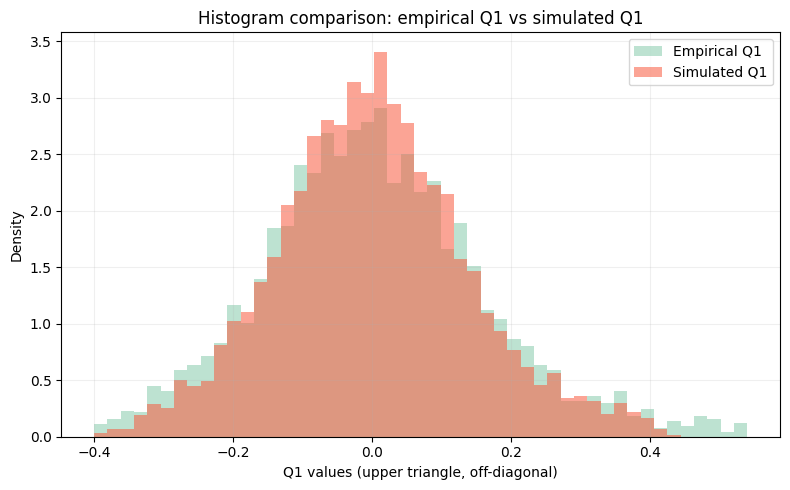

Bin size = 0.019, #bins = 50
Saved figure: C:\Users\Bruna\Documents\Cogmaster\M2\Stage\figs\compare_emp_sim_matrices\hist_Q1_emp_vs_sim.png

# ----------
Proportion of positives versus negatives 
 ----------
Q1 sign proportions (upper triangle selection)
diagonal_offset = 0 (0 includes diagonal, 1 excludes diagonal)
eps = 1e-12

Empirical Q0
  n_total: 4692
  positives: 2297 (48.96%)
  negatives: 2395 (51.04%)
  near-zero: 0 (0.00%)

Simulated Q0
  n_total: 4692
  positives: 2310 (49.23%)
  negatives: 2382 (50.77%)
  near-zero: 0 (0.00%)

Difference (Sim - Emp), in percentage points
  positives: 0.28 pp
  negatives: -0.28 pp
  near-zero: 0.00 pp


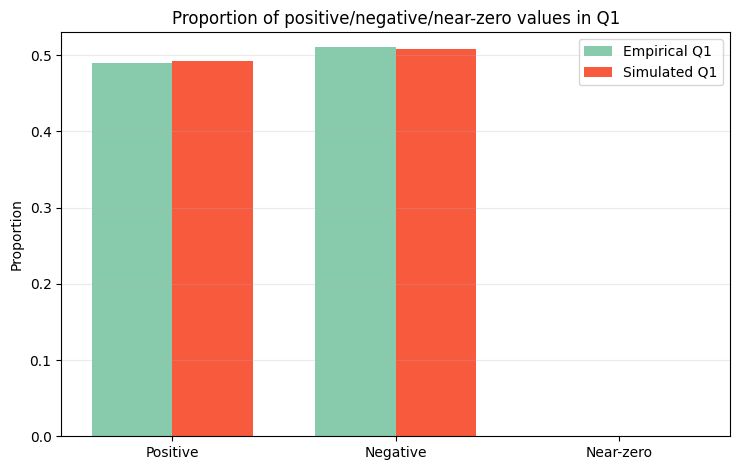

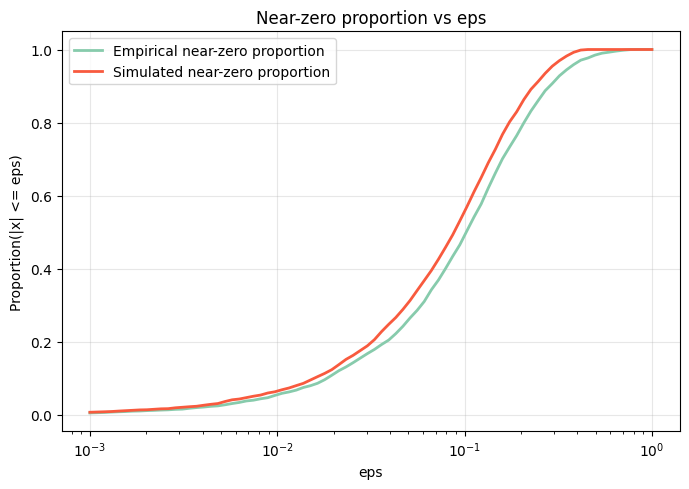

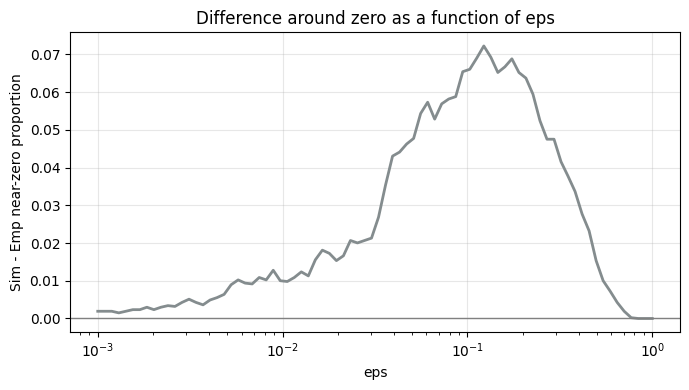

In [24]:
# Q1 matrices: expected shape (n_sub, N, N, n_cond)
Q1_emp = emp_Q_data[1]
Q1_sim = RWW_Q_data[1]

emp_vals = Q1_emp[:, iu[0], iu[1], :].ravel()
sim_vals = Q1_sim[:, iu[0], iu[1], :].ravel()

# Keep finite values only
emp_vals = emp_vals[np.isfinite(emp_vals)]
sim_vals = sim_vals[np.isfinite(sim_vals)]

# Shared bins for fair comparison
all_vals = np.concatenate([emp_vals, sim_vals])
vmin, vmax = np.percentile(all_vals, [0.5, 99.5])
n_bins = 50
bins = np.linspace(vmin, vmax, n_bins)

bin_size = (vmax - vmin) / (n_bins - 1)

color_palette = ["#87CBAC", "#F85A3E"]

print("\n#", "-"*10)
print("Histogram of values", "\n", "-"*10)

plt.figure(figsize=(8, 5))
plt.hist(emp_vals, bins=bins, density=True, alpha=0.55, label="Empirical Q1", color=color_palette[0])
plt.hist(sim_vals, bins=bins, density=True, alpha=0.55, label="Simulated Q1", color=color_palette[1])
plt.xlabel("Q1 values (upper triangle, off-diagonal)")
plt.ylabel("Density")
plt.title(f"Histogram comparison: empirical Q1 vs simulated Q1")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

fig_path = os.path.join(presentation_figs_dir, "hist_Q1_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Bin size = {bin_size:.3f}, #bins = {n_bins}")
print("Saved figure:", fig_path)

## Compute proportions of positive, negative, and near-zero values in the upper triangle of Q0 for empirical and simulated data
print("\n#", "-"*10)
print("Proportion of positives versus negatives", "\n", "-"*10)

emp_stats = sign_proportions(emp_vals, eps=eps)
sim_stats = sign_proportions(sim_vals, eps=eps)

# -------- Print summary --------
print("Q1 sign proportions (upper triangle selection)")
print(f"diagonal_offset = {diagonal_offset} (0 includes diagonal, 1 excludes diagonal)")
print(f"eps = {eps}\n")

print("Empirical Q0")
print(f"  n_total: {emp_stats['n_total']}")
print(f"  positives: {emp_stats['n_pos']} ({100*emp_stats['prop_pos']:.2f}%)")
print(f"  negatives: {emp_stats['n_neg']} ({100*emp_stats['prop_neg']:.2f}%)")
print(f"  near-zero: {emp_stats['n_zero']} ({100*emp_stats['prop_zero']:.2f}%)\n")

print("Simulated Q0")
print(f"  n_total: {sim_stats['n_total']}")
print(f"  positives: {sim_stats['n_pos']} ({100*sim_stats['prop_pos']:.2f}%)")
print(f"  negatives: {sim_stats['n_neg']} ({100*sim_stats['prop_neg']:.2f}%)")
print(f"  near-zero: {sim_stats['n_zero']} ({100*sim_stats['prop_zero']:.2f}%)\n")

print("Difference (Sim - Emp), in percentage points")
print(f"  positives: {(sim_stats['prop_pos'] - emp_stats['prop_pos'])*100:.2f} pp")
print(f"  negatives: {(sim_stats['prop_neg'] - emp_stats['prop_neg'])*100:.2f} pp")
print(f"  near-zero: {(sim_stats['prop_zero'] - emp_stats['prop_zero'])*100:.2f} pp")

# -------- Bar plot comparison --------
labels = ["Positive", "Negative", "Near-zero"]
emp_props = [emp_stats["prop_pos"], emp_stats["prop_neg"], emp_stats["prop_zero"]]
sim_props = [sim_stats["prop_pos"], sim_stats["prop_neg"], sim_stats["prop_zero"]]

x = np.arange(len(labels))
w = 0.36

plt.figure(figsize=(7.5, 4.8))
plt.bar(x - w/2, emp_props, width=w, label="Empirical Q1", color=color_palette[0])
plt.bar(x + w/2, sim_props, width=w, label="Simulated Q1", color=color_palette[1])
plt.xticks(x, labels)
plt.ylabel("Proportion")
plt.ylim(0, 0.53)
plt.title("Proportion of positive/negative/near-zero values in Q1")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig_path = os.path.join(presentation_figs_dir, "barplot_Q1_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Near-zero focus
eps_grid = np.logspace(-3, 0, 80)
emp_near = [np.mean(np.abs(emp_vals) <= e) for e in eps_grid]
sim_near = [np.mean(np.abs(sim_vals) <= e) for e in eps_grid]

plt.figure(figsize=(7,5))
plt.semilogx(eps_grid, emp_near, label="Empirical near-zero proportion", lw=2, color = color_palette[0])
plt.semilogx(eps_grid, sim_near, label="Simulated near-zero proportion", lw=2, color = color_palette[1])
plt.xlabel("eps")
plt.ylabel("Proportion(|x| <= eps)")
plt.title("Near-zero proportion vs eps")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
fig_path = os.path.join(presentation_figs_dir, "nearzero_prop_Q1_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Difference in near-zero proportions
plt.figure(figsize=(7,4))
plt.semilogx(eps_grid, np.array(sim_near) - np.array(emp_near), lw=2, color = "#848C8E")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("eps")
plt.ylabel("Sim - Emp near-zero proportion")
plt.title("Difference around zero as a function of eps")
plt.grid(alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(presentation_figs_dir, "nearzero_diff_Q1_emp_vs_sim.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### GW distance between empirical and simulated Q (one subject, one condition)
Convert Q matrices into valid distance matrices, then compute Gromov-Wasserstein distance.

--- GW comparison ---
tau_idx=0, sub_idx=0, cond_idx=0
distance_method=kernel_euclidean
normalize_distances=True (scales: emp=1.435, sim=1.421)
GW^2 = 2.692080e-02
GW   = 1.640756e-01
Coupling check (sum T): 1.000000
max asymmetry C_emp: 2.220e-16
max asymmetry C_sim: 2.220e-16
min value C_emp: 0.000e+00, min value C_sim: 0.000e+00


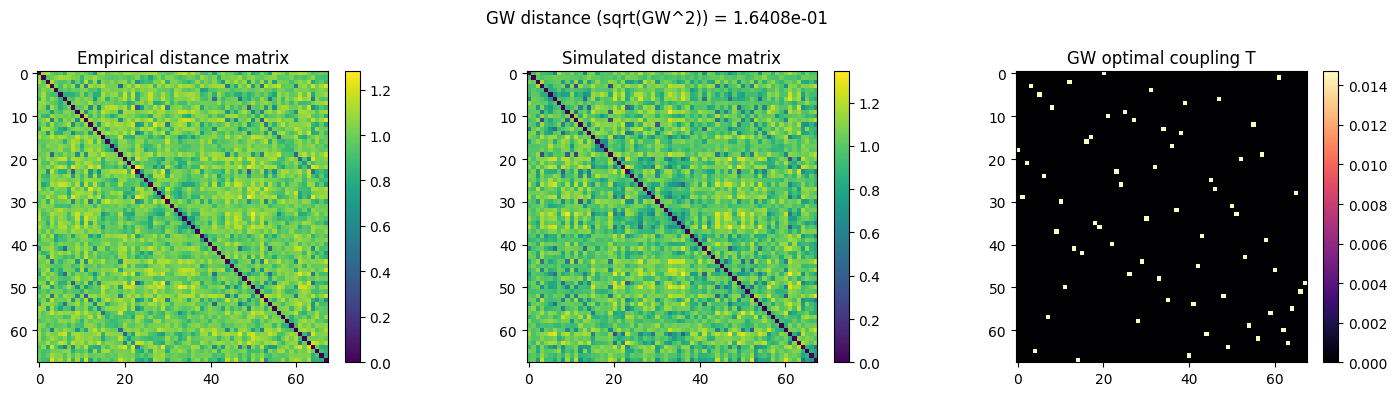

In [142]:
import ot

# -----------------------
# User choices
# -----------------------
tau_idx = 0       # 0 for Q0, 1 for Q1
sub_idx = 0        # subject index
cond_idx = 0       # condition index (0=CTR, 1=SCZ in your setup)
distance_method = "kernel_euclidean"  # "kernel_euclidean" or "minmax_affinity"
normalize_distances = True

# Select matrices with shape (N, N)
Q_emp = emp_Q_data[tau_idx, sub_idx, :, :, cond_idx].astype(float)
Q_sim = RWW_Q_data[tau_idx, sub_idx, :, :, cond_idx].astype(float)

def nearest_psd(A, eps=1e-10):
    """Project a symmetric matrix to the nearest PSD matrix by eigenvalue clipping."""
    A = 0.5 * (A + A.T)
    w, V = np.linalg.eigh(A)
    w_clipped = np.clip(w, eps, None)
    return (V * w_clipped) @ V.T

def q_to_distance(Q, method="kernel_euclidean", ensure_psd=True, eps=1e-12):
    """Convert Q-like similarity/covariance matrix into a nonnegative symmetric distance matrix."""
    Q = np.array(Q, dtype=float, copy=True)

    # Clean and symmetrize
    Q = np.nan_to_num(Q, nan=0.0, posinf=0.0, neginf=0.0)
    Q = 0.5 * (Q + Q.T)

    if method == "kernel_euclidean":
        # For covariance/kernel-like matrices: d_ij^2 = q_ii + q_jj - 2 q_ij
        K = nearest_psd(Q, eps=eps) if ensure_psd else Q
        diag = np.diag(K)
        D2 = diag[:, None] + diag[None, :] - 2.0 * K
        D2 = np.maximum(D2, 0.0)
        D = np.sqrt(D2)

    elif method == "minmax_affinity":
        # Generic fallback: map large affinity -> small distance in [0, 1]
        Qmin, Qmax = np.min(Q), np.max(Q)
        if np.isclose(Qmax, Qmin):
            D = np.zeros_like(Q)
        else:
            S = (Q - Qmin) / (Qmax - Qmin)
            D = 1.0 - S
        D = 0.5 * (D + D.T)

    else:
        raise ValueError("Unknown method. Use 'kernel_euclidean' or 'minmax_affinity'.")

    np.fill_diagonal(D, 0.0)
    D = np.maximum(D, 0.0)
    return D

def scale_distance_matrix(D, eps=1e-12):
    """Scale by median non-zero distance so empirical/simulated are on comparable scales."""
    D = D.copy()
    vals = D[np.triu_indices_from(D, k=1)]
    vals = vals[vals > eps]
    scale = np.median(vals) if vals.size > 0 else 1.0
    if not np.isfinite(scale) or scale <= eps:
        scale = 1.0
    return D / scale, scale

# Convert to distance matrices
C_emp = q_to_distance(Q_emp, method=distance_method, ensure_psd=True)
C_sim = q_to_distance(Q_sim, method=distance_method, ensure_psd=True)

if normalize_distances:
    C_emp, s_emp = scale_distance_matrix(C_emp)
    C_sim, s_sim = scale_distance_matrix(C_sim)
else:
    s_emp, s_sim = 1.0, 1.0

# Uniform node masses (same N on both sides)
n1 = C_emp.shape[0]
n2 = C_sim.shape[0]
p = np.ones(n1) / n1
q = np.ones(n2) / n2

# Compute GW distance and optimal coupling
gw2, log = ot.gromov.gromov_wasserstein2(
    C_emp, C_sim, p, q, loss_fun="square_loss", log=True
    )
T = log["T"]
gw = np.sqrt(max(gw2, 0.0))

print("--- GW comparison ---")
print(f"tau_idx={tau_idx}, sub_idx={sub_idx}, cond_idx={cond_idx}")
print(f"distance_method={distance_method}")
print(f"normalize_distances={normalize_distances} (scales: emp={s_emp:.4g}, sim={s_sim:.4g})")
print(f"GW^2 = {gw2:.6e}")
print(f"GW   = {gw:.6e}")
print(f"Coupling check (sum T): {T.sum():.6f}")

# Diagnostics on converted distances
sym_emp = np.max(np.abs(C_emp - C_emp.T))
sym_sim = np.max(np.abs(C_sim - C_sim.T))
print(f"max asymmetry C_emp: {sym_emp:.3e}")
print(f"max asymmetry C_sim: {sym_sim:.3e}")
print(f"min value C_emp: {C_emp.min():.3e}, min value C_sim: {C_sim.min():.3e}")

# Quick visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im0 = ax[0].imshow(C_emp, cmap="viridis")
ax[0].set_title("Empirical distance matrix")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(C_sim, cmap="viridis")
ax[1].set_title("Simulated distance matrix")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(T, cmap="magma")
ax[2].set_title("GW optimal coupling T")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.suptitle(f"GW distance (sqrt(GW^2)) = {gw:.4e}")
plt.tight_layout()
plt.show()

--- Combined GW summary ---
sub_idx=0, cond_idx=0
distance_method=kernel_euclidean, normalize_distances=True


,metric,GW2,GW,emp_scale,sim_scale
0,Q0 (symmetric part),0.026921,0.164076,1.435471,1.421237
1,Q1 symmetric part,0.074191,0.272379,0.979341,0.690497
2,Q1 antisymmetric magnitude,0.019875,0.140978,0.394266,0.360113


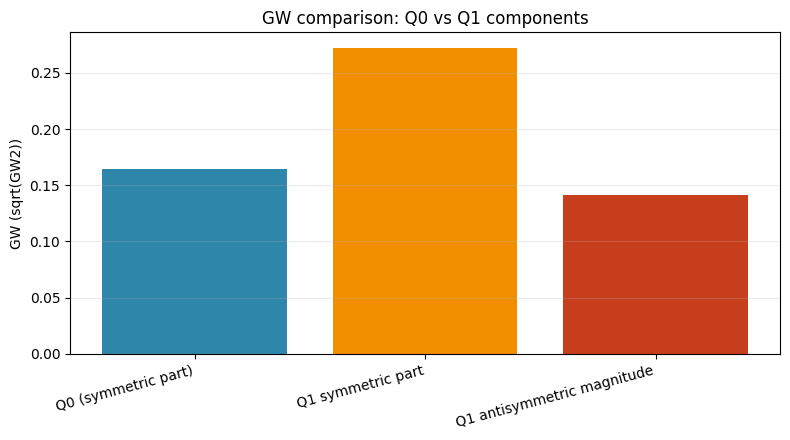

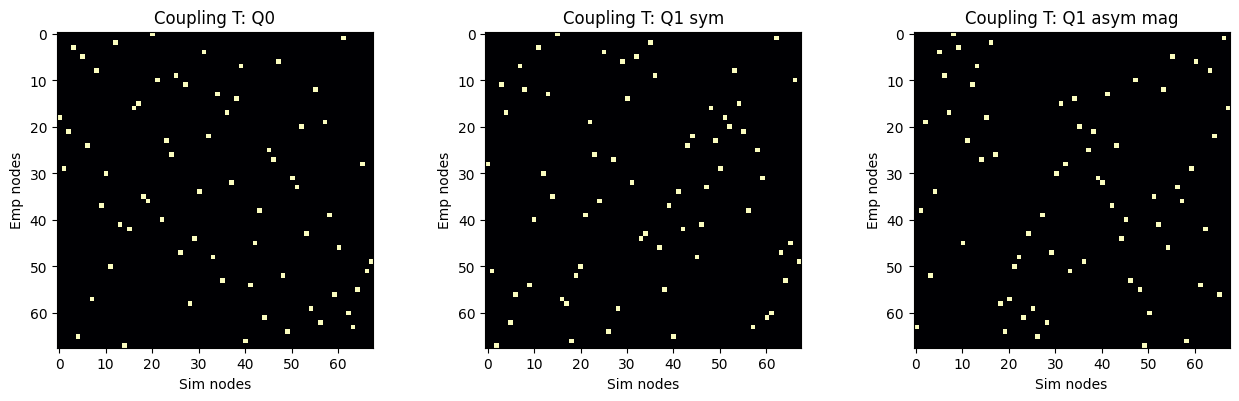

In [143]:
# Combined GW comparison: Q0, symmetric Q1, antisymmetric magnitude of Q1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ot

# -----------------------
# User choices
# -----------------------
sub_idx = 0
cond_idx = 0
normalize_distances = True
distance_method = "kernel_euclidean"  # "kernel_euclidean" or "minmax_affinity"

def nearest_psd(A, eps=1e-10):
    A = 0.5 * (A + A.T)
    w, V = np.linalg.eigh(A)
    w = np.clip(w, eps, None)
    return (V * w) @ V.T

def q_to_distance(Q, method="kernel_euclidean", ensure_psd=True, eps=1e-12):
    Q = np.array(Q, dtype=float, copy=True)
    Q = np.nan_to_num(Q, nan=0.0, posinf=0.0, neginf=0.0)
    Q = 0.5 * (Q + Q.T)

    if method == "kernel_euclidean":
        K = nearest_psd(Q, eps=eps) if ensure_psd else Q
        d = np.diag(K)
        D2 = d[:, None] + d[None, :] - 2.0 * K
        D2 = np.maximum(D2, 0.0)
        D = np.sqrt(D2)
    elif method == "minmax_affinity":
        qmin, qmax = np.min(Q), np.max(Q)
        if np.isclose(qmax, qmin):
            D = np.zeros_like(Q)
        else:
            S = (Q - qmin) / (qmax - qmin)
            D = 1.0 - S
        D = 0.5 * (D + D.T)
    else:
        raise ValueError("Unknown method. Use 'kernel_euclidean' or 'minmax_affinity'.")

    np.fill_diagonal(D, 0.0)
    return np.maximum(D, 0.0)

def scale_distance_matrix(D, eps=1e-12):
    vals = D[np.triu_indices_from(D, k=1)]
    vals = vals[vals > eps]
    scale = np.median(vals) if vals.size > 0 else 1.0
    if not np.isfinite(scale) or scale <= eps:
        scale = 1.0
    return D / scale, scale

def gw_distance_from_structures(S_emp, S_sim, normalize=True, method="kernel_euclidean"):
    C_emp = q_to_distance(S_emp, method=method, ensure_psd=True)
    C_sim = q_to_distance(S_sim, method=method, ensure_psd=True)

    if normalize:
        C_emp, s_emp = scale_distance_matrix(C_emp)
        C_sim, s_sim = scale_distance_matrix(C_sim)
    else:
        s_emp, s_sim = 1.0, 1.0

    n1, n2 = C_emp.shape[0], C_sim.shape[0]
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2

    gw2, log = ot.gromov.gromov_wasserstein2(
        C_emp, C_sim, p, q, loss_fun="square_loss", log=True
    )
    gw = np.sqrt(max(gw2, 0.0))
    return gw2, gw, log["T"], C_emp, C_sim, s_emp, s_sim

# Extract one subject + condition
Q0_emp = emp_Q_data[0, sub_idx, :, :, cond_idx]
Q0_sim = RWW_Q_data[0, sub_idx, :, :, cond_idx]
Q1_emp = emp_Q_data[1, sub_idx, :, :, cond_idx]
Q1_sim = RWW_Q_data[1, sub_idx, :, :, cond_idx]

# Build the three structures to compare
Q0_emp_sym = 0.5 * (Q0_emp + Q0_emp.T)
Q0_sim_sym = 0.5 * (Q0_sim + Q0_sim.T)

Q1_emp_sym = 0.5 * (Q1_emp + Q1_emp.T)
Q1_sim_sym = 0.5 * (Q1_sim + Q1_sim.T)

Q1_emp_asym_mag = np.abs(0.5 * (Q1_emp - Q1_emp.T))
Q1_sim_asym_mag = np.abs(0.5 * (Q1_sim - Q1_sim.T))
np.fill_diagonal(Q1_emp_asym_mag, 0.0)
np.fill_diagonal(Q1_sim_asym_mag, 0.0)

# Compute GW metrics
gw2_q0, gw_q0, T_q0, C0_emp, C0_sim, s0e, s0s = gw_distance_from_structures(
    Q0_emp_sym, Q0_sim_sym, normalize=normalize_distances, method=distance_method
)
gw2_q1_sym, gw_q1_sym, T_q1_sym, C1s_emp, C1s_sim, s1se, s1ss = gw_distance_from_structures(
    Q1_emp_sym, Q1_sim_sym, normalize=normalize_distances, method=distance_method
)
gw2_q1_asym, gw_q1_asym, T_q1_asym, C1a_emp, C1a_sim, s1ae, s1as = gw_distance_from_structures(
    Q1_emp_asym_mag, Q1_sim_asym_mag, normalize=normalize_distances, method=distance_method
)

summary_df = pd.DataFrame([
    {
        "metric": "Q0 (symmetric part)",
        "GW2": gw2_q0,
        "GW": gw_q0,
        "emp_scale": s0e,
        "sim_scale": s0s,
    },
    {
        "metric": "Q1 symmetric part",
        "GW2": gw2_q1_sym,
        "GW": gw_q1_sym,
        "emp_scale": s1se,
        "sim_scale": s1ss,
    },
    {
        "metric": "Q1 antisymmetric magnitude",
        "GW2": gw2_q1_asym,
        "GW": gw_q1_asym,
        "emp_scale": s1ae,
        "sim_scale": s1as,
    },
])

print("--- Combined GW summary ---")
print(f"sub_idx={sub_idx}, cond_idx={cond_idx}")
print(f"distance_method={distance_method}, normalize_distances={normalize_distances}")
display(summary_df)

plt.figure(figsize=(8, 4.5))
plt.bar(summary_df["metric"], summary_df["GW"], color=["#2E86AB", "#F18F01", "#C73E1D"])
plt.ylabel("GW (sqrt(GW2))")
plt.title("GW comparison: Q0 vs Q1 components")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Optional: visualize couplings
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(T_q0, cmap="magma")
ax[0].set_title("Coupling T: Q0")
ax[1].imshow(T_q1_sym, cmap="magma")
ax[1].set_title("Coupling T: Q1 sym")
ax[2].imshow(T_q1_asym, cmap="magma")
ax[2].set_title("Coupling T: Q1 asym mag")
for a in ax:
    a.set_xlabel("Sim nodes")
    a.set_ylabel("Emp nodes")
plt.tight_layout()
plt.show()

Computed GW metrics for all available subject-condition pairs.
n_sub=1, n_cond=2, total rows=6


,subject,condition,condition_idx,metric,GW2,GW,emp_scale,sim_scale
0,0,CTR,0,Q0 (symmetric part),0.026921,0.164076,1.435471,1.421237
1,0,CTR,0,Q1 symmetric part,0.074191,0.272379,0.979341,0.690497
2,0,CTR,0,Q1 antisymmetric magnitude,0.019875,0.140978,0.394266,0.360113
3,0,SCZ,1,Q0 (symmetric part),0.019689,0.140318,1.419508,1.417784
4,0,SCZ,1,Q1 symmetric part,0.098059,0.313144,0.808335,0.612612
5,0,SCZ,1,Q1 antisymmetric magnitude,0.018002,0.134171,0.432603,0.375158



Condition-level summary:


,condition,metric,mean_GW,std_GW,median_GW
0,CTR,Q0 (symmetric part),0.164076,NaN,0.164076
1,CTR,Q1 antisymmetric magnitude,0.140978,NaN,0.140978
2,CTR,Q1 symmetric part,0.272379,NaN,0.272379
3,SCZ,Q0 (symmetric part),0.140318,NaN,0.140318
4,SCZ,Q1 antisymmetric magnitude,0.134171,NaN,0.134171
5,SCZ,Q1 symmetric part,0.313144,NaN,0.313144


C:\Users\Bruna\AppData\Local\Temp\ipykernel_22048\3883746760.py:165: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


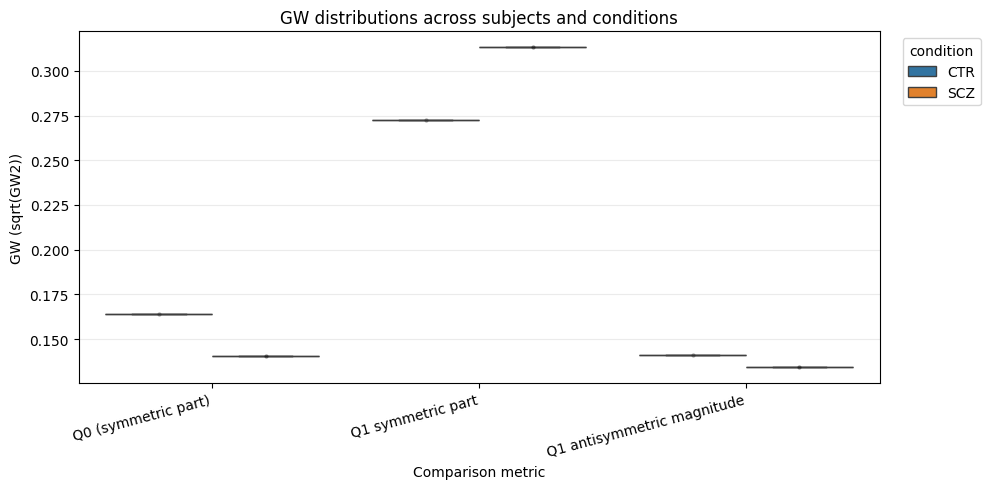

In [144]:
# Batch GW comparison across all subjects and conditions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ot

# -----------------------
# User choices
# -----------------------
distance_method = "kernel_euclidean"  # "kernel_euclidean" or "minmax_affinity"
normalize_distances = True

# Infer dimensions from loaded arrays
n_sub_eff = min(emp_Q_data.shape[1], RWW_Q_data.shape[1])
n_cond_eff = min(emp_Q_data.shape[-1], RWW_Q_data.shape[-1])

def nearest_psd(A, eps=1e-10):
    A = 0.5 * (A + A.T)
    w, V = np.linalg.eigh(A)
    w = np.clip(w, eps, None)
    return (V * w) @ V.T

def q_to_distance(Q, method="kernel_euclidean", ensure_psd=True, eps=1e-12):
    Q = np.array(Q, dtype=float, copy=True)
    Q = np.nan_to_num(Q, nan=0.0, posinf=0.0, neginf=0.0)
    Q = 0.5 * (Q + Q.T)

    if method == "kernel_euclidean":
        K = nearest_psd(Q, eps=eps) if ensure_psd else Q
        d = np.diag(K)
        D2 = d[:, None] + d[None, :] - 2.0 * K
        D2 = np.maximum(D2, 0.0)
        D = np.sqrt(D2)
    elif method == "minmax_affinity":
        qmin, qmax = np.min(Q), np.max(Q)
        if np.isclose(qmax, qmin):
            D = np.zeros_like(Q)
        else:
            S = (Q - qmin) / (qmax - qmin)
            D = 1.0 - S
        D = 0.5 * (D + D.T)
    else:
        raise ValueError("Unknown method. Use 'kernel_euclidean' or 'minmax_affinity'.")

    np.fill_diagonal(D, 0.0)
    return np.maximum(D, 0.0)

def scale_distance_matrix(D, eps=1e-12):
    vals = D[np.triu_indices_from(D, k=1)]
    vals = vals[vals > eps]
    scale = np.median(vals) if vals.size > 0 else 1.0
    if not np.isfinite(scale) or scale <= eps:
        scale = 1.0
    return D / scale, scale

def gw_distance_from_structures(S_emp, S_sim, normalize=True, method="kernel_euclidean"):
    C_emp = q_to_distance(S_emp, method=method, ensure_psd=True)
    C_sim = q_to_distance(S_sim, method=method, ensure_psd=True)

    if normalize:
        C_emp, s_emp = scale_distance_matrix(C_emp)
        C_sim, s_sim = scale_distance_matrix(C_sim)
    else:
        s_emp, s_sim = 1.0, 1.0

    n1, n2 = C_emp.shape[0], C_sim.shape[0]
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2

    gw2, _ = ot.gromov.gromov_wasserstein2(
        C_emp, C_sim, p, q, loss_fun="square_loss", log=True
    )
    gw = np.sqrt(max(gw2, 0.0))
    return gw2, gw, s_emp, s_sim

records = []
for sub_idx in range(n_sub_eff):
    for cond_idx in range(n_cond_eff):
        Q0_emp = emp_Q_data[0, sub_idx, :, :, cond_idx]
        Q0_sim = RWW_Q_data[0, sub_idx, :, :, cond_idx]
        Q1_emp = emp_Q_data[1, sub_idx, :, :, cond_idx]
        Q1_sim = RWW_Q_data[1, sub_idx, :, :, cond_idx]

        # Q0 comparison (symmetric part)
        Q0_emp_sym = 0.5 * (Q0_emp + Q0_emp.T)
        Q0_sim_sym = 0.5 * (Q0_sim + Q0_sim.T)
        gw2_q0, gw_q0, s0e, s0s = gw_distance_from_structures(
            Q0_emp_sym, Q0_sim_sym, normalize=normalize_distances, method=distance_method
        )

        # Q1 symmetric comparison
        Q1_emp_sym = 0.5 * (Q1_emp + Q1_emp.T)
        Q1_sim_sym = 0.5 * (Q1_sim + Q1_sim.T)
        gw2_q1_sym, gw_q1_sym, s1se, s1ss = gw_distance_from_structures(
            Q1_emp_sym, Q1_sim_sym, normalize=normalize_distances, method=distance_method
        )

        # Q1 directional magnitude comparison
        Q1_emp_asym_mag = np.abs(0.5 * (Q1_emp - Q1_emp.T))
        Q1_sim_asym_mag = np.abs(0.5 * (Q1_sim - Q1_sim.T))
        np.fill_diagonal(Q1_emp_asym_mag, 0.0)
        np.fill_diagonal(Q1_sim_asym_mag, 0.0)
        gw2_q1_asym, gw_q1_asym, s1ae, s1as = gw_distance_from_structures(
            Q1_emp_asym_mag, Q1_sim_asym_mag, normalize=normalize_distances, method=distance_method
        )

        cond_label = conds[cond_idx] if cond_idx < len(conds) else f"cond_{cond_idx}"

        records.extend([
            {
                "subject": sub_idx,
                "condition": cond_label,
                "condition_idx": cond_idx,
                "metric": "Q0 (symmetric part)",
                "GW2": gw2_q0,
                "GW": gw_q0,
                "emp_scale": s0e,
                "sim_scale": s0s,
            },
            {
                "subject": sub_idx,
                "condition": cond_label,
                "condition_idx": cond_idx,
                "metric": "Q1 symmetric part",
                "GW2": gw2_q1_sym,
                "GW": gw_q1_sym,
                "emp_scale": s1se,
                "sim_scale": s1ss,
            },
            {
                "subject": sub_idx,
                "condition": cond_label,
                "condition_idx": cond_idx,
                "metric": "Q1 antisymmetric magnitude",
                "GW2": gw2_q1_asym,
                "GW": gw_q1_asym,
                "emp_scale": s1ae,
                "sim_scale": s1as,
            },
        ])

gw_all_df = pd.DataFrame.from_records(records)

print("Computed GW metrics for all available subject-condition pairs.")
print(f"n_sub={n_sub_eff}, n_cond={n_cond_eff}, total rows={len(gw_all_df)}")
display(gw_all_df.head(12))

summary_by_condition = (
    gw_all_df.groupby(["condition", "metric"], as_index=False)
    .agg(
        mean_GW=("GW", "mean"),
        std_GW=("GW", "std"),
        median_GW=("GW", "median"),
    )
    .sort_values(["condition", "metric"])
    .reset_index(drop=True)
)

print("\nCondition-level summary:")
display(summary_by_condition)

plt.figure(figsize=(10, 5))
sns.boxplot(data=gw_all_df, x="metric", y="GW", hue="condition")
sns.stripplot(
    data=gw_all_df, x="metric", y="GW", hue="condition",
    dodge=True, alpha=0.45, color="black", size=3
    )

# Keep one legend only
handles, labels = plt.gca().get_legend_handles_labels()
if len(labels) > 0:
    unique = dict(zip(labels[:len(labels)//2], handles[:len(handles)//2]))
    plt.legend(unique.values(), unique.keys(), title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.title("GW distributions across subjects and conditions")
plt.xlabel("Comparison metric")
plt.ylabel("GW (sqrt(GW2))")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Computed norms for all available subject-condition pairs.
n_sub=1, n_cond=2, total rows=2


,subject,condition,condition_idx,fro_norm,relative_fro_norm,l1_norm,l2_norm
0,0,CTR,0,8.811018,0.499516,468.989375,4.403139
1,0,SCZ,1,7.130095,0.467345,380.760390,2.647908



Condition-level summary:


,condition,mean_fro,std_fro,mean_rel_fro,std_rel_fro
0,CTR,8.811018,NaN,0.499516,NaN
1,SCZ,7.130095,NaN,0.467345,NaN


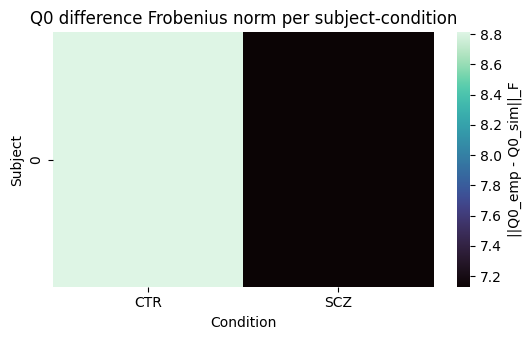

In [146]:
# Norm of the difference between empirical Q0 and simulated Q0 (all subject-condition pairs)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Q0 arrays: shape expected (n_sub, N, N, n_cond)
Q0_emp_all = emp_Q_data[0]
Q0_sim_all = RWW_Q_data[0]

# Handle possible shape mismatch safely
n_sub_eff = min(Q0_emp_all.shape[0], Q0_sim_all.shape[0])
n_cond_eff = min(Q0_emp_all.shape[-1], Q0_sim_all.shape[-1])

records = []
for sub_idx in range(n_sub_eff):
    for cond_idx in range(n_cond_eff):
        E = Q0_emp_all[sub_idx, :, :, cond_idx]
        S = Q0_sim_all[sub_idx, :, :, cond_idx]
        D = E - S

        fro_norm = np.linalg.norm(D, ord="fro")
        l1_norm = np.sum(np.abs(D))
        l2_norm = np.linalg.norm(D, ord=2)
        rel_fro = fro_norm / (np.linalg.norm(E, ord="fro") + 1e-12)

        cond_label = conds[cond_idx] if cond_idx < len(conds) else f"cond_{cond_idx}"
        records.append(
            {
                "subject": sub_idx,
                "condition": cond_label,
                "condition_idx": cond_idx,
                "fro_norm": fro_norm,
                "relative_fro_norm": rel_fro,
                "l1_norm": l1_norm,
                "l2_norm": l2_norm,
            }
        )

q0_norms_df = pd.DataFrame(records)

print("Computed norms for all available subject-condition pairs.")
print(f"n_sub={n_sub_eff}, n_cond={n_cond_eff}, total rows={len(q0_norms_df)}")
display(q0_norms_df.head(12))

summary_norms = (
    q0_norms_df.groupby("condition", as_index=False)
    .agg(
        mean_fro=("fro_norm", "mean"),
        std_fro=("fro_norm", "std"),
        mean_rel_fro=("relative_fro_norm", "mean"),
        std_rel_fro=("relative_fro_norm", "std"),
    )
    .sort_values("condition")
    .reset_index(drop=True)
)

print("\nCondition-level summary:")
display(summary_norms)

# Heatmap: Frobenius norm per (subject, condition)
heat_df = q0_norms_df.pivot(index="subject", columns="condition", values="fro_norm")
plt.figure(figsize=(5.5, max(3.5, 0.25 * n_sub_eff + 1.5)))
sns.heatmap(heat_df, cmap="mako", annot=False, cbar_kws={"label": "||Q0_emp - Q0_sim||_F"})
plt.title("Q0 difference Frobenius norm per subject-condition")
plt.xlabel("Condition")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

In [160]:
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True

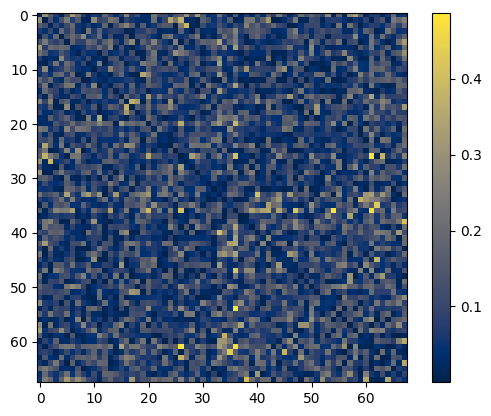

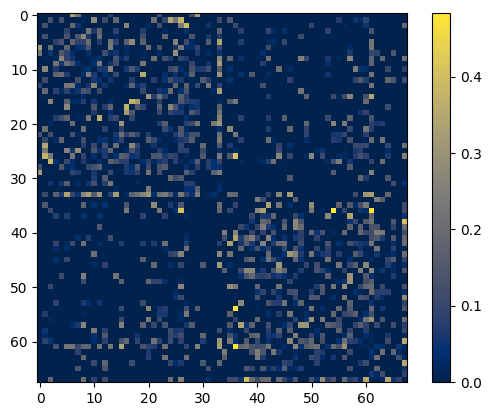

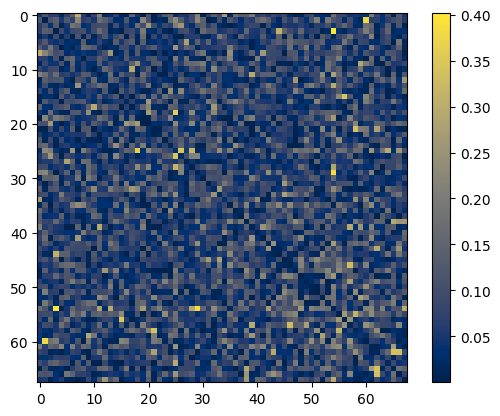

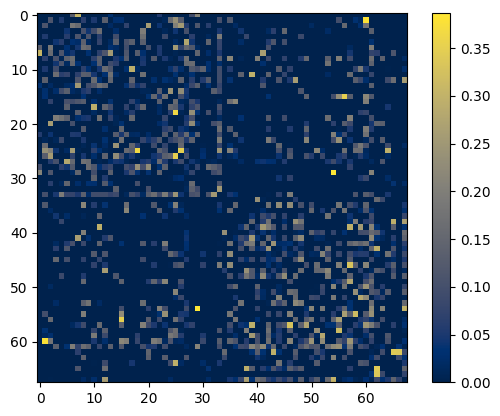

In [162]:
for sub_idx in range(n_sub):
    for cond_idx in range(n_cond):
        # Where are the biggest difference values between empirical and simulated 
        plt.imshow(abs(Q0_emp_all[sub_idx, :, :, cond_idx] - Q0_sim_all[sub_idx, :, :, cond_idx]), cmap="cividis")
        plt.colorbar()
        plt.show()
        # Plot intersection between big difference values and structural connectivity
        diff_and_SC = abs(Q0_emp_all[sub_idx, :, :, cond_idx] - Q0_sim_all[sub_idx, :, :, cond_idx]) * mask_EC
        plt.imshow(diff_and_SC, cmap="cividis")
        plt.colorbar()
        plt.show()
        

### End of test 1.0

### Start of test 2.0 : using z_scored empirical data for fitting the MOU

In [11]:
test_zscore_emp = 1

if (situation_idx == 0) & (test_zscore_emp == 1): 
    Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
    Q1 = np.zeros((n_sub, N, N, n_cond))
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            # Get empirical time series of interest 
            ts = new_array[participant_idx,:,:,condition_idx]
            # Take the transpose for the lagged FC matrices computation
            X_emp = ts.T
                
            # Z-score the empirical time series per region
            z_scored_emp = z_score_per_region(X_emp)

            # Compute empirical lagged FC matrices
            Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=False)
            Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
            Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

            Q0[participant_idx, :, :, condition_idx] = Q0_emp_single
            Q1[participant_idx, :, :, condition_idx] = Q1_emp_single
    Q_data = np.stack([Q0, Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
    print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q_data.shape}")

### End of test 2.0

### Start of test 3.0 : change  diagonal of empirical matrices from z-scored time-series; Q0 to one and Q1 to zero

In [41]:
test_diags_change = 1

if (situation_idx == 0) & (test_diags_change == 1): 
    Q0 = np.zeros((n_sub, N, N, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
    Q1 = np.zeros((n_sub, N, N, n_cond))
    for participant_idx in range(n_sub):
        for condition_idx in range(n_cond):
            # Get empirical time series of interest 
            ts = new_array[participant_idx,:,:,condition_idx]
            # Take the transpose for the lagged FC matrices computation
            X_emp = ts.T
                
            # Z-score the empirical time series per region
            z_scored_emp = z_score_per_region(X_emp)

            # Compute empirical lagged FC matrices
            Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=False)
            Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
            Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

            ### test : change diagonals to see if same error
            np.fill_diagonal(Q0_emp_single, val=1) # set diagonals of Q0 to one
            np.fill_diagonal(Q1_emp_single, val=1) # set diagonals of Q1 to zero
            ###

            Q0[participant_idx, :, :, condition_idx] = Q0_emp_single 
            Q1[participant_idx, :, :, condition_idx] = Q1_emp_single
    Q_data = np.stack([Q0, Q1], axis=0)  # shape: (n_tau, n_sub, n_nodes, n_nodes, n_cond)
    print("Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):")
    print(f"Q0 shape: {Q_data.shape}")

Shape should be (n_tau, n_subjects, n_regions, n_regions, n_conditions):
Q0 shape: (2, 3, 68, 68, 2)


### End of test 3.0

Text(0.5, 1.0, 'Filtered BOLD activity for participant 0 - Condition: CTR')

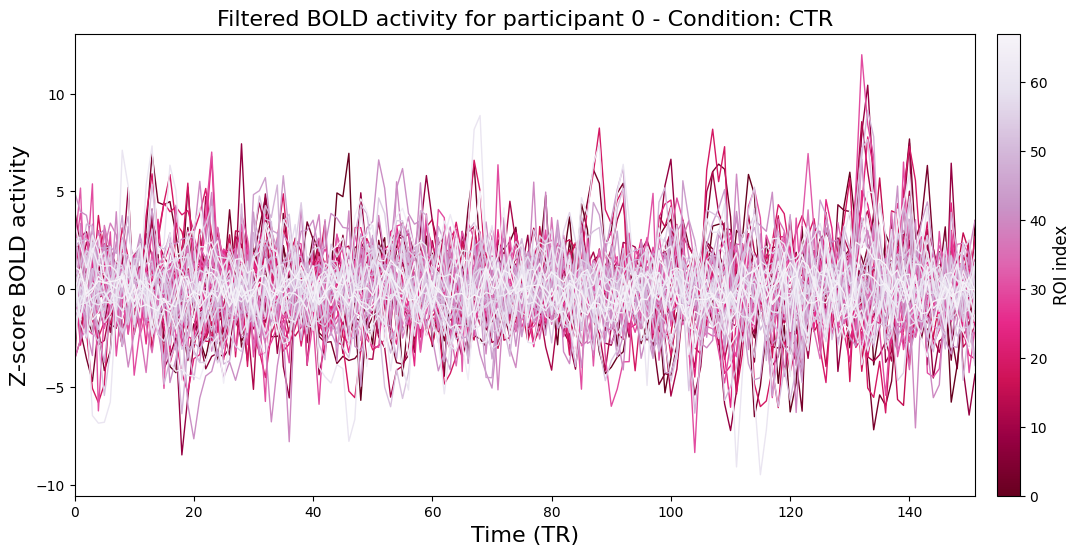

In [69]:
plot_participant = 0
plot_cond = 0 #scz for 1, ctr for 0

cmap = plt.cm.PuRd_r
n_nodes = N
norm = plt.Normalize(vmin=0, vmax=n_nodes - 1)

fig, ax = plt.subplots(figsize=(14,6))

for roi in range(n_nodes):
	ax.plot(
		range(new_array.shape[2]),
		new_array[plot_participant, roi, :, plot_cond], color=cmap(norm(roi)), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('ROI index', fontsize=12)

ax.set_xlim(0, new_array.shape[2] - 1)
ax.set_xlabel('Time (TR)', fontsize=16)
ax.set_ylabel('Z-score BOLD activity', fontsize=16)
ax.set_title(f"Filtered BOLD activity for participant {plot_participant} - Condition: {conds[plot_cond]}", fontsize = 16)


In [27]:
def zscore_check(x, axis=None, thres= 1e-10, verbose=False):
    """Check if the input array is z-scored (mean ~ 0 and std ~ 1) along the specified axis."""
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis, ddof=0)  # ddof=0 matches most z-score implementations
    if verbose:
        print(f"mean ~ 0? max|mean|={np.max(np.abs(mean)):.3e}")
        print(f"std ~ 1? max|std-1|={np.max(np.abs(std-1)):.3e}")
    if np.max(np.abs(mean)) > thres or np.max(np.abs(std-1)) > thres:
        if verbose:
            print(
            f"Signal is not z-scored: mean is not close to 0 or std is not close to 1 "
            f"(max|mean|={np.max(np.abs(mean)):.3e}); max|std-1|={np.max(np.abs(std-1)):.3e})"
                )
        return False 
    
    else: 
        if verbose:
            print(f"Signal is z-scored: mean is close to 0 and std is close to 1 (max|mean|={np.max(np.abs(mean)):.3e}); max|std-1|={np.max(np.abs(std-1)):.3e})")
        return True
    
print("\nChecking if the data is z-scored...")
print(zscore_check(new_array, axis=2, verbose=True))


Checking if the data is z-scored...
mean ~ 0? max|mean|=9.355e-01
std ~ 1? max|std-1|=7.668e-01
Signal is not z-scored: mean is not close to 0 or std is not close to 1 (max|mean|=9.355e-01); max|std-1|=7.668e-01)
False


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\angelica_scripts\.venv\lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 152, using nperseg = 152
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Valid ROI peaks: 68/68
Mean peak frequency: 0.0467 Hz
Median peak frequency: 0.0296 Hz


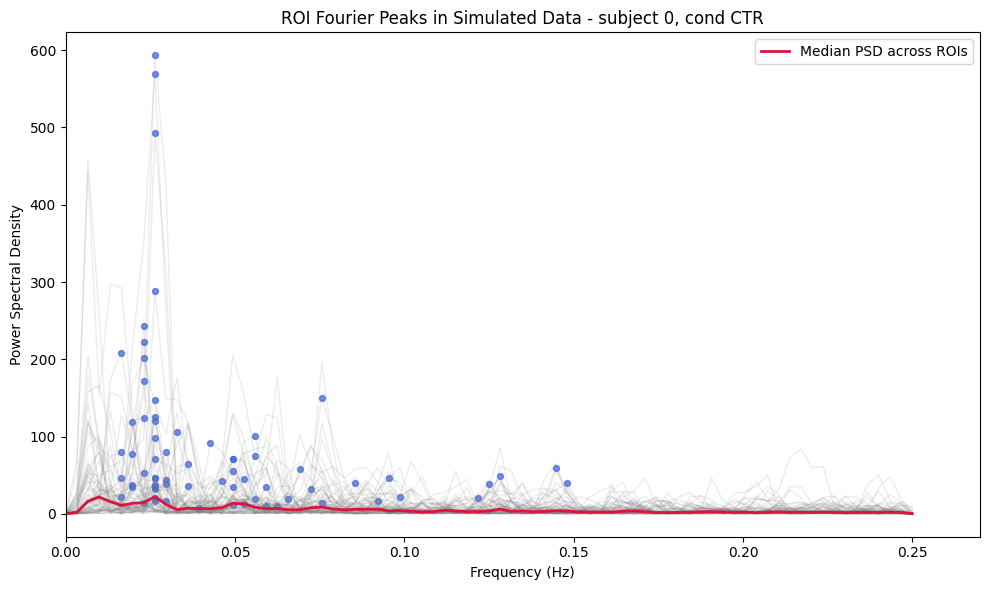

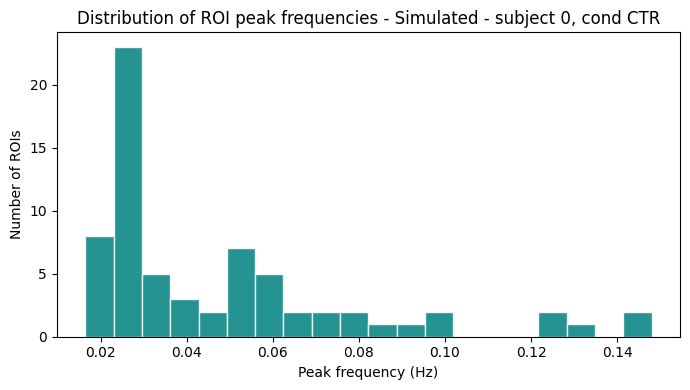

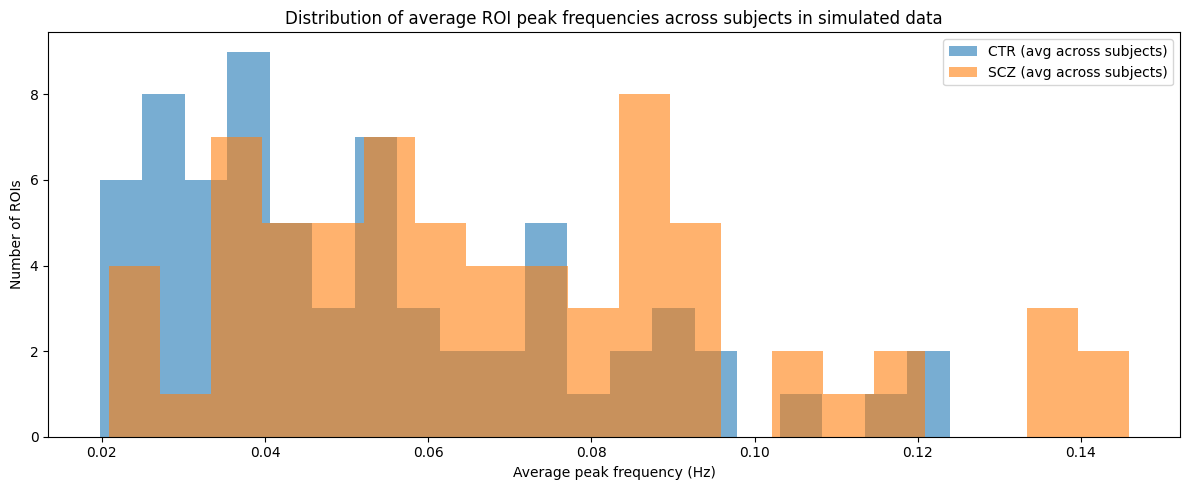

In [70]:
# Fourier peaks per ROI for one subject/condition
# -------- choose data --------
plot_participant = 0
plot_cond = 0  # 0=CTR, 1=SCZ in your setup
X = new_array[plot_participant, :, :, plot_cond]  # shape: [n_rois, n_timepoints]

# -------- compute PSD and dominant peaks --------
def compute_psd_and_peaks(X, TR = 2.0, fmin = 0.01, fmax = 0.25, verbose=True):
    """
    Compute power spectral density (PSD) for each ROI and identify the dominant
    frequency peak within a specified band.

    Parameters
    ----------
    X : ndarray of shape [n_rois, n_timepoints]
        Time series data for each ROI.
    TR : float
        BOLD repetition time in seconds.
    fmin : float
        Minimum frequency of interest in Hz.
    fmax : float
        Maximum frequency of interest in Hz.

    Returns
    -------
    peak_freqs : ndarray of shape [n_rois]
        Dominant frequency peak for each ROI (NaN if no valid peak found).
    peak_powers : ndarray of shape [n_rois]
        Power at the dominant frequency peak for each ROI (NaN if no valid peak found).
    psd_all : ndarray of shape [n_rois, n_freqs]
        Power spectral density for all ROIs across frequencies.
    freqs_ref : ndarray of shape [n_freqs]
        Frequency values corresponding to the PSD estimates.
    """
    fs = 1.0 / TR # sampling frequency in Hz
    n_rois = X.shape[0]
    peak_freqs = np.full(n_rois, np.nan)
    peak_powers = np.full(n_rois, np.nan)
    psd_all = []
    freqs_ref = None

    for r in range(n_rois):
        x = X[r]
        x = x - np.mean(x)  # remove DC
        
        freqs, psd = welch(x, fs=fs)

        if freqs_ref is None:
            freqs_ref = freqs
        psd_all.append(psd)

        band_mask = (freqs >= fmin) & (freqs <= fmax)
        f_band = freqs[band_mask]
        p_band = psd[band_mask]

        if len(p_band) < 3:
            continue

        # candidate local maxima
        pk_idx, _ = find_peaks(p_band)
        if len(pk_idx) == 0:
            # fallback: global max in band
            i_max = np.argmax(p_band)
            peak_freqs[r] = f_band[i_max]
            peak_powers[r] = p_band[i_max]
        else:
            # choose strongest local peak
            best_local = pk_idx[np.argmax(p_band[pk_idx])]
            peak_freqs[r] = f_band[best_local]
            peak_powers[r] = p_band[best_local]

    psd_all = np.array(psd_all)  # shape: [n_rois, n_freqs]
    valid = ~np.isnan(peak_freqs)
    
    if verbose:
        print(f"Valid ROI peaks: {valid.sum()}/{n_rois}")
    
        print(f"Mean peak frequency: {np.nanmean(peak_freqs):.4f} Hz")
        print(f"Median peak frequency: {np.nanmedian(peak_freqs):.4f} Hz")
    
    return peak_freqs, freqs_ref, psd_all


peak_freqs, freqs_ref, psd_all = compute_psd_and_peaks(X, TR=2.0, fmin=0.01, fmax=0.25, verbose=True)

valid = ~np.isnan(peak_freqs)

# Get peaks for all participants and conditions
peak_freqs_all = np.zeros((n_sub, N, n_cond))

for part_temp in range(n_sub):
    for cond_temp in range(n_cond):
        X_temp = new_array[part_temp, :, :, cond_temp]
        peak_freqs_temp,_ , _ = compute_psd_and_peaks(X_temp, TR=2.0, fmin=0.01, fmax=0.25, verbose=False)
        peak_freqs_all[part_temp, :, cond_temp] = peak_freqs_temp

# Sum over participants to get average peak frequency per ROI and condition
avg_peak_freqs = np.nanmean(peak_freqs_all, axis=0)

# -------- plot PSDs + peaks --------
plt.figure(figsize=(10, 6))
for r in range(N):
    plt.plot(freqs_ref, psd_all[r], color="gray", alpha=0.15, linewidth=1)

median_psd = np.median(psd_all, axis=0)
plt.plot(freqs_ref, median_psd, color="crimson", linewidth=2, label="Median PSD across ROIs")

# overlay detected peaks at ROI-specific frequencies (on their own PSD values)
for r in np.where(valid)[0]:
    # get power at closest frequency bin
    idx = np.argmin(np.abs(freqs_ref - peak_freqs[r]))
    plt.scatter(peak_freqs[r], psd_all[r, idx], s=18, color="royalblue", alpha=0.75)

plt.xlim(0, np.max(freqs_ref) + 0.02)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(f"ROI Fourier Peaks in {situations[situation_idx].capitalize()} Data - subject {plot_participant}, cond {conds[plot_cond]}")
plt.legend()
plt.tight_layout()
fig_path = presentation_figs_dir + f"/PSD_peaks_{situations[situation_idx]}_sub{plot_participant}_cond{plot_cond}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.show()

# -------- histogram of peak frequencies for one participant & condition  --------
plt.figure(figsize=(7, 4))
plt.hist(peak_freqs[valid], bins=20, color="teal", alpha=0.85, edgecolor="white")
plt.xlabel("Peak frequency (Hz)")
plt.ylabel("Number of ROIs")
plt.title(f"Distribution of ROI peak frequencies - {situations[situation_idx].capitalize()} - subject {plot_participant}, cond {conds[plot_cond]}")
fig_path = presentation_figs_dir + f"/hist_peak_freqs_{situations[situation_idx]}_sub{plot_participant}_cond{plot_cond}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.tight_layout()
plt.show()

# -------- histogram of average peak frequencies across participants for each condition --------
plt.figure(figsize=(12, 5))
for cond_temp in range(n_cond):
    avg_peaks_cond = avg_peak_freqs[:, cond_temp]
    valid_cond = ~np.isnan(avg_peaks_cond)
    plt.hist(avg_peaks_cond[valid_cond], bins=20, alpha=0.6, label=f"{conds[cond_temp]} (avg across subjects)")
plt.xlabel("Average peak frequency (Hz)")
plt.ylabel("Number of ROIs")
plt.title(f"Distribution of average ROI peak frequencies across subjects in {situations[situation_idx].lower()} data")
fig_path = presentation_figs_dir + f"/hist_avg_peak_freqs_{situations[situation_idx]}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.tight_layout()
plt.legend()
# Optional: save for later analyses
# np.save(res_dir + f"peak_freqs_sub{plot_participant}_cond{plot_cond}.npy", peak_freqs)

In [155]:
need_zscore = 0

if need_zscore:
    from utils import z_score_per_region
    z_scored_array = z_score_per_region(new_array)
    print("Data z-scored per region.")

#### Structural data and masks

In [154]:
# create topological mask for AAL90

SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True
for i in range(N):
    mask_EC[i,i] = False # no self connection
    mask_EC[i,N-1-i] = True # additional interhemispherical connections
print('network size:', N)
print('EC density:', mask_EC.sum()/float(N*(N-1)))

# diagonal mask for input noise matrix (so far, tune noise matrix for diagonal elements only)
mask_Sigma = np.eye(N,dtype=bool)
regul_Sigma = 0.0

network size: 68
EC density: 0.31562774363476737


import itertools

### MOU fitting

In [14]:
# Set n_sub as the number of subjects in the RWW
if situation_idx == 1:
    n_sub = n_subjects_RWW
    n_cond = n_conditions_RWW

NameError: name 'n_subjects_RWW' is not defined

In [32]:
# Test: save number of iterations to see if algorithm converged
iter_mod = np.zeros([n_sub, n_cond], dtype=int)

In [33]:
print(f"Situation idx: {situation_idx}, which corresponds to {situations[situation_idx]} data")

Situation idx: 1, which corresponds to simulated data


In [34]:
# test
if situation_idx == 0:
    Q_data = emp_Q_data
else:
    Q_data = RWW_Q_data

  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
FC0 shape: (68, 68)
FC1 shape: (68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528
optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 787.4365058520456
optimisation step: 2 ; model error = 73.62375277203225
optimisation step: 3 ; model error = 12.086412576997608
optimisation step: 4 ; model error = 7.313244753654509
optimisation step: 5 ; model error = 3.5017852222159824
optimisation step: 6 ; model error = 7.763285502545365
optimisation step: 7 ; model error = 10.688101973495488
optimisation step: 8 ; model error = 47.04018676894823
optimisation step: 9 ; model error = 196.324169958666
optimisation step: 10 ; model error = 9.27284696786702
optimisation step: 11 ; model error = 13.3709655466

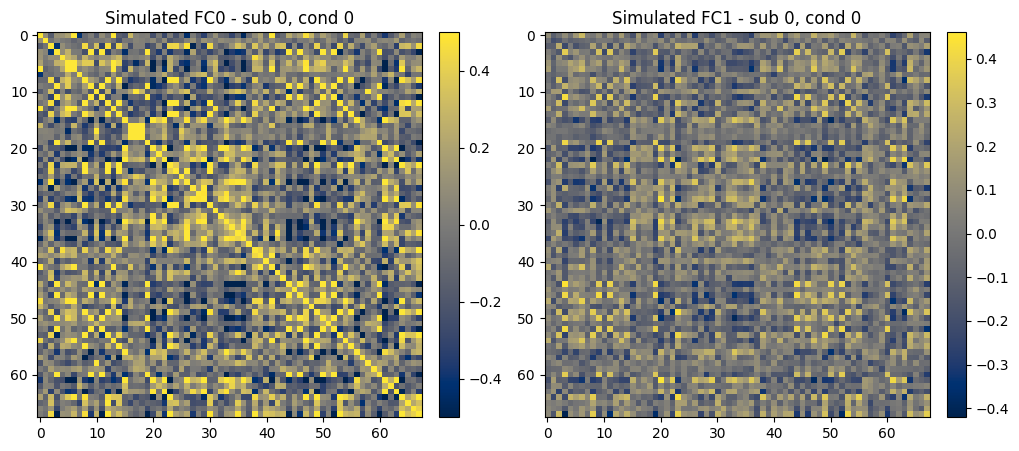

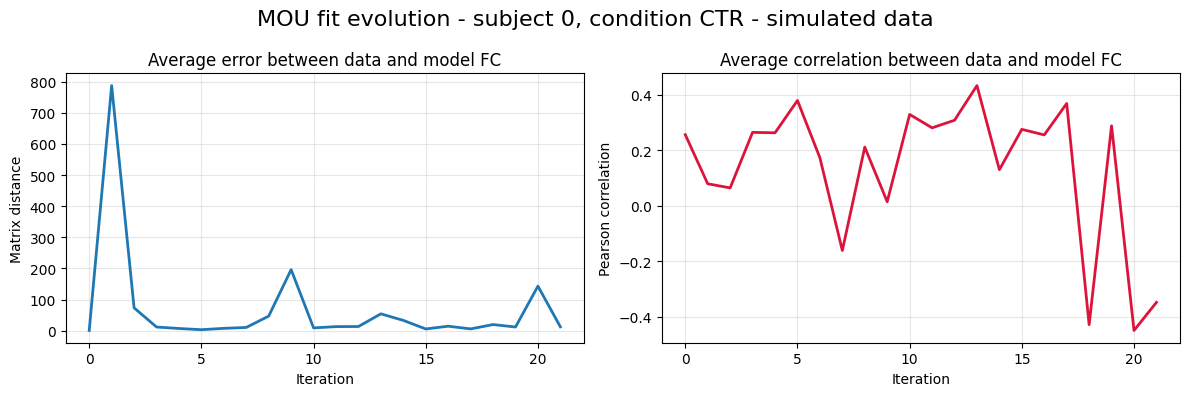

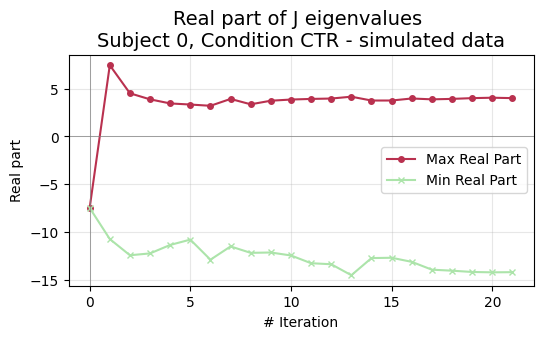

Q_data_temp shape: (2, 68, 68)
FC0 shape: (68, 68)
FC1 shape: (68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688
optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 48.64337408015192
optimisation step: 2 ; model error = 1.638402492444092
optimisation step: 3 ; model error = 0.946562721324364
optimisation step: 4 ; model error = 0.9856664402445593
optimisation step: 5 ; model error = 0.9774335859087687
optimisation step: 6 ; model error = 0.9954386478104769
optimisation step: 7 ; model error = 0.9745888767656354
optimisation step: 8 ; model error = 1.0177116078991466
optimisation step: 9 ; model error = 1.0631402628079543
optimisation step: 10 ; model error = 0.9530283221731018
optimisation step: 11 ; model error = 0.969157

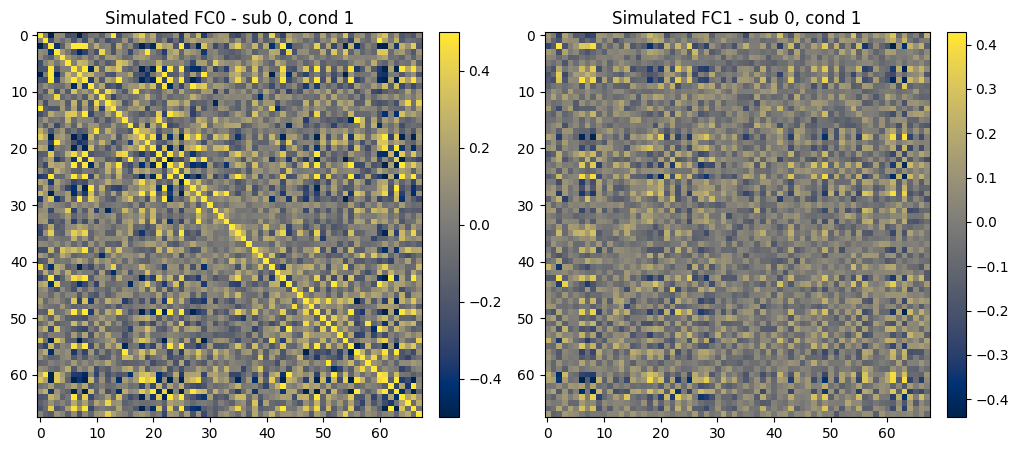

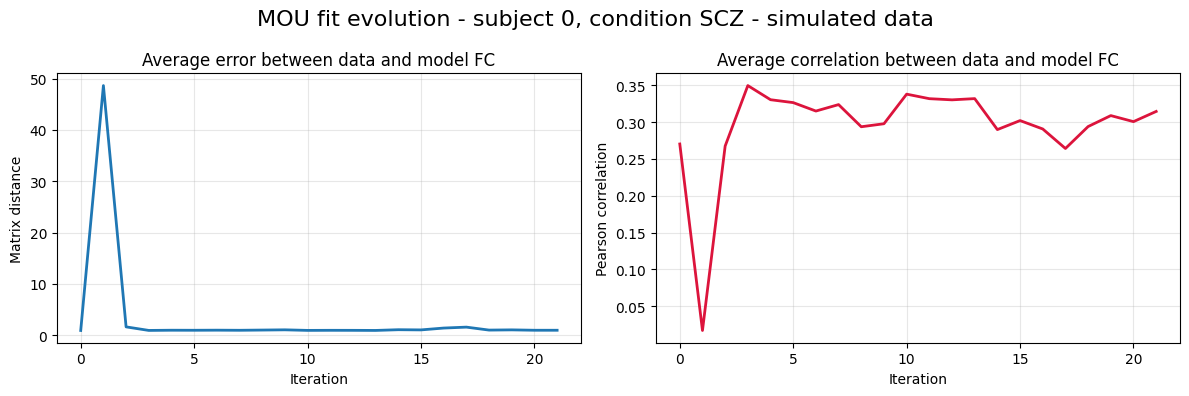

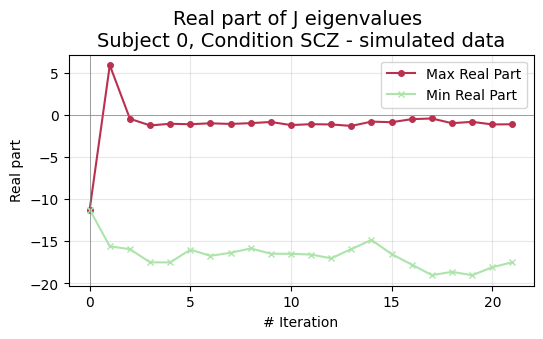

100%|██████████| 1/1 [00:05<00:00,  5.50s/it]

Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 3.433217048755889
Mean distance FC1: 10.180225175472568


In [35]:
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma

# arrays to store results
var_BOLD = np.zeros([n_sub,n_cond,N]) # empirical BOLD variance
J_mod = np.zeros([n_sub,n_cond,N,N]) # model Jacobian (EC.) In the article of Entropy production B=-J
Sigma_mod = np.zeros([n_sub,n_cond,N,N]) # model sigma. In the article of Entropy production sigma=2D
FC0_mod = np.zeros([n_sub,n_cond,N,N]) # model zero-lad FC
err_mod = np.zeros([n_sub,n_cond]) # model error
fit_mod = np.zeros([n_sub,n_cond]) # model goodness of fit (Pearson corr)

verbose=True

## TEST : change min_iter
min_iter = 20
## END TEST 

# Initialize average FC0 and FC1 distance
avg_dist_FC0 = 0.0
avg_dist_FC1 = 0.0

# loop over subject and conditions
for i_sub in tqdm.tqdm(range(n_sub)):
    for i_cond in range(n_cond):
        # get time series
        Q_data_temp = Q_data[:,i_sub,:,:,i_cond]
        print("Q_data_temp shape:", Q_data_temp.shape)
        # store empirical BOLD variance (48, 68, 152, 2)
        #FC0 = Q_data_temp[0]
        #FC1 = Q_data_temp[1]
        FC0 = np.corrcoef(new_array[i_sub,:,:,i_cond]) 
        FC1 = FC0/np.max(FC0)
        ## debugging
        #FC0 = FC0 + np.eye(N)
        #FC1 = FC1 + np.eye(N)
        #Q_data_temp[0] = FC0
        #Q_data_temp[1] = FC1
        print("FC0 shape:", FC0.shape)
        print("FC1 shape:", FC1.shape)
        # 1) Basic sanity checks
        assert np.isfinite(FC0).all(), f"Non-finite values in FC0 at sub {i_sub}, cond {i_cond}"
        assert np.isfinite(FC1).all(), f"Non-finite values in FC1 at sub {i_sub}, cond {i_cond}"

        sym0 = np.max(np.abs(FC0 - FC0.T))
        sym1 = np.max(np.abs(FC1 - FC1.T))
        print(f"sub {i_sub}, cond {i_cond}: max asymmetry FC0={sym0:.3e}, FC1={sym1:.3e}")
        print("Q0 finite:", np.isfinite(FC0).all())
        print("Q1 finite:", np.isfinite(FC1).all())
        print("Q0 symmetric max err:", np.max(np.abs(FC0 - FC0.T)))
        print("Q1 diagonal min/max:", np.min(np.diag(FC1)), np.max(np.diag(FC1)))
        print("Q1 positive diagonal fraction:", np.mean(np.diag(FC1) > 0))
        print("Q0 norm:", np.linalg.norm(FC0))
        print("Q1 norm:", np.linalg.norm(FC1))
        ##
        lim_FC = 0.1 # limit DTI value to determine SC (only connections with larger values are tuned)
        mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
        mask_EC[FC1>lim_FC] = True
        for i in range(N):
            mask_EC[i,i] = False # no self connection
            mask_EC[i,N-1-i] = True # additional interhemispherical connections
        ##debugging
        fig_dbg, ax_dbg = plt.subplots(1, 2, figsize=(12, 5))
        ax_dbg[0].imshow(Q_data_temp[0], vmin=-0.5, vmax=0.5, cmap='bwr')
        # add a colorbar
        plt.colorbar(ax_dbg[0].imshow(Q_data_temp[0], vmin=-0.5, vmax=0.5, cmap='cividis'), ax=ax_dbg[0], fraction=0.046, pad=0.04)
        ax_dbg[0].set_title(f"{situations[situation_idx].capitalize()} FC0 - sub {i_sub}, cond {i_cond}")
        ax_dbg[1].imshow(Q_data_temp[1], cmap='bwr')
        ax_dbg[1].set_title(f"{situations[situation_idx].capitalize()} FC1 - sub {i_sub}, cond {i_cond}")
        # add a colorbar
        plt.colorbar(ax_dbg[1].imshow(Q_data_temp[1], cmap='cividis'), ax=ax_dbg[1], fraction=0.046, pad=0.04)
        #
        # invert model
        mou_est = MOUv2()
        mou_est.fit_Q(Q_emp = Q_data_temp, mask_C=mask_EC, mask_Sigma=mask_Sigma, algo_version="true", min_iter=min_iter, epsilon_C=0.005, epsilon_Sigma=0.005*N,
                      track_eigs=True, eigs_every=1, eigs_store_full=False, verbose=True)

        # test : save nb of iterations
        iter_mod[i_sub, i_cond] = mou_est.d_fit["iterations"]

        # store results
        J_mod[i_sub,i_cond,:,:] = mou_est.J
        Sigma_mod[i_sub,i_cond,:,:] = mou_est.Sigma
        FC0_mod[i_sub,i_cond,:,:] = spl.solve_lyapunov(J_mod[i_sub,i_cond,:,:].T, -Sigma_mod[i_sub,i_cond,:,:])
        err_mod[i_sub,i_cond] = mou_est.d_fit['distance']
        fit_mod[i_sub,i_cond] = mou_est.d_fit['correlation']
        
        # Update average distances for FC0 and FC1
        avg_dist_FC0 += mou_est.d_fit['distFC0']
        avg_dist_FC1 += mou_est.d_fit['distFC1']

        if verbose:
            print('sub', i_sub, '; cond', i_cond, ':', mou_est.d_fit)
            
            d = mou_est.d_fit
            n_it = int(d["iterations"])

            # Error btw model and data for FC0 and FC1 (matrix distance) -> = 0.5 * (dist_Q0 + dist_Qtau)
            dist_hist = np.asarray(d["distance history"][:n_it])
            # Corr between model and empirical data for FC0 and FC1 -> =  0.5 * (Pearson_Q0  + Pearson_Qtau)
            corr_hist = np.asarray(d["correlation history"][:n_it])

            # Print eigenvalues
            #for iter_idx, eigs in enumerate(d['eigs_history']):
             #   print(f"Iteration {iter_idx}: min real part of eigenvalues = {np.min(np.real(eigs)):.4f}, max real part of eigenvalues = {np.max(np.real(eigs)):.4f}")    

            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
            ax[0].plot(dist_hist, lw=2)
            ax[0].set_title("Average error between data and model FC")
            ax[0].set_xlabel("Iteration")
            ax[0].set_ylabel("Matrix distance")
            ax[0].grid(alpha=0.3)

            ax[1].plot(corr_hist, lw=2, color="crimson")
            ax[1].set_title("Average correlation between data and model FC")
            
            ax[1].set_xlabel("Iteration")
            ax[1].set_ylabel("Pearson correlation")
            ax[1].grid(alpha=0.3)

            plt.suptitle(f"MOU fit evolution - subject {i_sub}, condition {conds[i_cond]} - {situations[situation_idx]} data", fontsize=16)
            plt.tight_layout()
            # Save figure
            plt.savefig(os.path.join(presentation_figs_dir, f"MOU_fit_evolution_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}"), format=graph_format, dpi=300)
            plt.show()
            plt.close()

            # Plot evolution of max and min real part of eigenvalues across iterations
            plt.figure(figsize=(6, 3))
            plt.plot(d['eig_iter'], d['eig_max_real'], 'o-', markersize=4, color = '#B9314F',label='Max Real Part')
            plt.plot(d['eig_iter'], d['eig_min_real'], 'x-', markersize=4, color = '#ACE4AA', label='Min Real Part')
            plt.axhline(0, color='gray', lw=0.5)
            plt.axvline(0, color='gray', lw=0.5)
            plt.title(f"Real part of J eigenvalues \nSubject {i_sub}, Condition {conds[i_cond]} - {situations[situation_idx]} data", fontsize=14)
            plt.ylabel("Real part")
            plt.xlabel("# Iteration")
            plt.grid(alpha=0.3)
            plt.legend()
            plt.savefig(os.path.join(presentation_figs_dir, f"eigenvalues_real_part_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}"), format=graph_format, dpi=300)
            plt.show()
            plt.close()

print("Mean iterations:", iter_mod.mean())
print("Max iterations:", iter_mod.max())
print("Mean distance FC0:", avg_dist_FC0 / (n_sub * n_cond))
print("Mean distance FC1:", avg_dist_FC1 / (n_sub * n_cond))

### Start of test 4.0: using different values of lim_FC for the MOU fitting


Testing lim_FC = 0.01


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


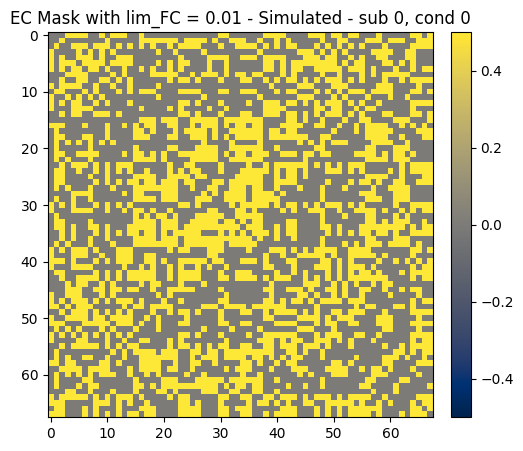

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 12670.800979347548
optimisation step: 2 ; model error = 3708.4232971342635
optimisation step: 3 ; model error = 1718.4427048492687
optimisation step: 4 ; model error = 4126.662825970727
optimisation step: 5 ; model error = 5355.548753808186
optimisation step: 6 ; model error = 31545.82794317256
optimisation step: 7 ; model error = 1758.1690905713565
optimisation step: 8 ; model error = 2358.1742864506514
optimisation step: 9 ; model error = 4421.428806882729
optimisation step: 10 ; model error = 4591.7973670060355
optimisation step: 11 ; model error = 4705.3896036560545
optimisation step: 12 ; model error = 4780.823285170054
optimisation step: 13 ; model error = 4830.801128120815
optimisation step: 14 ; model error = 4863.867249793057
optimisation step: 15 ; model error = 4885.725307252549
optimisation step: 16 ; model error = 4900.166405010247
optimisation step: 17 ; model error = 4909.7039075

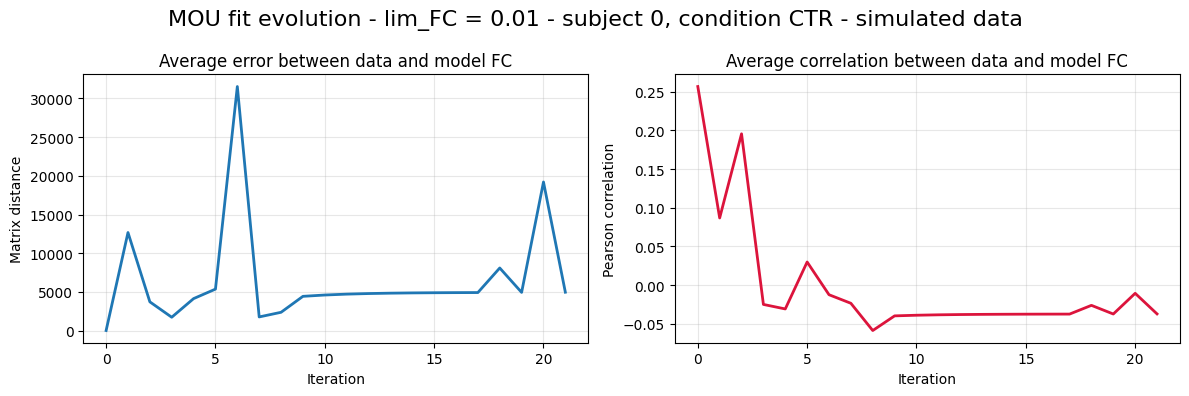

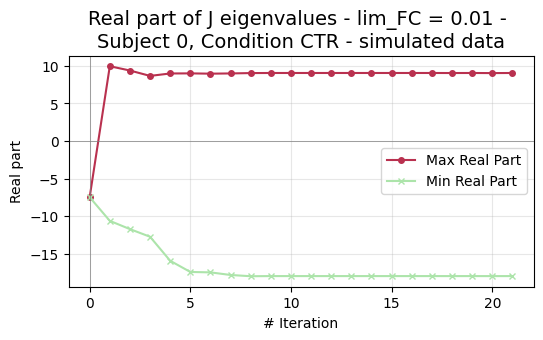

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


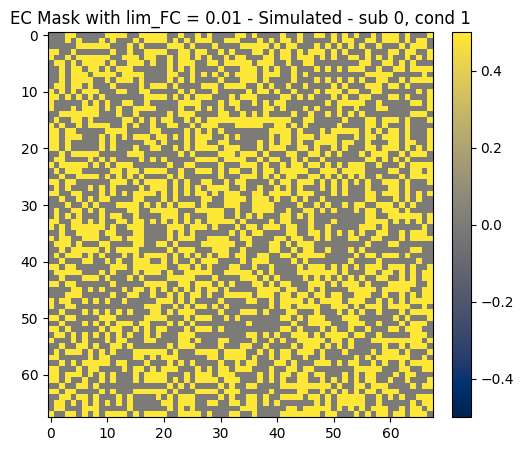

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 204366.30913403287
optimisation step: 2 ; model error = 98.01580242442321
optimisation step: 3 ; model error = 46.149540909051446
optimisation step: 4 ; model error = 190.185813497262
optimisation step: 5 ; model error = 84.61757929520819
optimisation step: 6 ; model error = 46.815877424899455
optimisation step: 7 ; model error = 49.54397570351919
optimisation step: 8 ; model error = 51.1947003223389
optimisation step: 9 ; model error = 50.499022065928145
optimisation step: 10 ; model error = 54.20588012655585
optimisation step: 11 ; model error = 54.762606827274034
optimisation step: 12 ; model error = 54.74379110814278
optimisation step: 13 ; model error = 54.737145038022
optimisation step: 14 ; model error = 54.73527417573886
optimisation step: 15 ; model error = 54.735135327220654
optimisation step: 16 ; model error = 54.735521080037756
optimisation step: 17 ; model error = 54.73598362574584

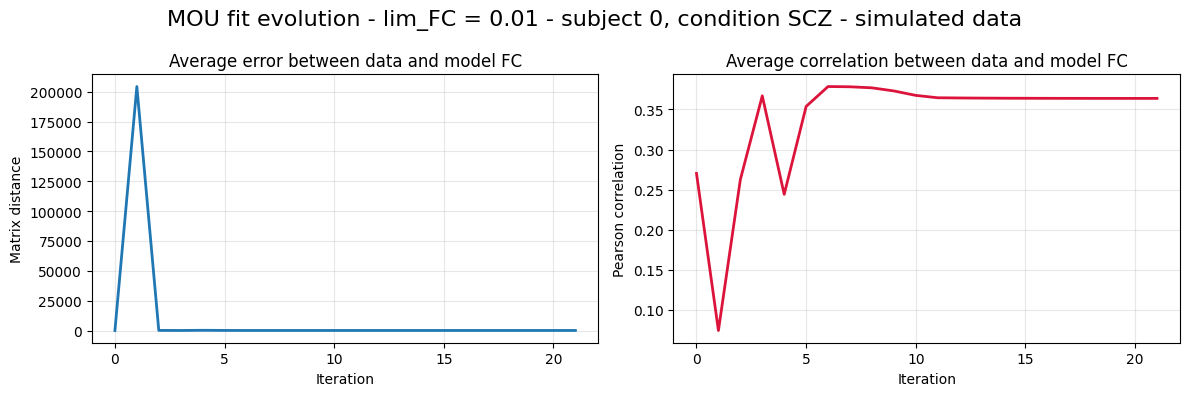

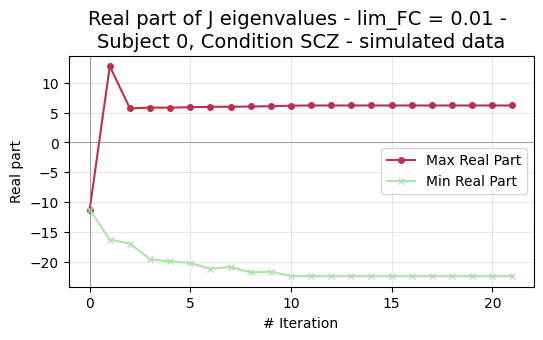

100%|██████████| 1/1 [00:03<00:00,  3.68s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 1.1025836655077537
Mean distance FC1: 5008.011411374921

Testing lim_FC = 0.03


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


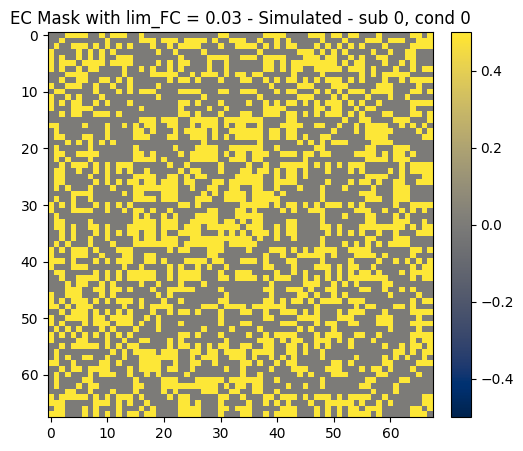

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 12312.559070317324
optimisation step: 2 ; model error = 2837.7110855104042
optimisation step: 3 ; model error = 1487.8743915493685
optimisation step: 4 ; model error = 7791.450469754435
optimisation step: 5 ; model error = 3187.6199858935274
optimisation step: 6 ; model error = 4929.453561075503
optimisation step: 7 ; model error = 862.2949726607748
optimisation step: 8 ; model error = 2579.836715398367
optimisation step: 9 ; model error = 9345.94414384334
optimisation step: 10 ; model error = 8919.544313466473
optimisation step: 11 ; model error = 107753.42909351543
optimisation step: 12 ; model error = 20253.76057679466
optimisation step: 13 ; model error = 109053.16221810425
optimisation step: 14 ; model error = 12376.146464042802
optimisation step: 15 ; model error = 109790.34695806497
optimisation step: 16 ; model error = 10610.671702014502
optimisation step: 17 ; model error = 110165.0553

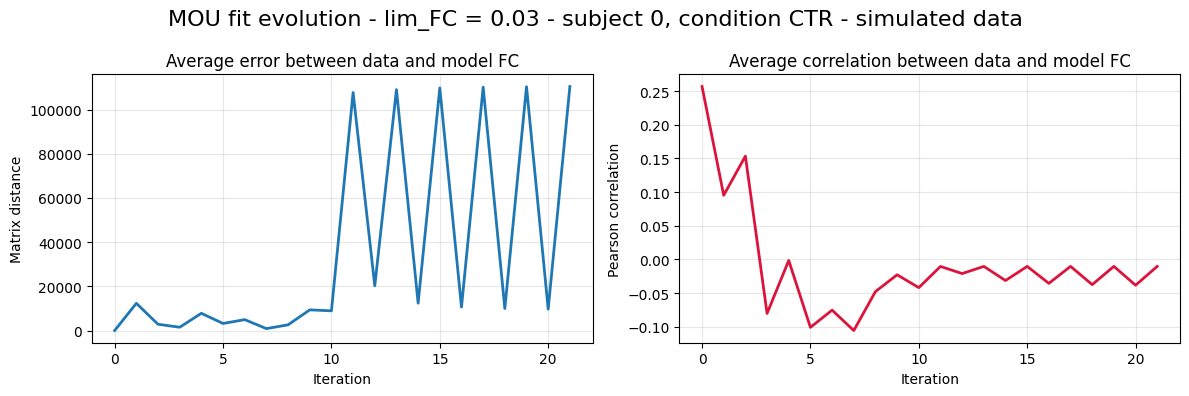

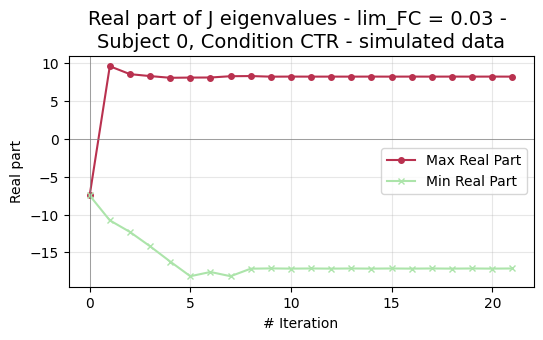

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


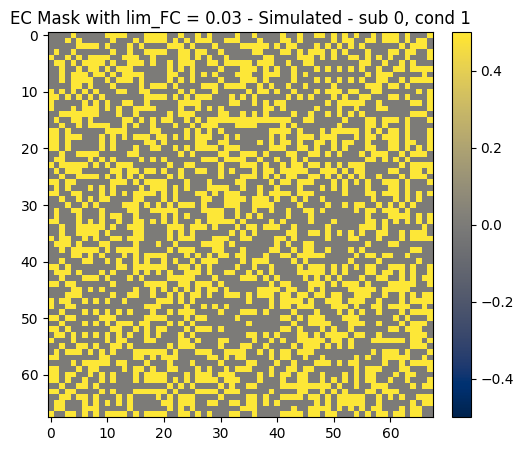

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 25441.266997224833
optimisation step: 2 ; model error = 21.849452273241717
optimisation step: 3 ; model error = 15.92470233270019
optimisation step: 4 ; model error = 16.062828227796093
optimisation step: 5 ; model error = 17.725301001147912
optimisation step: 6 ; model error = 18.959578072988155
optimisation step: 7 ; model error = 19.402022584342927
optimisation step: 8 ; model error = 19.704894777318962
optimisation step: 9 ; model error = 19.90929029763921
optimisation step: 10 ; model error = 20.04608740457288
optimisation step: 11 ; model error = 20.137181408950084
optimisation step: 12 ; model error = 20.197650280015296
optimisation step: 13 ; model error = 20.23770936242774
optimisation step: 14 ; model error = 20.264213120330396
optimisation step: 15 ; model error = 20.28173369298849
optimisation step: 16 ; model error = 20.293309474034128
optimisation step: 17 ; model error = 20.300954

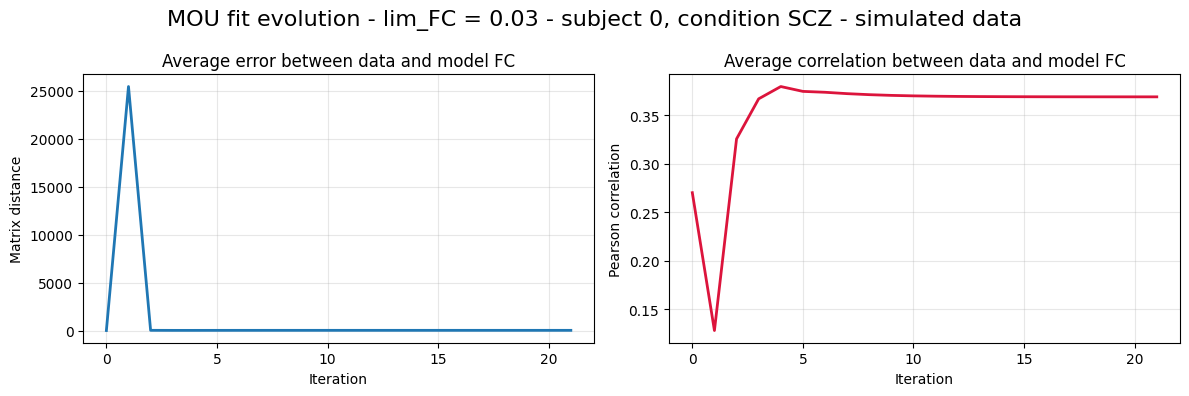

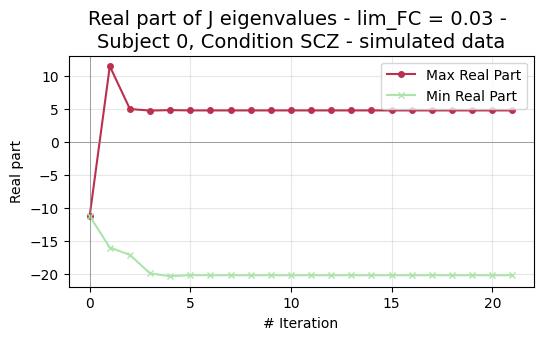

100%|██████████| 1/1 [00:03<00:00,  3.47s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 22.519486756191977
Mean distance FC1: 115460.53411416899

Testing lim_FC = 0.04


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


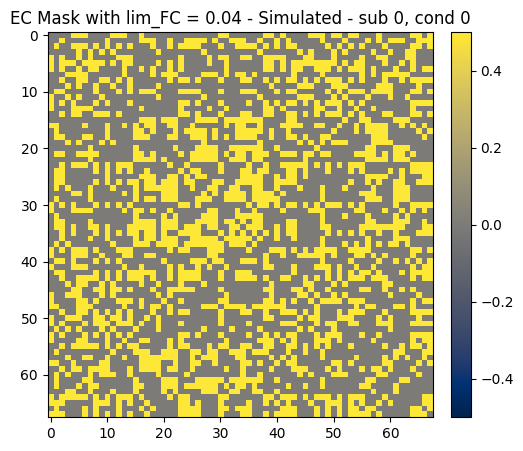

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 4590.2364080397065
optimisation step: 2 ; model error = 1807.8538457813868
optimisation step: 3 ; model error = 4171.617955015043
optimisation step: 4 ; model error = 1226.687739351661
optimisation step: 5 ; model error = 1912.6482574553509
optimisation step: 6 ; model error = 2306.9670530916114
optimisation step: 7 ; model error = 4065.7606151961877
optimisation step: 8 ; model error = 25550.15799337077
optimisation step: 9 ; model error = 604.7826524735738
optimisation step: 10 ; model error = 5212.8704716309885
optimisation step: 11 ; model error = 10766.66661925928
optimisation step: 12 ; model error = 577.6146415683892
optimisation step: 13 ; model error = 30089.657982931145
optimisation step: 14 ; model error = 1206.7228844290246
optimisation step: 15 ; model error = 3968.5332868791156
optimisation step: 16 ; model error = 1354.8510356097302
optimisation step: 17 ; model error = 2751.5045

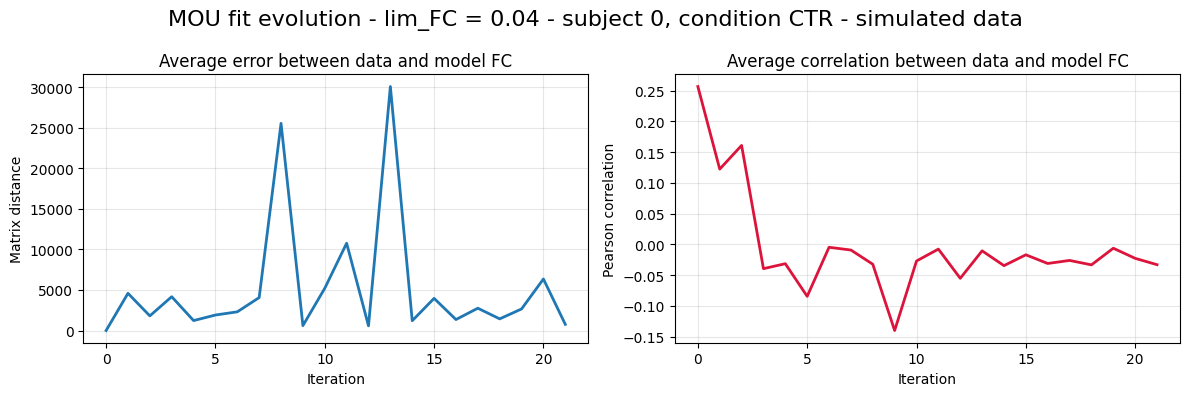

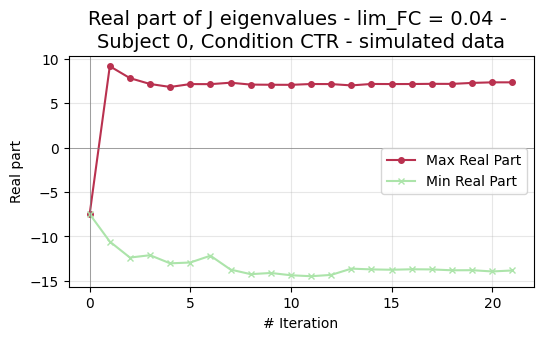

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


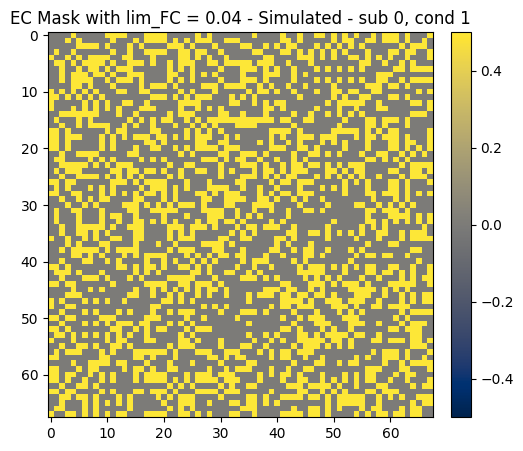

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 7983.581186390815
optimisation step: 2 ; model error = 6.239621368357519
optimisation step: 3 ; model error = 266.3024474882059
optimisation step: 4 ; model error = 5.2087718528040865
optimisation step: 5 ; model error = 4.102864428666197
optimisation step: 6 ; model error = 5.259474643413344
optimisation step: 7 ; model error = 5.871973383243552
optimisation step: 8 ; model error = 7.442339056146367
optimisation step: 9 ; model error = 5.232339686001392
optimisation step: 10 ; model error = 6.617430801304176
optimisation step: 11 ; model error = 6.58815687767396
optimisation step: 12 ; model error = 6.823649998816501
optimisation step: 13 ; model error = 6.665047042013858
optimisation step: 14 ; model error = 7.210980272010655
optimisation step: 15 ; model error = 6.460374365402995
optimisation step: 16 ; model error = 7.230744132011378
optimisation step: 17 ; model error = 7.341882520189287
op

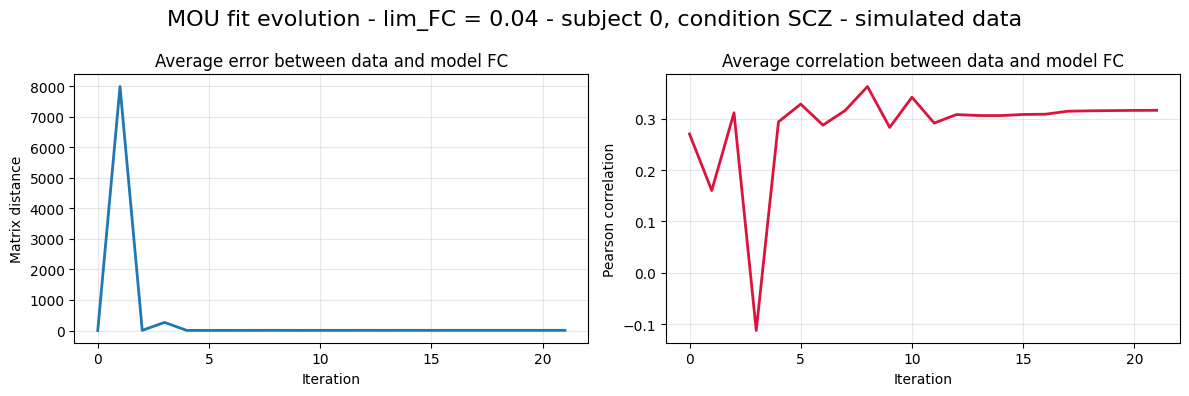

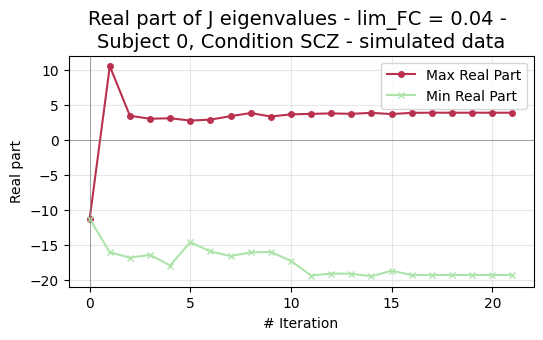

100%|██████████| 1/1 [00:03<00:00,  3.39s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 23.59855140642244
Mean distance FC1: 116230.12744940071

Testing lim_FC = 0.06


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


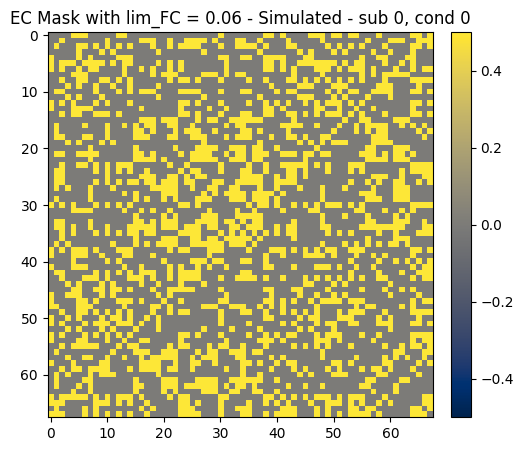

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 4742.739733227127
optimisation step: 2 ; model error = 357.05269915039145
optimisation step: 3 ; model error = 314.9224250101465
optimisation step: 4 ; model error = 264.76780606383727
optimisation step: 5 ; model error = 2431.75764568637
optimisation step: 6 ; model error = 2662.4478555765754
optimisation step: 7 ; model error = 791.403705697546
optimisation step: 8 ; model error = 481.6249677774306
optimisation step: 9 ; model error = 238.8990770967064
optimisation step: 10 ; model error = 180.8905118068017
optimisation step: 11 ; model error = 195.3569176142091
optimisation step: 12 ; model error = 203.7473596180704
optimisation step: 13 ; model error = 358.65794546397376
optimisation step: 14 ; model error = 564.9506349139816
optimisation step: 15 ; model error = 569.3777400366741
optimisation step: 16 ; model error = 572.3081760395075
optimisation step: 17 ; model error = 574.2459264300489

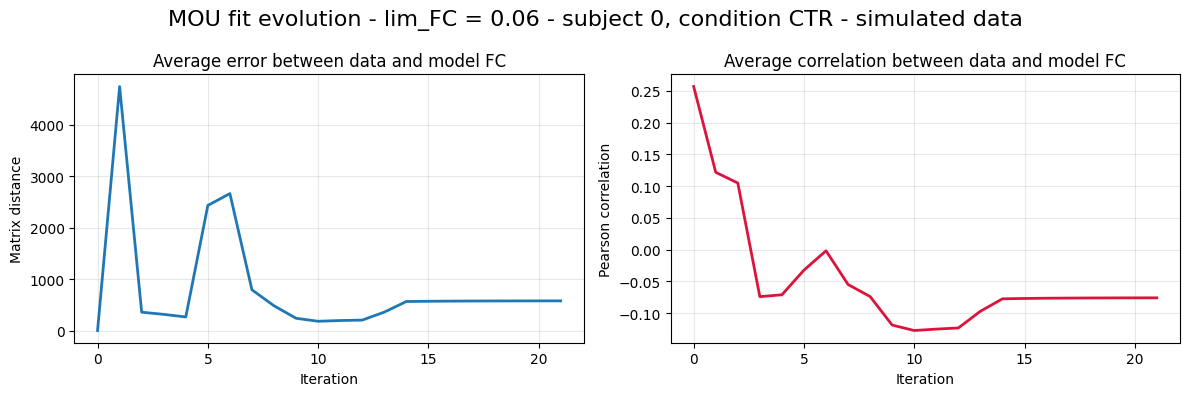

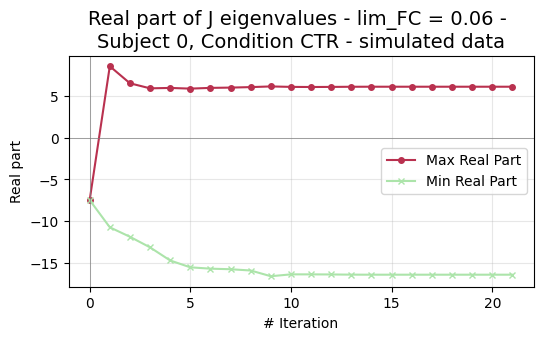

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


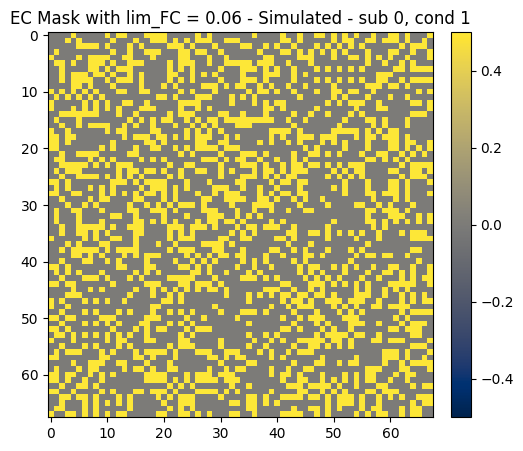

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 6465.828849889787
optimisation step: 2 ; model error = 4.314836411785694
optimisation step: 3 ; model error = 2.510143353347672
optimisation step: 4 ; model error = 2.667178370651607
optimisation step: 5 ; model error = 4.771801487186454
optimisation step: 6 ; model error = 2.3029081428796285
optimisation step: 7 ; model error = 7.674476724823736
optimisation step: 8 ; model error = 2.88756351491174
optimisation step: 9 ; model error = 3.2472610321817106
optimisation step: 10 ; model error = 4.038162371786342
optimisation step: 11 ; model error = 6.368744658822771
optimisation step: 12 ; model error = 3.100266694372218
optimisation step: 13 ; model error = 4.117963343600907
optimisation step: 14 ; model error = 190.19412557107614
optimisation step: 15 ; model error = 4.5419113147941195
optimisation step: 16 ; model error = 2.580540713539943
optimisation step: 17 ; model error = 3.607066306805958

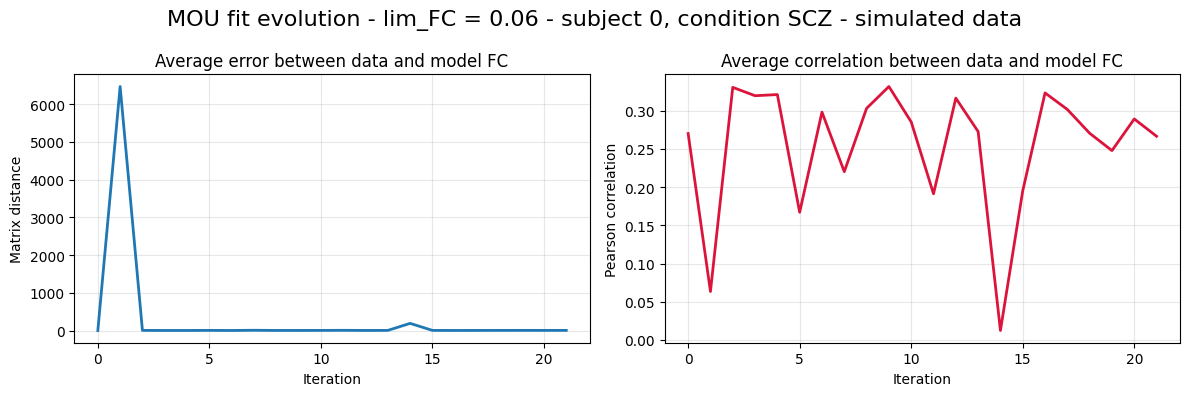

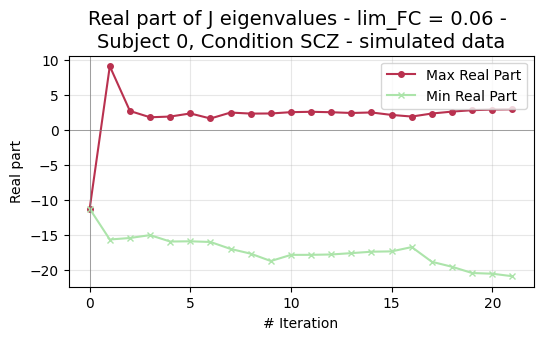

100%|██████████| 1/1 [00:03<00:00,  3.75s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 25.230784698037272
Mean distance FC1: 116810.3496118936

Testing lim_FC = 0.07


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


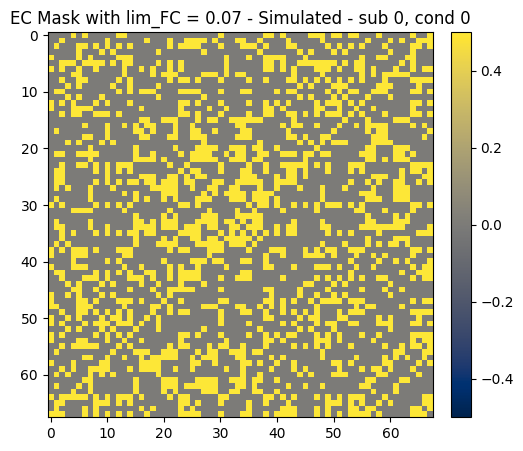

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 1481.703551404697
optimisation step: 2 ; model error = 174.00444643854345
optimisation step: 3 ; model error = 33.537210173771946
optimisation step: 4 ; model error = 15.733284226502176
optimisation step: 5 ; model error = 118.25392803031441
optimisation step: 6 ; model error = 302.20604762217795
optimisation step: 7 ; model error = 28.21633601215455
optimisation step: 8 ; model error = 29.742715975682305
optimisation step: 9 ; model error = 29.47839653432963
optimisation step: 10 ; model error = 151.13079076162487
optimisation step: 11 ; model error = 142.24778637844838
optimisation step: 12 ; model error = 140.9975093113728
optimisation step: 13 ; model error = 140.1746725737005
optimisation step: 14 ; model error = 139.63264142647856
optimisation step: 15 ; model error = 139.27535997705795
optimisation step: 16 ; model error = 139.03975583955963
optimisation step: 17 ; model error = 138.8843

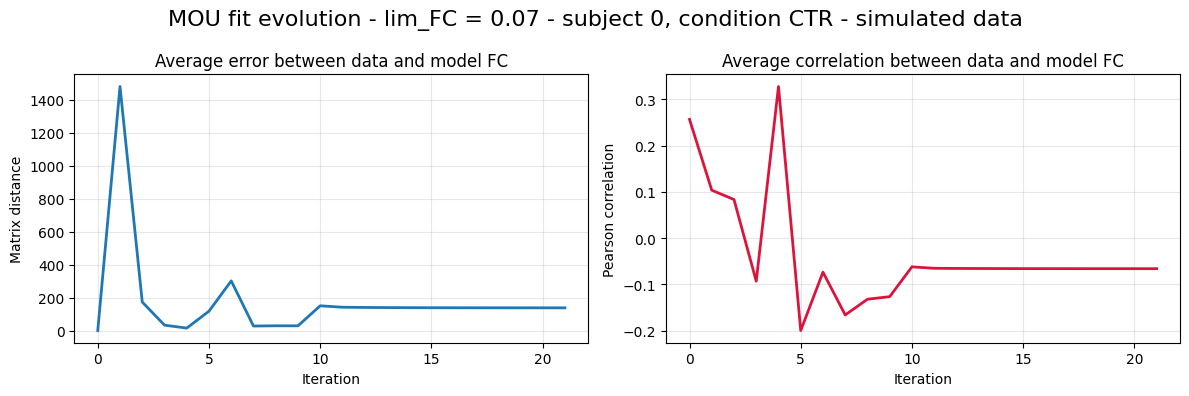

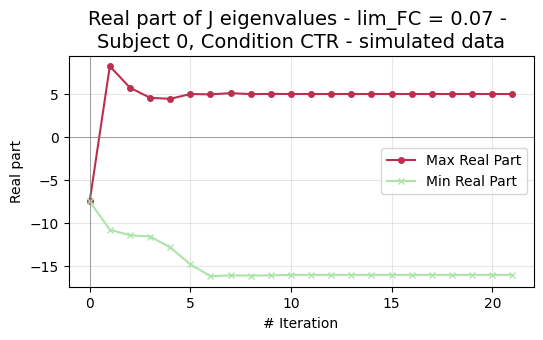

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


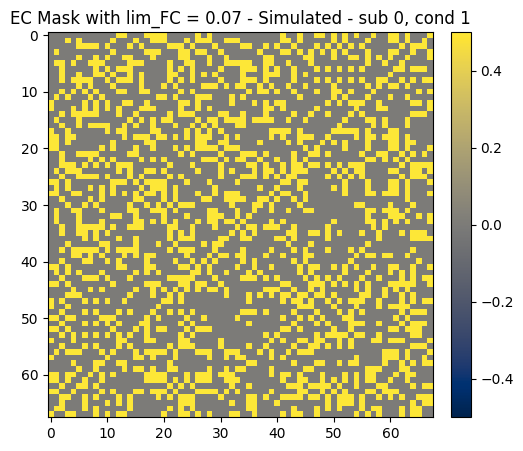

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 3056.402556719624
optimisation step: 2 ; model error = 3.362502388666801
optimisation step: 3 ; model error = 2.5348280300951256
optimisation step: 4 ; model error = 2.129694767610193
optimisation step: 5 ; model error = 2.121124747283943
optimisation step: 6 ; model error = 2.1384400206389156
optimisation step: 7 ; model error = 2.1389163500939956
optimisation step: 8 ; model error = 2.145563313394467
optimisation step: 9 ; model error = 2.077630794874447
optimisation step: 10 ; model error = 2.0853386708864
optimisation step: 11 ; model error = 2.068788331711142
optimisation step: 12 ; model error = 2.0985132903313755
optimisation step: 13 ; model error = 2.134282213942566
optimisation step: 14 ; model error = 2.1745050889796955
optimisation step: 15 ; model error = 3.017875990055274
optimisation step: 16 ; model error = 2.055655747729908
optimisation step: 17 ; model error = 2.124619881231183

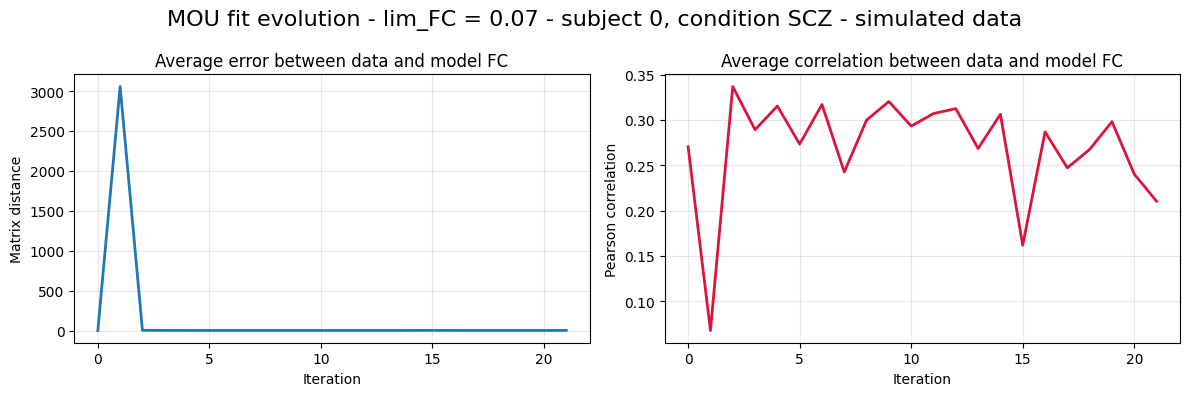

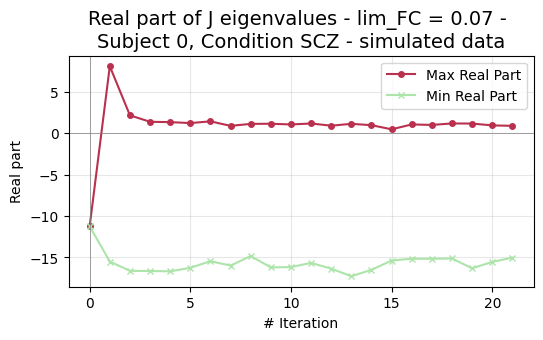

100%|██████████| 1/1 [00:03<00:00,  3.27s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 26.761372914159907
Mean distance FC1: 116949.70275771187

Testing lim_FC = 0.09


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


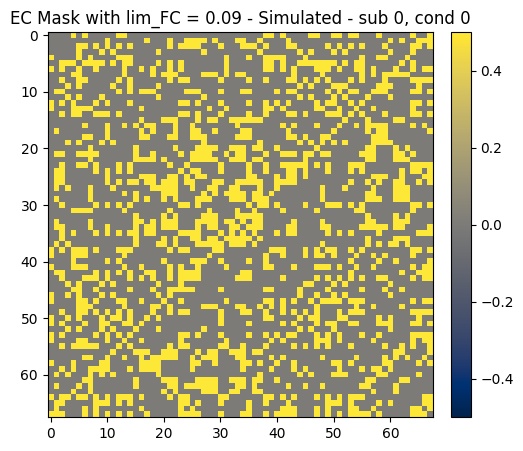

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 1352.132449461527
optimisation step: 2 ; model error = 144.42990194626591
optimisation step: 3 ; model error = 31.13487306570711
optimisation step: 4 ; model error = 30.559448727865387
optimisation step: 5 ; model error = 24.580520179860986
optimisation step: 6 ; model error = 17.930624124733992
optimisation step: 7 ; model error = 25.771668335001813
optimisation step: 8 ; model error = 54826.23263728335
optimisation step: 9 ; model error = 5032.506350740585
optimisation step: 10 ; model error = 68.44881525882987
optimisation step: 11 ; model error = 16.884533141669444
optimisation step: 12 ; model error = 51.252912150421004
optimisation step: 13 ; model error = 21.780744553093566
optimisation step: 14 ; model error = 20.890432192118332
optimisation step: 15 ; model error = 19.402732431722185
optimisation step: 16 ; model error = 17.081591246552822
optimisation step: 17 ; model error = 23.15124

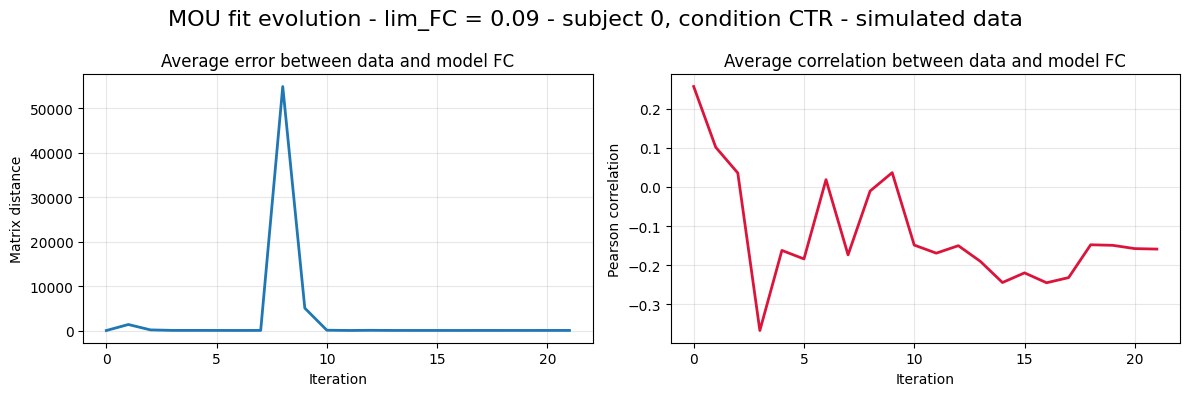

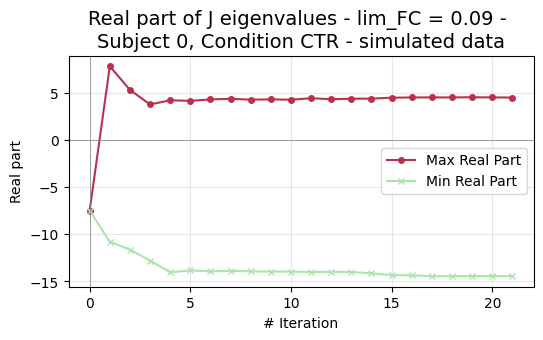

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


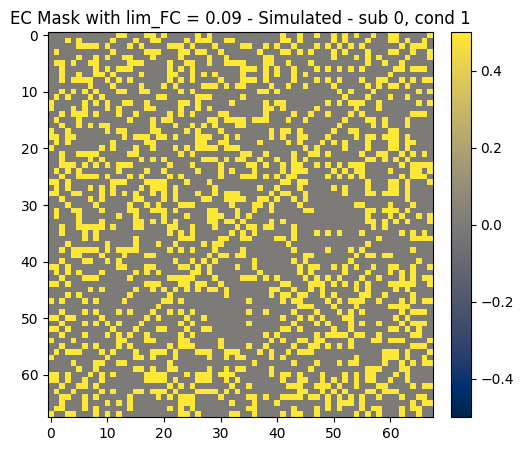

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 139.84497399525924
optimisation step: 2 ; model error = 2.3735586667919746
optimisation step: 3 ; model error = 3.2047942574185027
optimisation step: 4 ; model error = 2.802555030980628
optimisation step: 5 ; model error = 2.688667895684979
optimisation step: 6 ; model error = 3.2222375047048324
optimisation step: 7 ; model error = 3.7852439733832686
optimisation step: 8 ; model error = 3.3672724668589846
optimisation step: 9 ; model error = 2.9955634962484883
optimisation step: 10 ; model error = 3.0423733397927233
optimisation step: 11 ; model error = 3.074045067023164
optimisation step: 12 ; model error = 2.9678132518687006
optimisation step: 13 ; model error = 2.670715926865896
optimisation step: 14 ; model error = 3.1028289025350118
optimisation step: 15 ; model error = 2.7426924190444737
optimisation step: 16 ; model error = 3.0495403510871304
optimisation step: 17 ; model error = 2.803962

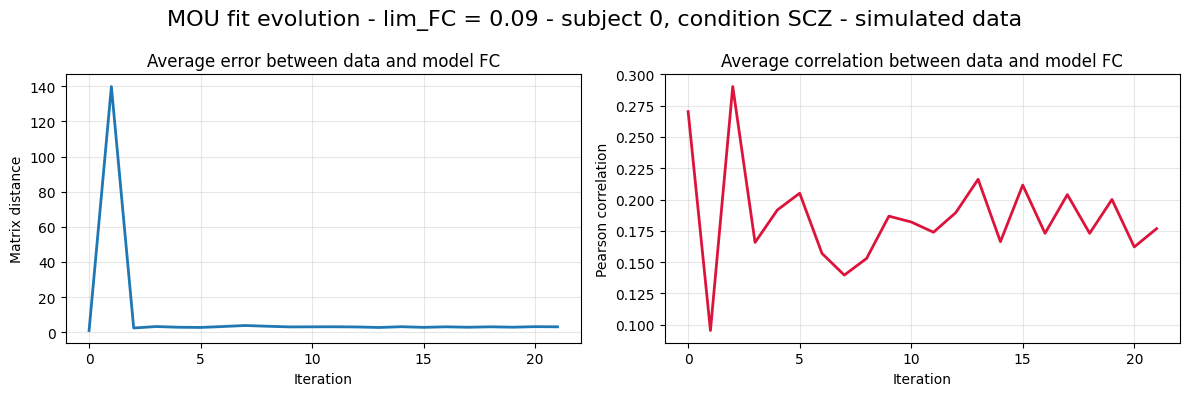

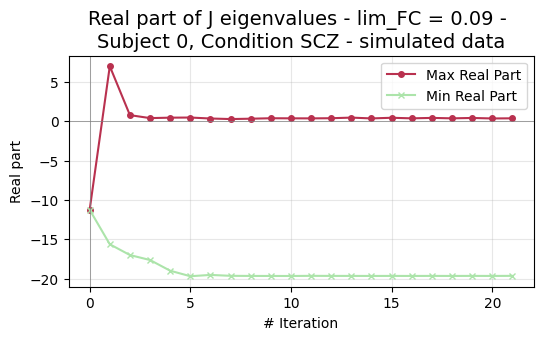

100%|██████████| 1/1 [00:03<00:00,  3.96s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 28.65544193142965
Mean distance FC1: 116974.59237137961

Testing lim_FC = 0.10


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


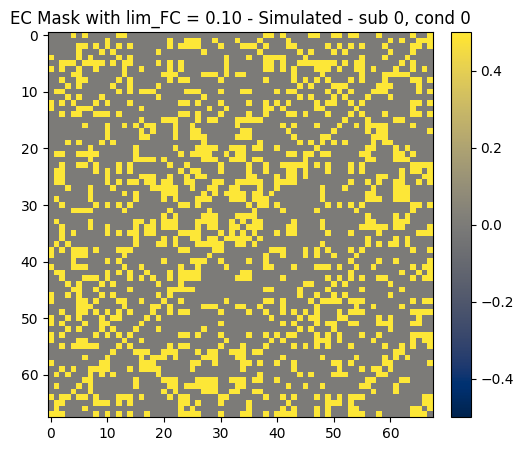

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 787.4365058520456
optimisation step: 2 ; model error = 73.62375277203225
optimisation step: 3 ; model error = 12.086412576997608
optimisation step: 4 ; model error = 7.313244753654509
optimisation step: 5 ; model error = 3.5017852222159824
optimisation step: 6 ; model error = 7.763285502545365
optimisation step: 7 ; model error = 10.688101973495488
optimisation step: 8 ; model error = 47.04018676894823
optimisation step: 9 ; model error = 196.324169958666
optimisation step: 10 ; model error = 9.27284696786702
optimisation step: 11 ; model error = 13.370965546671464
optimisation step: 12 ; model error = 13.698625258247493
optimisation step: 13 ; model error = 54.39860969291466
optimisation step: 14 ; model error = 33.321718998223595
optimisation step: 15 ; model error = 5.850230179667239
optimisation step: 16 ; model error = 14.710808814587981
optimisation step: 17 ; model error = 5.982899693328

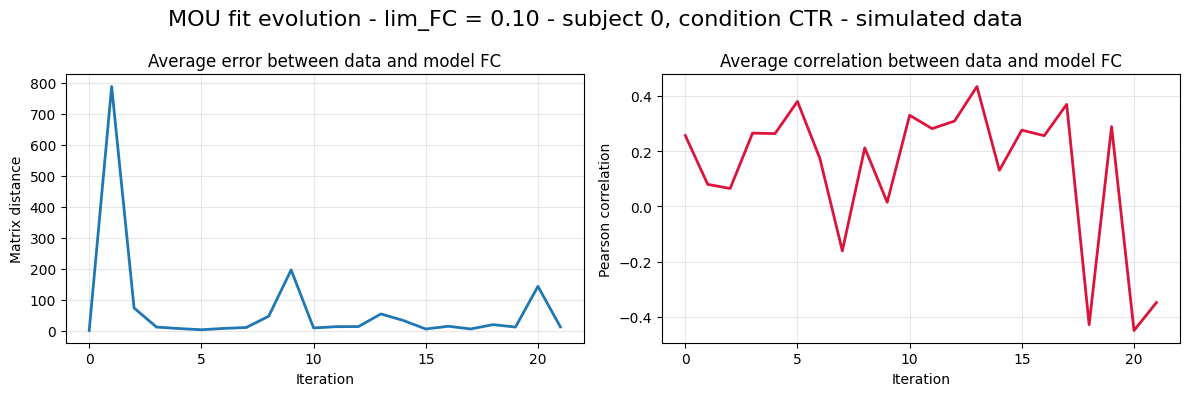

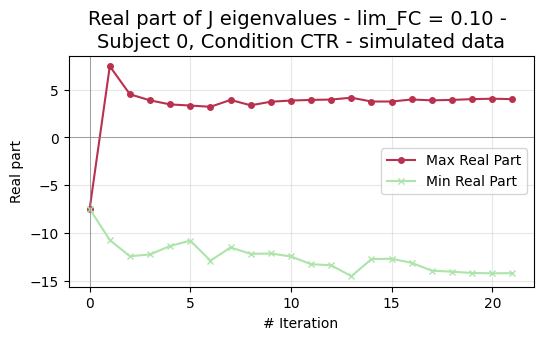

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


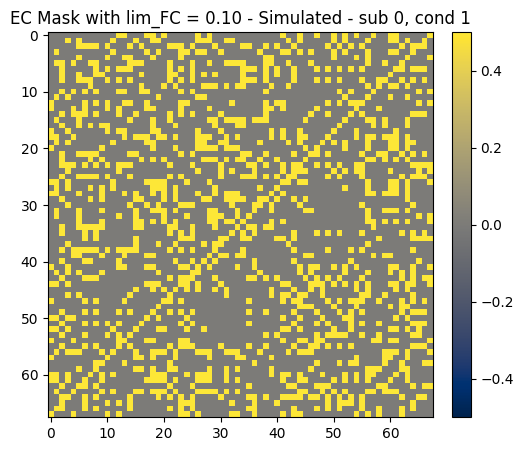

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 48.64337408015192
optimisation step: 2 ; model error = 1.638402492444092
optimisation step: 3 ; model error = 0.946562721324364
optimisation step: 4 ; model error = 0.9856664402445593
optimisation step: 5 ; model error = 0.9774335859087687
optimisation step: 6 ; model error = 0.9954386478104769
optimisation step: 7 ; model error = 0.9745888767656354
optimisation step: 8 ; model error = 1.0177116078991466
optimisation step: 9 ; model error = 1.0631402628079543
optimisation step: 10 ; model error = 0.9530283221731018
optimisation step: 11 ; model error = 0.9691574792934188
optimisation step: 12 ; model error = 0.963260270320449
optimisation step: 13 ; model error = 0.9454309601249157
optimisation step: 14 ; model error = 1.0856233780173357
optimisation step: 15 ; model error = 1.0490408303158703
optimisation step: 16 ; model error = 1.4081718961944236
optimisation step: 17 ; model error = 1.588945

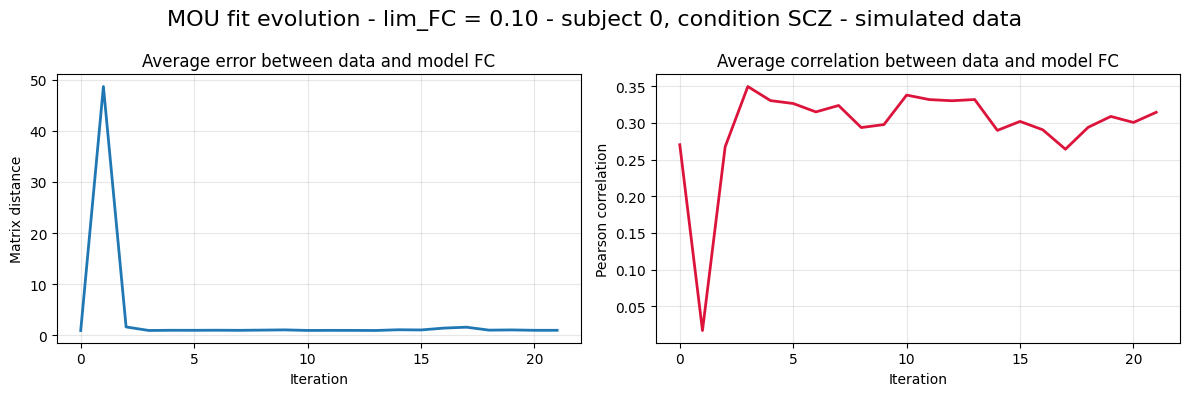

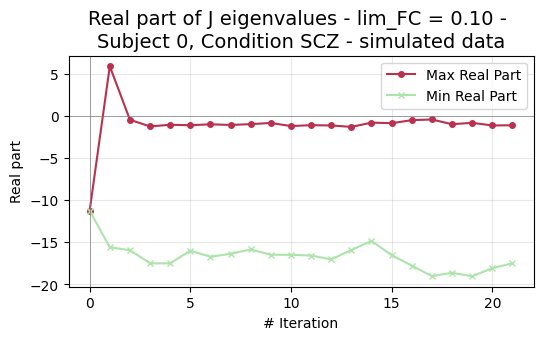

100%|██████████| 1/1 [00:03<00:00,  3.48s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 32.08865898018554
Mean distance FC1: 116984.77259655508

Testing lim_FC = 0.12


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


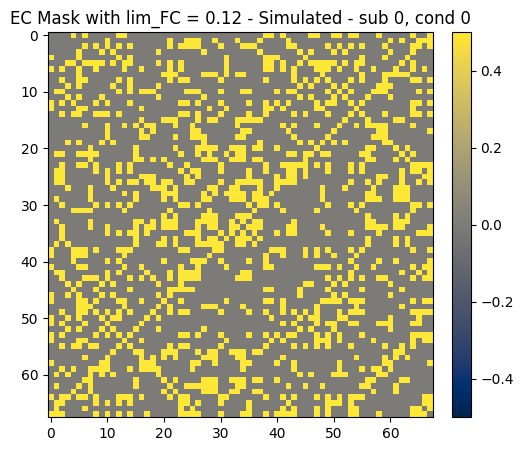

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 3812.525852987075
optimisation step: 2 ; model error = 14.549594122270854
optimisation step: 3 ; model error = 14.119719618574596
optimisation step: 4 ; model error = 4.00461326346957
optimisation step: 5 ; model error = 17.646794160860438
optimisation step: 6 ; model error = 2.7761396250112873
optimisation step: 7 ; model error = 69.22019475810887
optimisation step: 8 ; model error = 4.131089592066648
optimisation step: 9 ; model error = 5.026845345335381
optimisation step: 10 ; model error = 18.173658090834046
optimisation step: 11 ; model error = 3.2433952882429558
optimisation step: 12 ; model error = 4.065872546200771
optimisation step: 13 ; model error = 3.7232454083587676
optimisation step: 14 ; model error = 64.36851089085764
optimisation step: 15 ; model error = 4.328695796162709
optimisation step: 16 ; model error = 1278.8322796375694
optimisation step: 17 ; model error = 4.1973986217

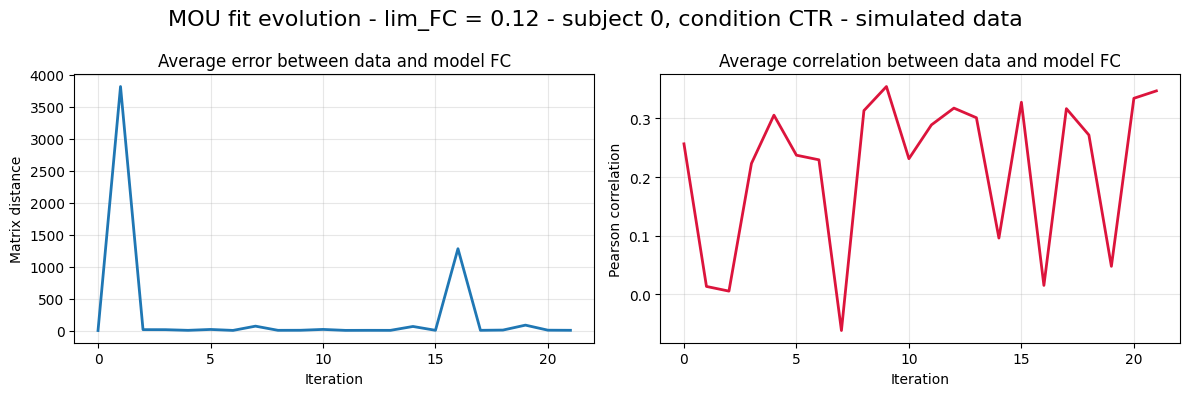

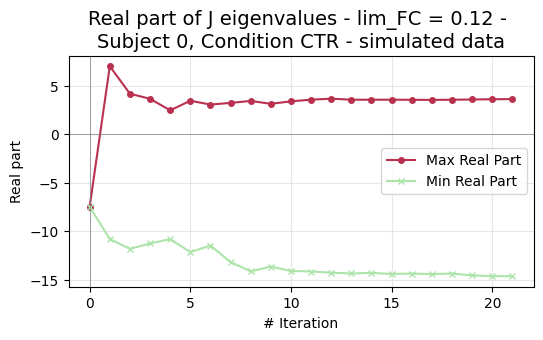

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


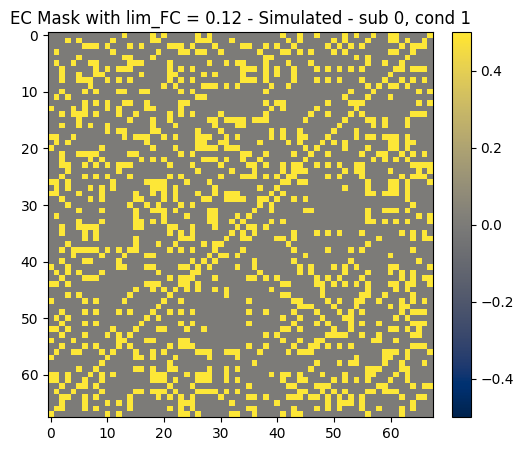

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 27.272415197910156
optimisation step: 2 ; model error = 1.0958862309027393
optimisation step: 3 ; model error = 0.9127893924603836
optimisation step: 4 ; model error = 0.9226041383074369
optimisation step: 5 ; model error = 0.9299765406734882
optimisation step: 6 ; model error = 0.9247076489115269
optimisation step: 7 ; model error = 0.9282015369913903
optimisation step: 8 ; model error = 0.9171589146853514
optimisation step: 9 ; model error = 0.9349480714434033
optimisation step: 10 ; model error = 0.9242813517806447
optimisation step: 11 ; model error = 0.9195589139466167
optimisation step: 12 ; model error = 0.9265463330119343
optimisation step: 13 ; model error = 0.9313006976700413
optimisation step: 14 ; model error = 0.9095063518638153
optimisation step: 15 ; model error = 0.9166623807376797
optimisation step: 16 ; model error = 0.9108870705316046
optimisation step: 17 ; model error = 0.92

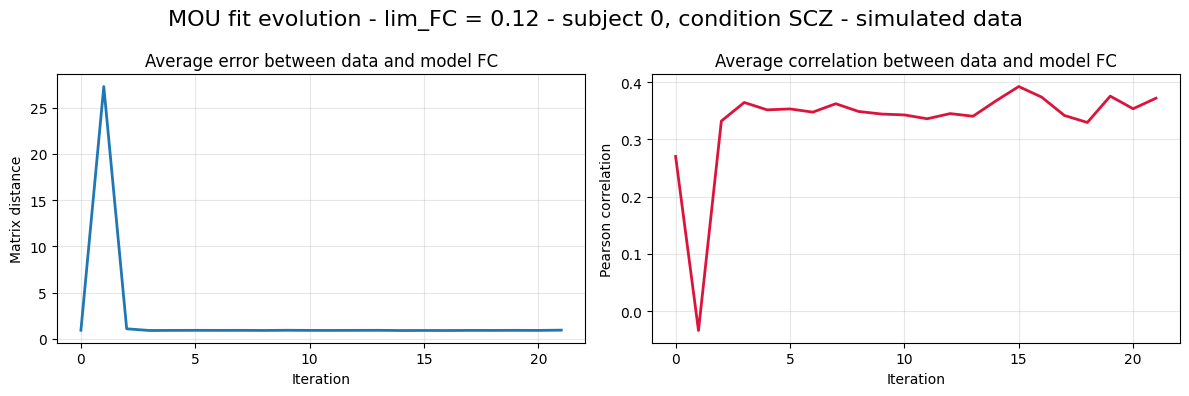

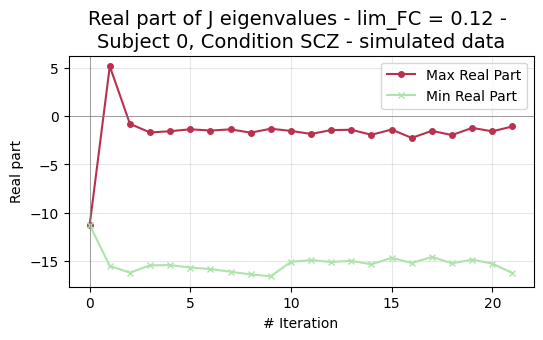

100%|██████████| 1/1 [00:04<00:00,  4.05s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 32.91400049449175
Mean distance FC1: 116989.38458661614

Testing lim_FC = 0.13


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


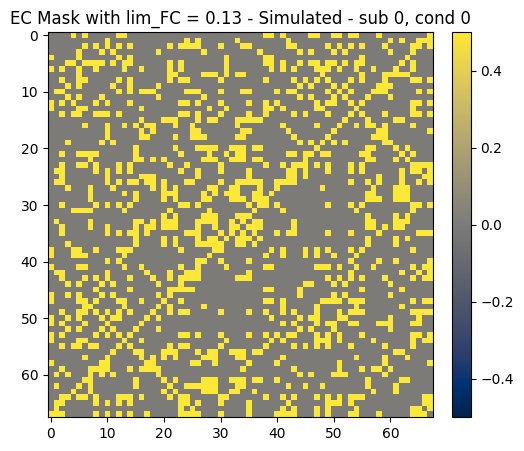

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 293.61634961737485
optimisation step: 2 ; model error = 6.401772161006643
optimisation step: 3 ; model error = 2.4109009563626778
optimisation step: 4 ; model error = 8.000123474414703
optimisation step: 5 ; model error = 2.7621718454270305
optimisation step: 6 ; model error = 2.9692193837685785
optimisation step: 7 ; model error = 3.1299278785829836
optimisation step: 8 ; model error = 1.5907781438771953
optimisation step: 9 ; model error = 5.244924063620582
optimisation step: 10 ; model error = 2.6860553415095745
optimisation step: 11 ; model error = 2.214020339384892
optimisation step: 12 ; model error = 2.9488677163823755
optimisation step: 13 ; model error = 2.5750966262532935
optimisation step: 14 ; model error = 3.548811676302244
optimisation step: 15 ; model error = 12.258999210200319
optimisation step: 16 ; model error = 7.5801756221142185
optimisation step: 17 ; model error = 6.013161

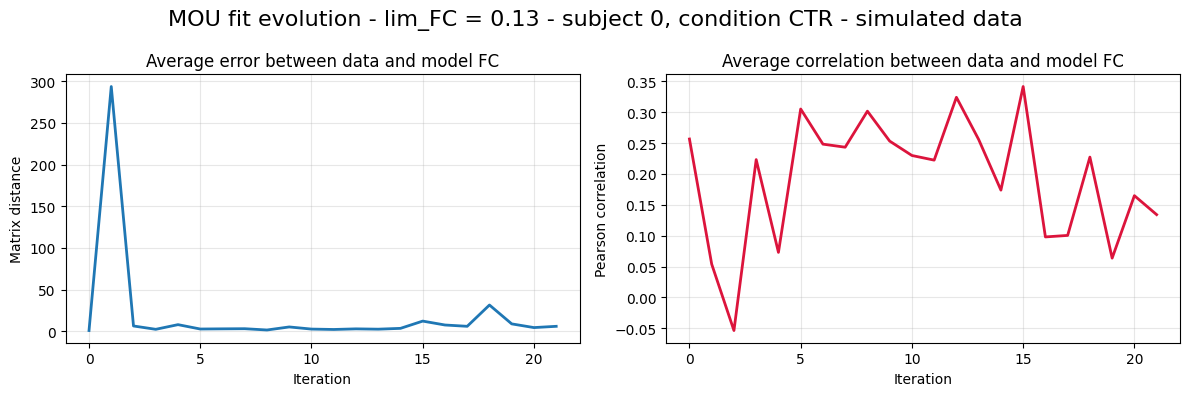

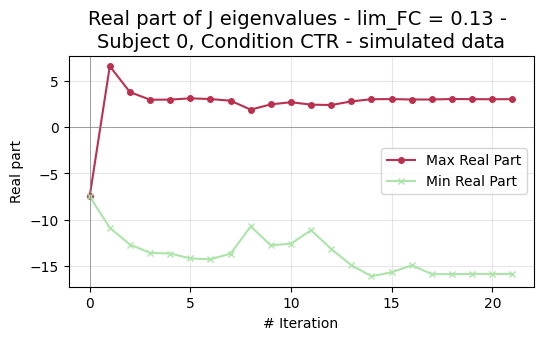

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


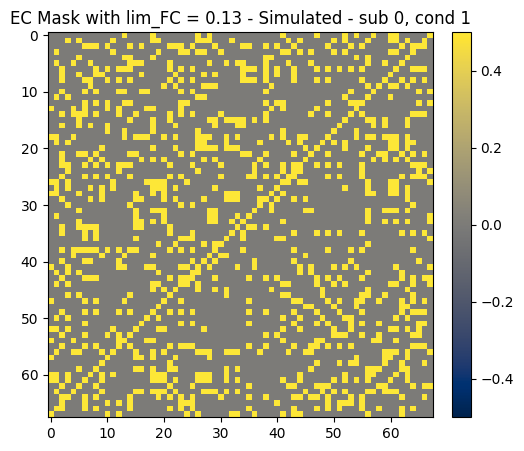

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 11.561704033531155
optimisation step: 2 ; model error = 0.9439710419340138
optimisation step: 3 ; model error = 0.9060782787882171
optimisation step: 4 ; model error = 0.9078658375041638
optimisation step: 5 ; model error = 0.9116761380485983
optimisation step: 6 ; model error = 0.9075166278939608
optimisation step: 7 ; model error = 0.9102178940865729
optimisation step: 8 ; model error = 0.9066383854649189
optimisation step: 9 ; model error = 0.9088462389092795
optimisation step: 10 ; model error = 0.9069688938011449
optimisation step: 11 ; model error = 0.9074087220510136
optimisation step: 12 ; model error = 0.9073919764723504
optimisation step: 13 ; model error = 0.9127918881673149
optimisation step: 14 ; model error = 0.9081097106313925
optimisation step: 15 ; model error = 0.9089049288867868
optimisation step: 16 ; model error = 0.9080730641401855
optimisation step: 17 ; model error = 0.90

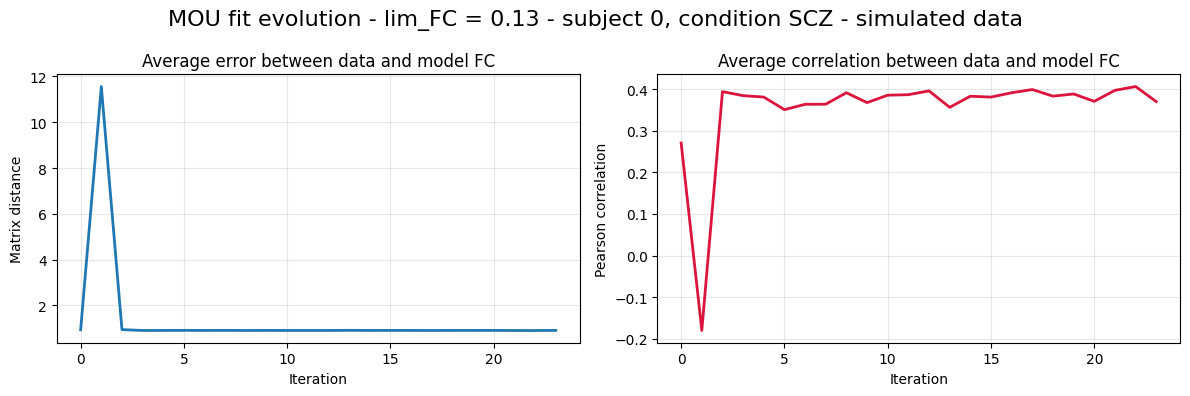

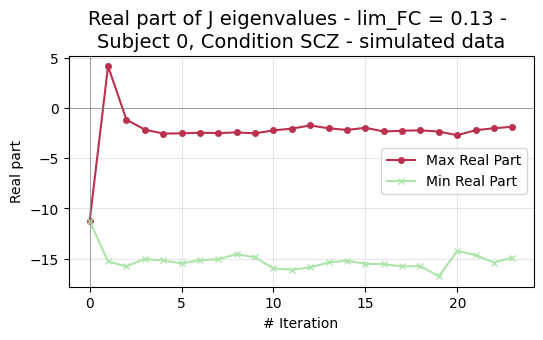

100%|██████████| 1/1 [00:03<00:00,  3.55s/it]


Mean iterations: 23.0
Max iterations: 24
Mean distance FC0: 33.79701372975643
Mean distance FC1: 116995.4135527988

Testing lim_FC = 0.15


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


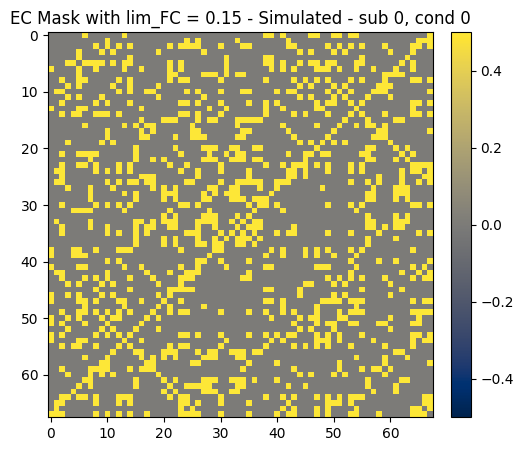

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 249.04477271806257
optimisation step: 2 ; model error = 3.990570313123157
optimisation step: 3 ; model error = 2.484692275626141
optimisation step: 4 ; model error = 5.742938031946435
optimisation step: 5 ; model error = 1.7758296628107415
optimisation step: 6 ; model error = 2.4681037916368602
optimisation step: 7 ; model error = 2.4718951711780326
optimisation step: 8 ; model error = 4.878800500450868
optimisation step: 9 ; model error = 1.95353875580385
optimisation step: 10 ; model error = 2.043544775772582
optimisation step: 11 ; model error = 2.8227342267071878
optimisation step: 12 ; model error = 2.403413283598015
optimisation step: 13 ; model error = 5.456188864946849
optimisation step: 14 ; model error = 2.338603429077038
optimisation step: 15 ; model error = 709.137051115844
optimisation step: 16 ; model error = 2.7220450851021862
optimisation step: 17 ; model error = 2.3596851898003

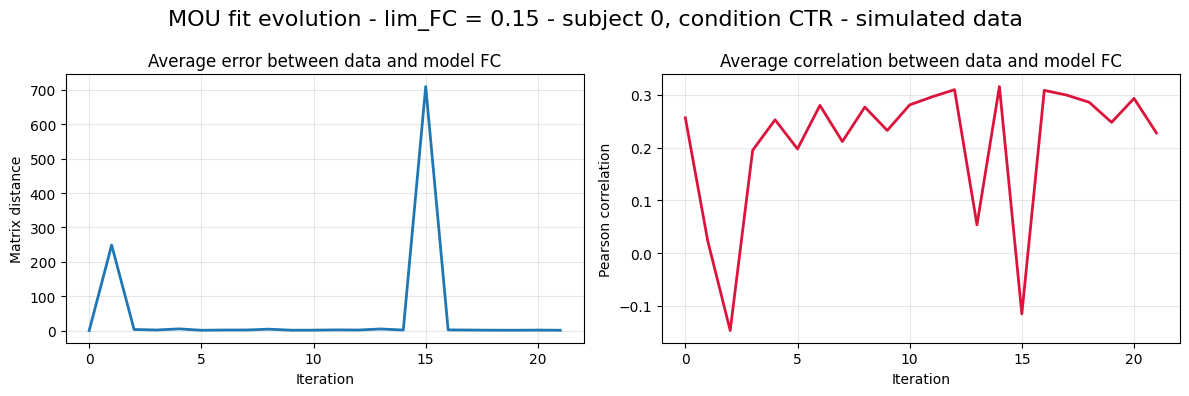

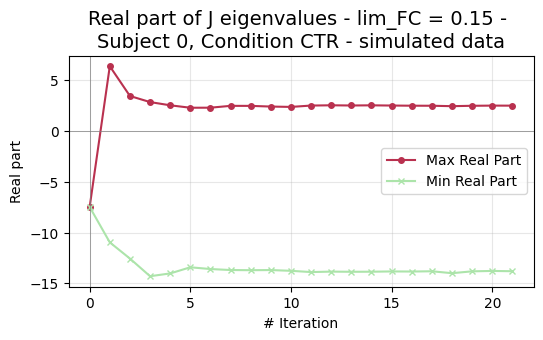

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


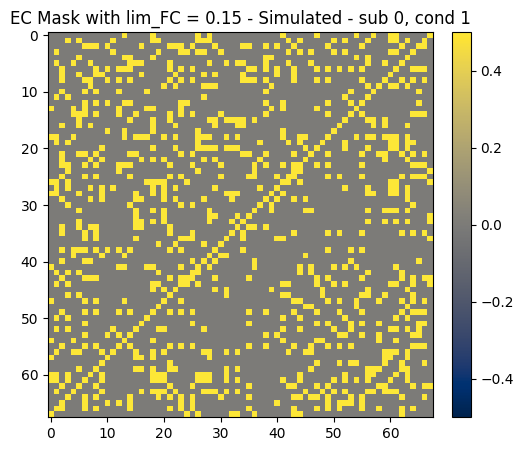

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 6.060207086172146
optimisation step: 2 ; model error = 0.9051878920127889
optimisation step: 3 ; model error = 0.9065148449711139
optimisation step: 4 ; model error = 0.9116233264091258
optimisation step: 5 ; model error = 0.9081007532234204
optimisation step: 6 ; model error = 0.9081488177068028
optimisation step: 7 ; model error = 0.9075231829858699
optimisation step: 8 ; model error = 0.9097142166299368
optimisation step: 9 ; model error = 0.9081924768871923
optimisation step: 10 ; model error = 0.9076204105053551
optimisation step: 11 ; model error = 0.9085352607830135
optimisation step: 12 ; model error = 0.9080498304557563
optimisation step: 13 ; model error = 0.9092315000346745
optimisation step: 14 ; model error = 0.9085993769108576
optimisation step: 15 ; model error = 0.9069125492597744
optimisation step: 16 ; model error = 0.9071925281481088
optimisation step: 17 ; model error = 0.908

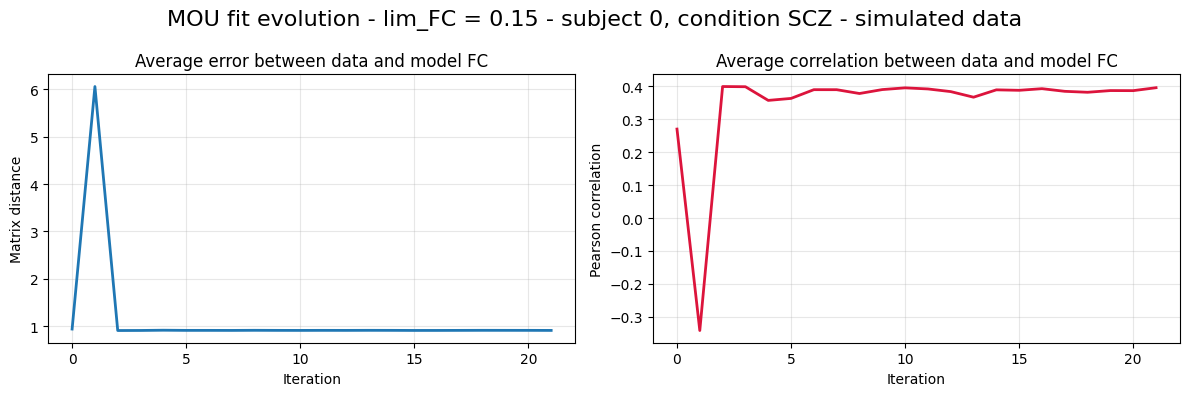

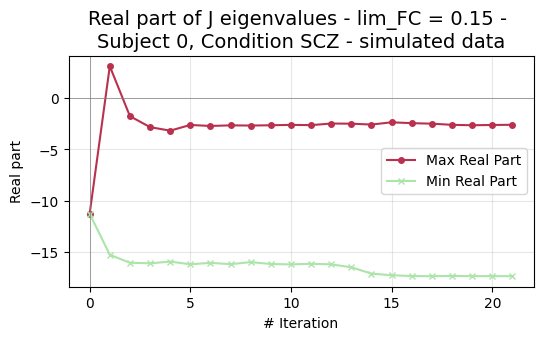

100%|██████████| 1/1 [00:03<00:00,  3.93s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 34.626325717111236
Mean distance FC1: 116997.25602525049

Testing lim_FC = 0.16


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


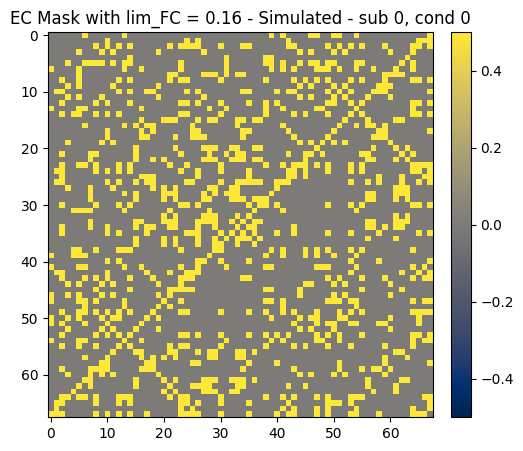

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 593.3060690923671
optimisation step: 2 ; model error = 23.889174455769187
optimisation step: 3 ; model error = 2.6911333374188606
optimisation step: 4 ; model error = 1.7409067028412974
optimisation step: 5 ; model error = 1.638853401104671
optimisation step: 6 ; model error = 1.439387505602013
optimisation step: 7 ; model error = 1.4192737890279863
optimisation step: 8 ; model error = 1.4134863867139627
optimisation step: 9 ; model error = 1.3995610115278787
optimisation step: 10 ; model error = 1.409827188894726
optimisation step: 11 ; model error = 1.3969244927677757
optimisation step: 12 ; model error = 1.4161663420366548
optimisation step: 13 ; model error = 1.4255359780177703
optimisation step: 14 ; model error = 1.4115144666523176
optimisation step: 15 ; model error = 1.4167047300258448
optimisation step: 16 ; model error = 1.4166444948781354
optimisation step: 17 ; model error = 1.42162

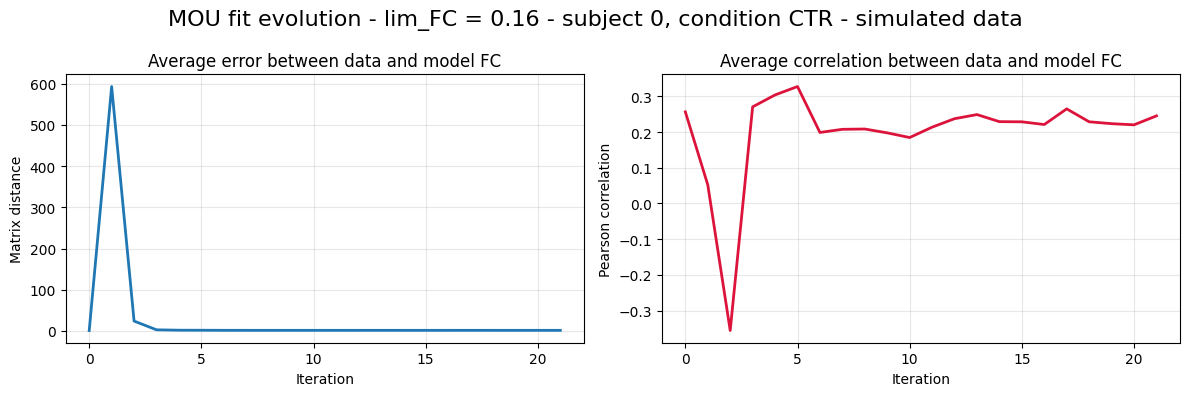

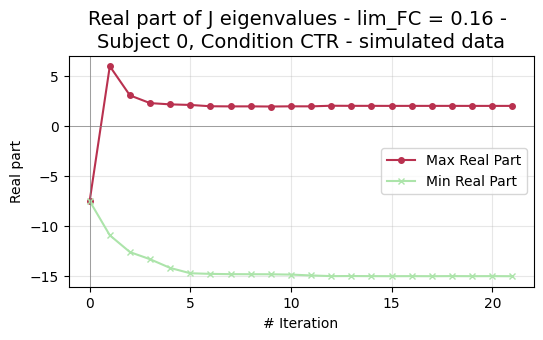

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


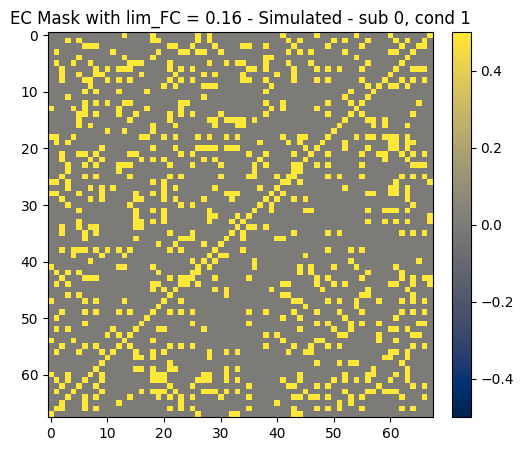

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 44.28805739694137
optimisation step: 2 ; model error = 0.8991723321609588
optimisation step: 3 ; model error = 0.9079095227160316
optimisation step: 4 ; model error = 0.9095218633972282
optimisation step: 5 ; model error = 0.9083061779377402
optimisation step: 6 ; model error = 0.9113419995020764
optimisation step: 7 ; model error = 0.9106188066435374
optimisation step: 8 ; model error = 0.9088359941363088
optimisation step: 9 ; model error = 0.9094891209246467
optimisation step: 10 ; model error = 0.9099940443775352
optimisation step: 11 ; model error = 0.9116191205149493
optimisation step: 12 ; model error = 0.9126732944637044
optimisation step: 13 ; model error = 0.9093065502469426
optimisation step: 14 ; model error = 0.9099763931945823
optimisation step: 15 ; model error = 0.9099084804821163
optimisation step: 16 ; model error = 0.9091697738728967
optimisation step: 17 ; model error = 0.908

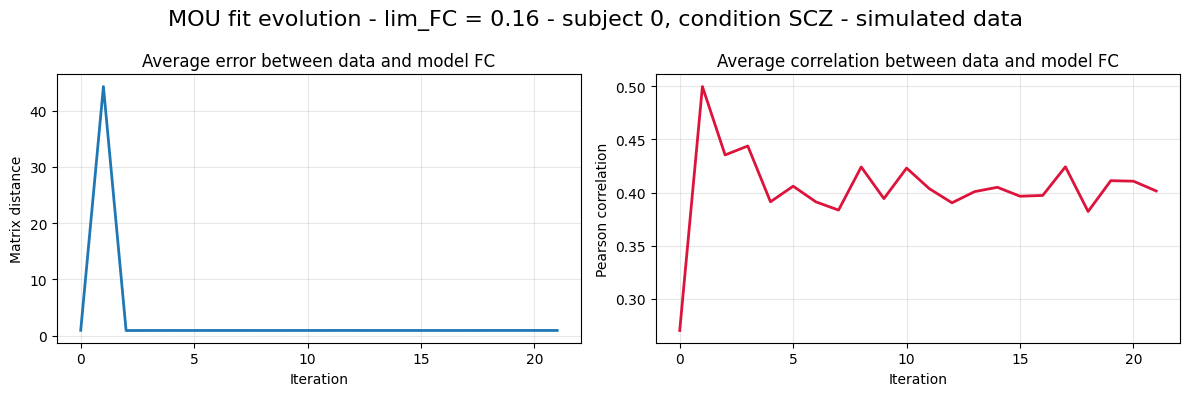

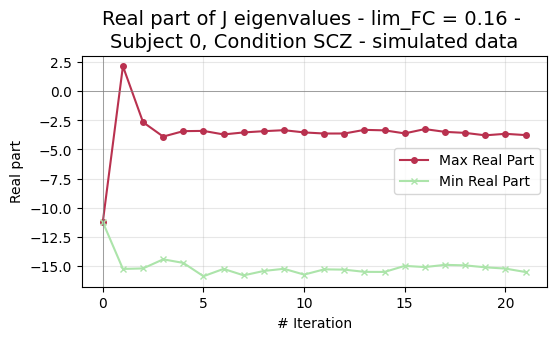

100%|██████████| 1/1 [00:05<00:00,  5.51s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 35.46060767218941
Mean distance FC1: 116998.74994036966

Testing lim_FC = 0.18


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


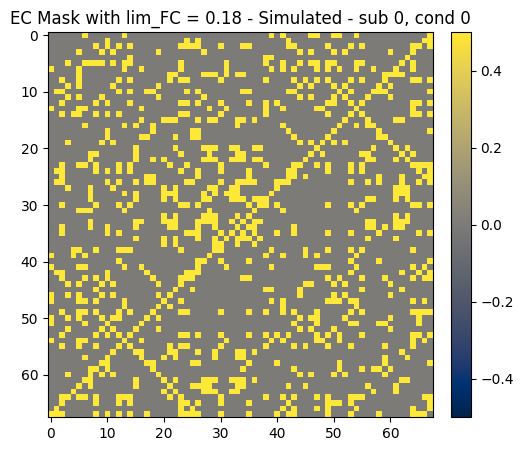

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 29.930362815277125
optimisation step: 2 ; model error = 54.43131146436331
optimisation step: 3 ; model error = 1.48256966378395
optimisation step: 4 ; model error = 1.3393270657790775
optimisation step: 5 ; model error = 1.3372634704456183
optimisation step: 6 ; model error = 1.8680020011371297
optimisation step: 7 ; model error = 24.664389608696823
optimisation step: 8 ; model error = 1.2987090892648854
optimisation step: 9 ; model error = 1.3051072930732703
optimisation step: 10 ; model error = 1.82501787951783
optimisation step: 11 ; model error = 1.3151025732362354
optimisation step: 12 ; model error = 1.3042747431005228
optimisation step: 13 ; model error = 1.4696640856235108
optimisation step: 14 ; model error = 1.2775982982846337
optimisation step: 15 ; model error = 1.2526321899697304
optimisation step: 16 ; model error = 1.263985808968389
optimisation step: 17 ; model error = 1.2493845

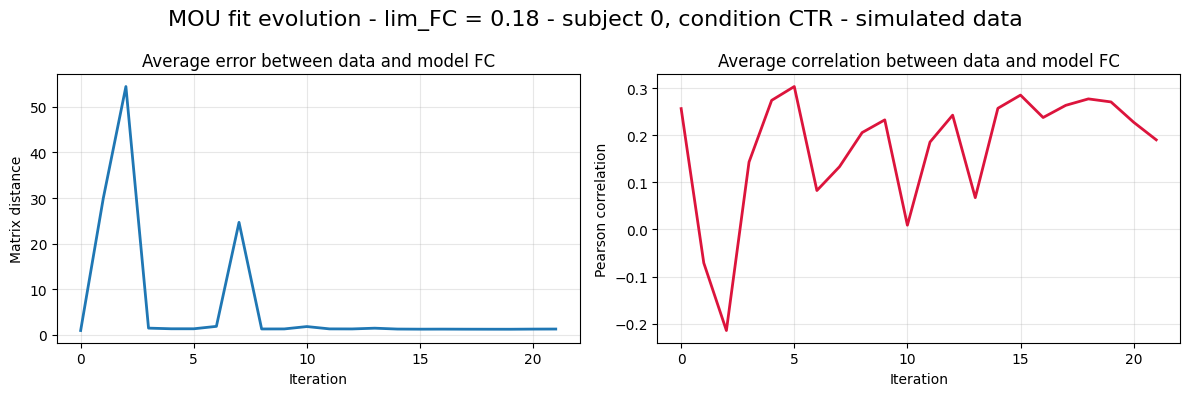

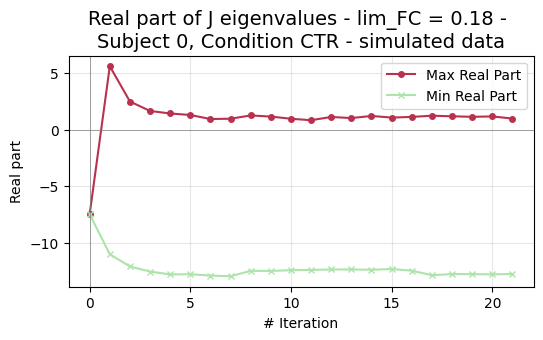

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


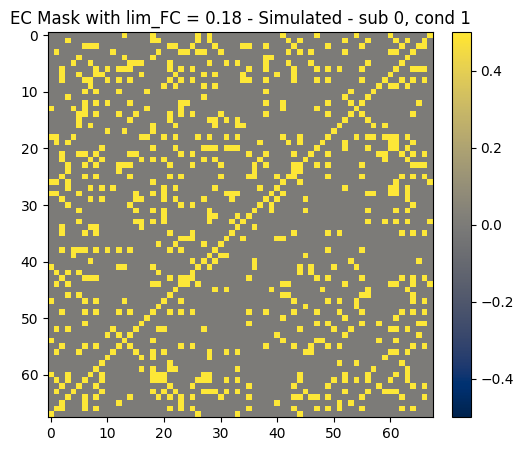

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 2.811316588481994
optimisation step: 2 ; model error = 0.9031002587095148
optimisation step: 3 ; model error = 0.9094080744098034
optimisation step: 4 ; model error = 0.9114558620587929
optimisation step: 5 ; model error = 0.907686085879768
optimisation step: 6 ; model error = 0.9115259098306449
optimisation step: 7 ; model error = 0.912099673676372
optimisation step: 8 ; model error = 0.9101256422293826
optimisation step: 9 ; model error = 0.9125203878245691
optimisation step: 10 ; model error = 0.9110122569159327
optimisation step: 11 ; model error = 0.9146315070951584
optimisation step: 12 ; model error = 0.9150004371716585
optimisation step: 13 ; model error = 0.9109792129034091
optimisation step: 14 ; model error = 0.9104841395623041
optimisation step: 15 ; model error = 0.9141608455371195
optimisation step: 16 ; model error = 0.9143267800102639
optimisation step: 17 ; model error = 0.90838

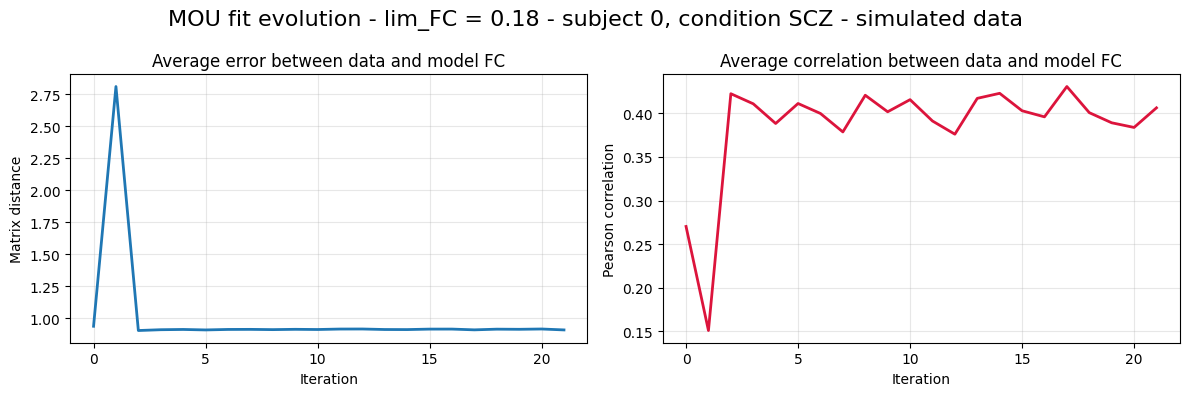

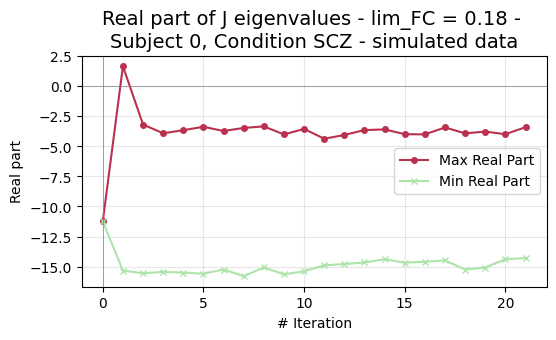

100%|██████████| 1/1 [00:03<00:00,  3.84s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 36.321771911352066
Mean distance FC1: 117000.07822457273

Testing lim_FC = 0.19


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


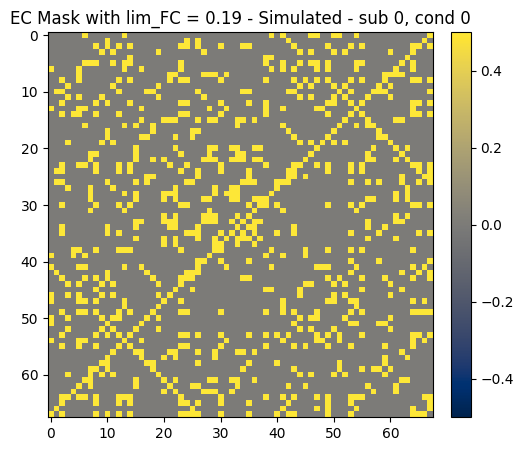

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 19.06983543320474
optimisation step: 2 ; model error = 2.767721262160412
optimisation step: 3 ; model error = 1.6272846188674843
optimisation step: 4 ; model error = 1.487163434139719
optimisation step: 5 ; model error = 2.0762626470804495
optimisation step: 6 ; model error = 5.4059441044797
optimisation step: 7 ; model error = 2.8213053617590944
optimisation step: 8 ; model error = 1.4407591028241902
optimisation step: 9 ; model error = 1.687029240876827
optimisation step: 10 ; model error = 1.5863651427675431
optimisation step: 11 ; model error = 1.7228617322372575
optimisation step: 12 ; model error = 1.6890392356126656
optimisation step: 13 ; model error = 1.9485092473979861
optimisation step: 14 ; model error = 1.7614474249970666
optimisation step: 15 ; model error = 1.585067702992176
optimisation step: 16 ; model error = 1.6443566905061817
optimisation step: 17 ; model error = 1.477178384

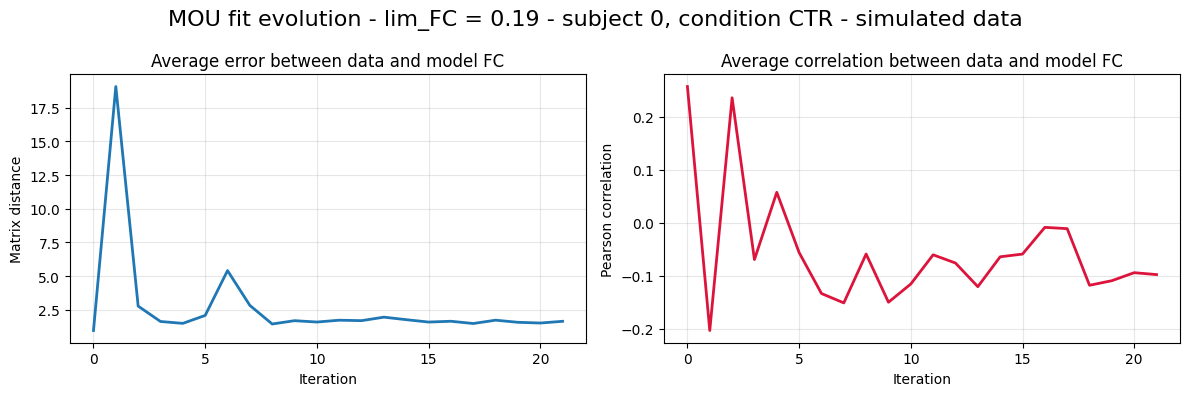

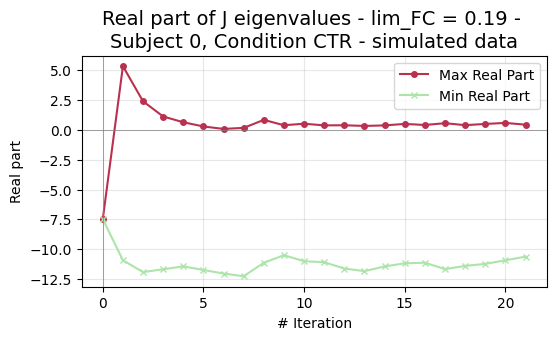

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


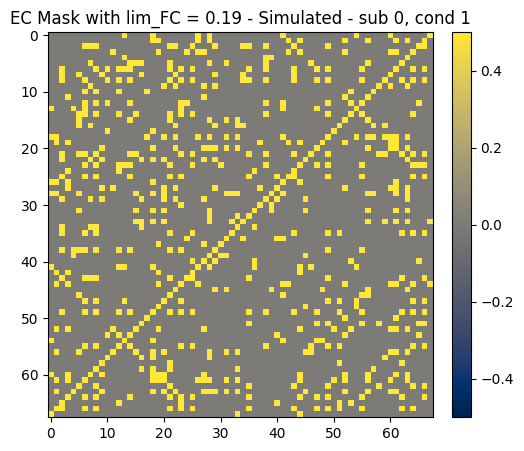

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 2.8258464793027502
optimisation step: 2 ; model error = 0.905954857770209
optimisation step: 3 ; model error = 0.9113552217541405
optimisation step: 4 ; model error = 0.9112766644871515
optimisation step: 5 ; model error = 0.9152019211660516
optimisation step: 6 ; model error = 0.9156178185591899
optimisation step: 7 ; model error = 0.9171085497630016
optimisation step: 8 ; model error = 0.9169060972250803
optimisation step: 9 ; model error = 0.9191586384818362
optimisation step: 10 ; model error = 0.9117133786605955
optimisation step: 11 ; model error = 0.9142167489590123
optimisation step: 12 ; model error = 0.9172649886271561
optimisation step: 13 ; model error = 0.9170710291462436
optimisation step: 14 ; model error = 0.9139633474163454
optimisation step: 15 ; model error = 0.9183136614661536
optimisation step: 16 ; model error = 0.9129998090181882
optimisation step: 17 ; model error = 0.915

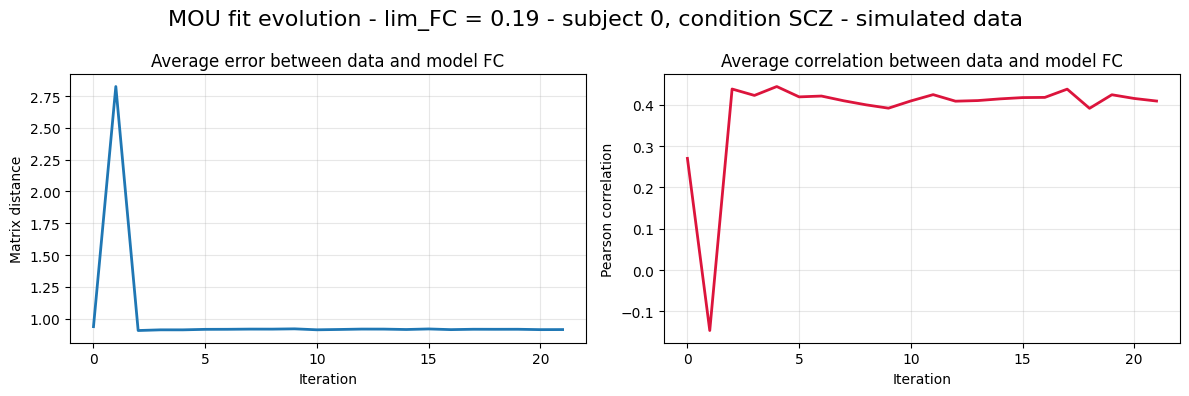

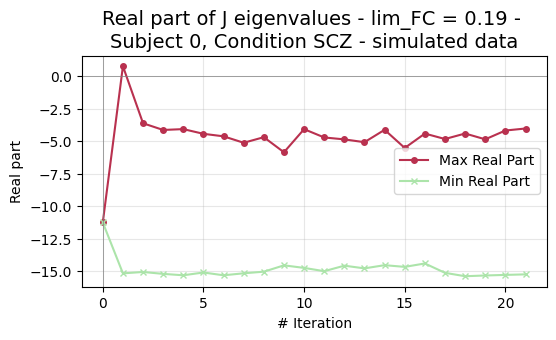

100%|██████████| 1/1 [00:07<00:00,  7.84s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 37.31806530929423
Mean distance FC1: 117001.63646974297

Testing lim_FC = 0.21


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


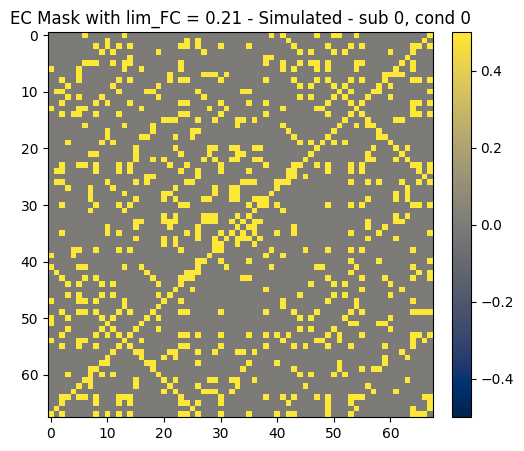

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 14.86959726754507
optimisation step: 2 ; model error = 1.8421275223444815
optimisation step: 3 ; model error = 1.454032849229995
optimisation step: 4 ; model error = 1.7537734411243147
optimisation step: 5 ; model error = 3.5579554191816074
optimisation step: 6 ; model error = 1.284340326211602
optimisation step: 7 ; model error = 1.6384398076166466
optimisation step: 8 ; model error = 1.983942386521004
optimisation step: 9 ; model error = 2.768804346601934
optimisation step: 10 ; model error = 2.1456100249826524
optimisation step: 11 ; model error = 11.867352466143627
optimisation step: 12 ; model error = 5.754588452456916
optimisation step: 13 ; model error = 2.0445881118472196
optimisation step: 14 ; model error = 2.14532582345399
optimisation step: 15 ; model error = 1.9152705974890887
optimisation step: 16 ; model error = 75.53792883277146
optimisation step: 17 ; model error = 6.4437426537

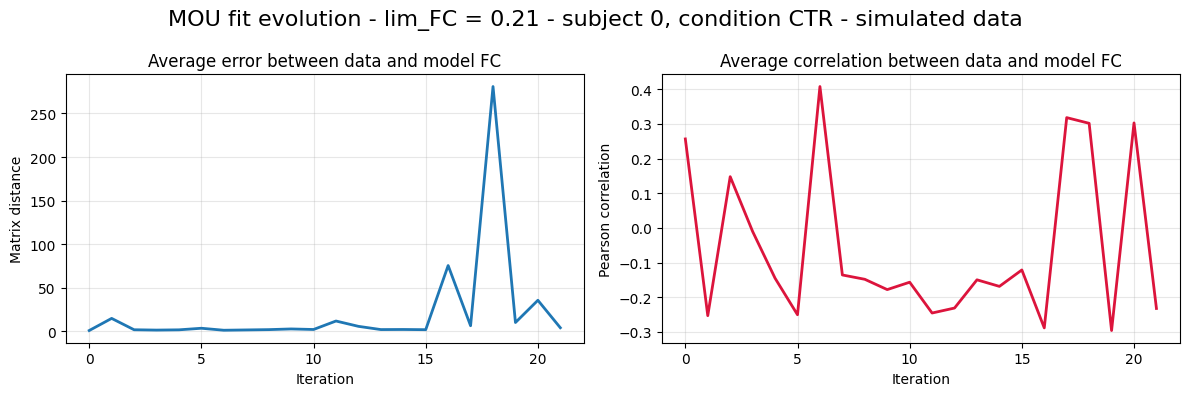

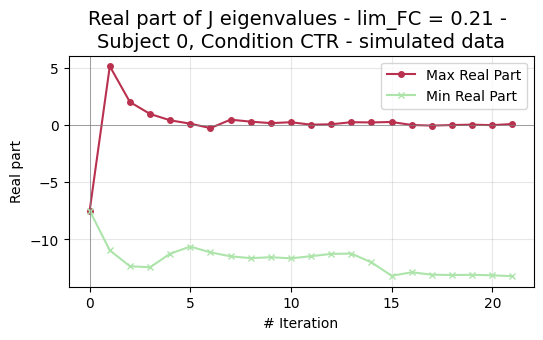

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


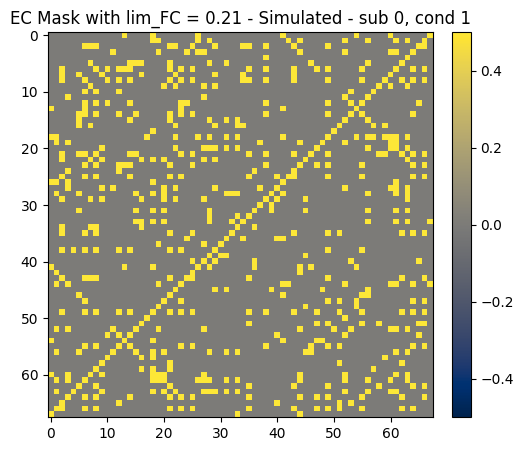

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 3.049406084142255
optimisation step: 2 ; model error = 0.9070894293103473
optimisation step: 3 ; model error = 0.91206203147478
optimisation step: 4 ; model error = 0.9161981559540315
optimisation step: 5 ; model error = 0.9136854754399621
optimisation step: 6 ; model error = 0.9197198995123872
optimisation step: 7 ; model error = 0.9156743815559751
optimisation step: 8 ; model error = 0.9161921907662404
optimisation step: 9 ; model error = 0.9159845610270907
optimisation step: 10 ; model error = 0.916497715848553
optimisation step: 11 ; model error = 0.9157055591230776
optimisation step: 12 ; model error = 0.9162472924813838
optimisation step: 13 ; model error = 0.9154399262018468
optimisation step: 14 ; model error = 0.9161726872064184
optimisation step: 15 ; model error = 0.9163565920894912
optimisation step: 16 ; model error = 0.9169996660606105
optimisation step: 17 ; model error = 0.916930

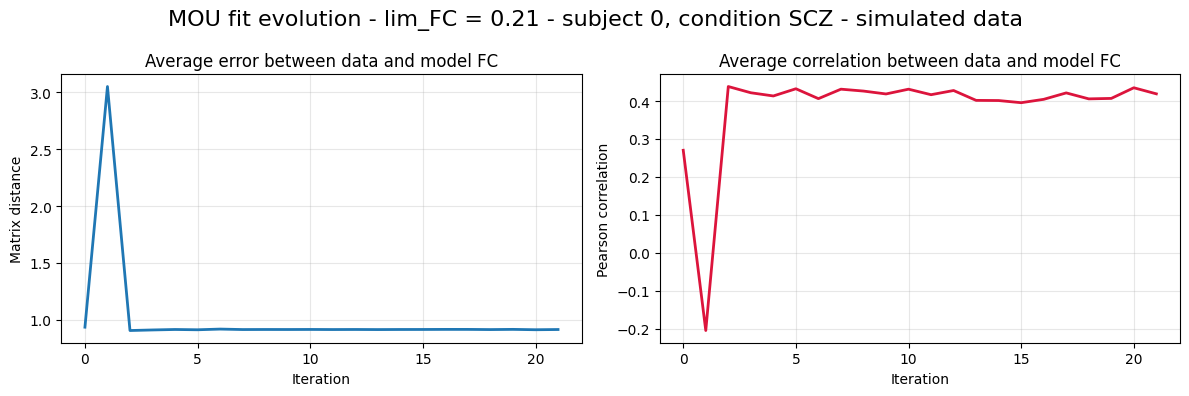

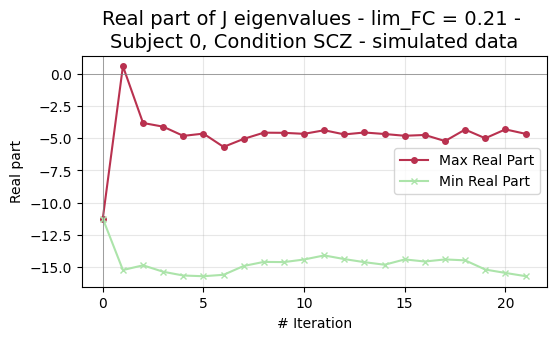

100%|██████████| 1/1 [00:06<00:00,  6.30s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 39.1284339515973
Mean distance FC1: 117004.88316514253

Testing lim_FC = 0.22


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


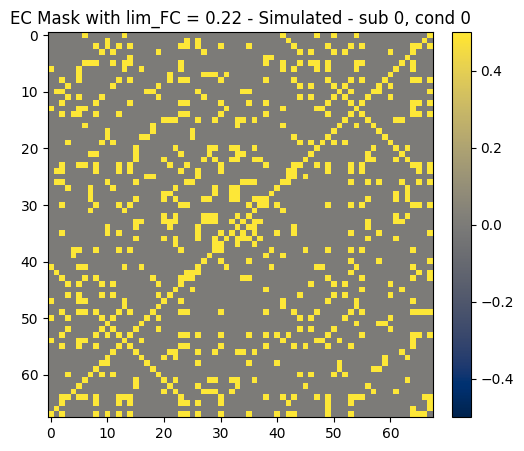

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 13.400216213708108
optimisation step: 2 ; model error = 1.6649964450952714
optimisation step: 3 ; model error = 1.4792781151086185
optimisation step: 4 ; model error = 0.9178125391606878
optimisation step: 5 ; model error = 4.2506528953805915
optimisation step: 6 ; model error = 7.642519858035582
optimisation step: 7 ; model error = 178.65290154756303
optimisation step: 8 ; model error = 28.247586020924373
optimisation step: 9 ; model error = 11.130276558566454
optimisation step: 10 ; model error = 3.4316224979374983
optimisation step: 11 ; model error = 0.9434269893980425
optimisation step: 12 ; model error = 1.7933378336638566
optimisation step: 13 ; model error = 2.9911667557038837
optimisation step: 14 ; model error = 1.9644757172357612
optimisation step: 15 ; model error = 4.058010420822658
optimisation step: 16 ; model error = 6.744686036226865
optimisation step: 17 ; model error = 6.1285

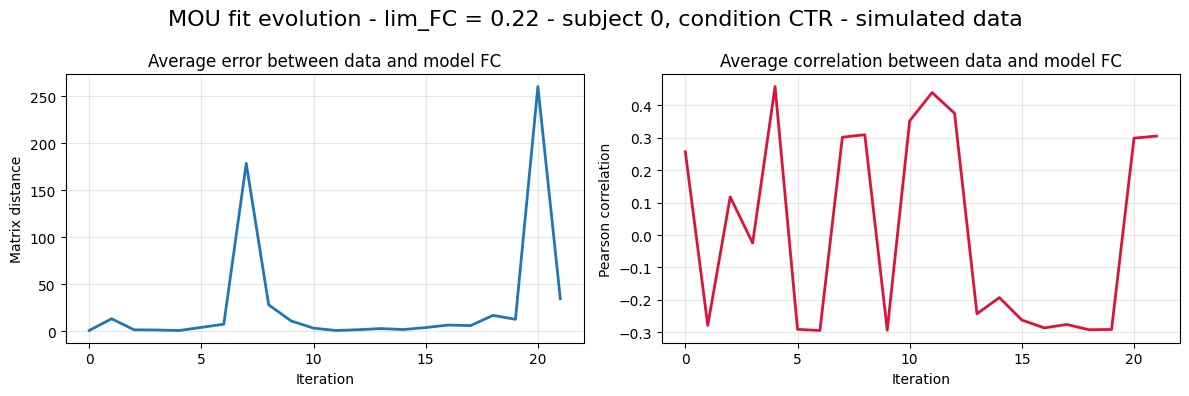

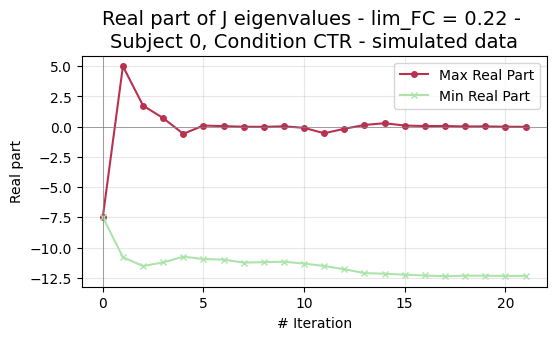

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


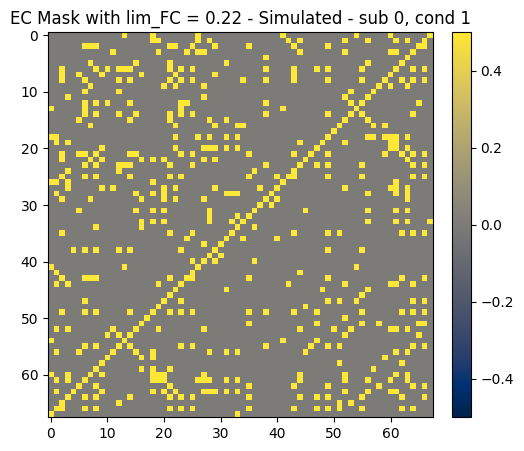

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 36.15138020178523
optimisation step: 2 ; model error = 0.9111846859479946
optimisation step: 3 ; model error = 0.9155019698374314
optimisation step: 4 ; model error = 0.918337280295473
optimisation step: 5 ; model error = 0.919294817002134
optimisation step: 6 ; model error = 0.9162876940555678
optimisation step: 7 ; model error = 0.9166616470801006
optimisation step: 8 ; model error = 0.9191285232715516
optimisation step: 9 ; model error = 0.9191419298358223
optimisation step: 10 ; model error = 0.9144344833162759
optimisation step: 11 ; model error = 0.9186081373307502
optimisation step: 12 ; model error = 0.9186485374378067
optimisation step: 13 ; model error = 0.9147967109418625
optimisation step: 14 ; model error = 0.9186064586344825
optimisation step: 15 ; model error = 0.9200182955938827
optimisation step: 16 ; model error = 0.9189660372779801
optimisation step: 17 ; model error = 0.91607

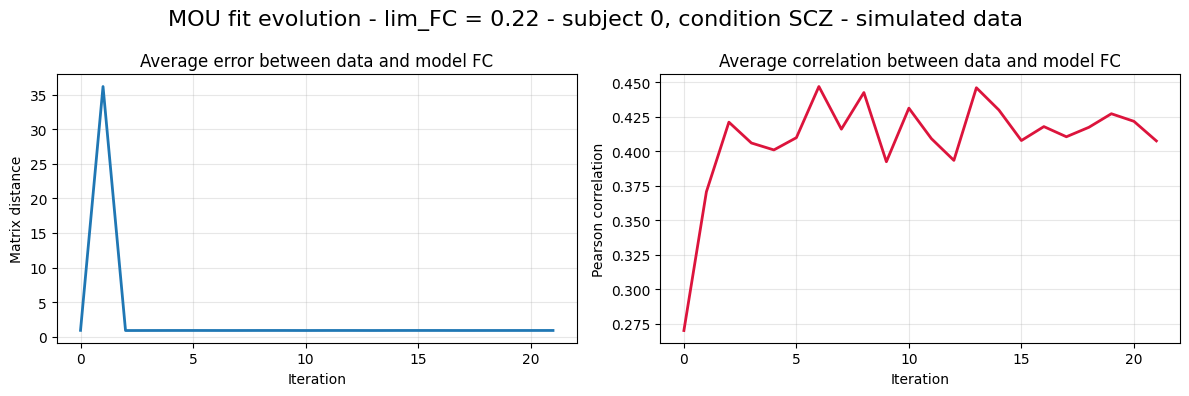

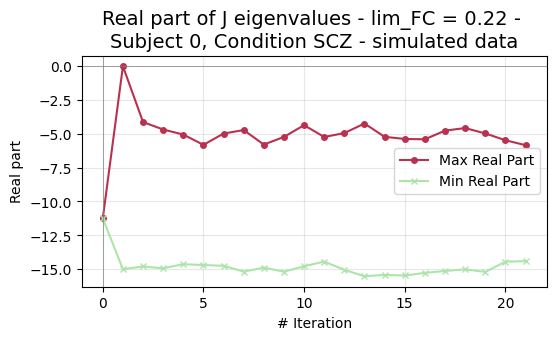

100%|██████████| 1/1 [00:05<00:00,  5.61s/it]


Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 51.227026790331124
Mean distance FC1: 117028.37644592037

Testing lim_FC = 0.24


  0%|          | 0/1 [00:00<?, ?it/s]

Q_data_temp shape: (2, 68, 68)
sub 0, cond 0: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 17.499617919322528
Q1 norm: 17.499617919322528


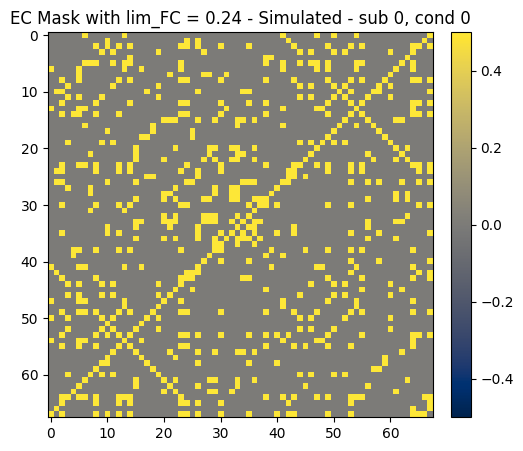

optimisation step: 0 ; model error = 0.9563891951403651
optimisation step: 1 ; model error = 10.187383549789963
optimisation step: 2 ; model error = 1.5824771859257485
optimisation step: 3 ; model error = 1.9484343786707248
optimisation step: 4 ; model error = 0.9581655796616798
optimisation step: 5 ; model error = 1.008582360359704
optimisation step: 6 ; model error = 0.9190385560052332
optimisation step: 7 ; model error = 3.510261493719943
optimisation step: 8 ; model error = 0.9346887239463961
optimisation step: 9 ; model error = 1.2129672699108744
optimisation step: 10 ; model error = 0.9222855165156602
optimisation step: 11 ; model error = 1.8508466887242672
optimisation step: 12 ; model error = 6.317401557994518
optimisation step: 13 ; model error = 1.5115833583156773
optimisation step: 14 ; model error = 2.298825097331489
optimisation step: 15 ; model error = 0.9559872833781236
optimisation step: 16 ; model error = 0.9224325036441183
optimisation step: 17 ; model error = 1.90920

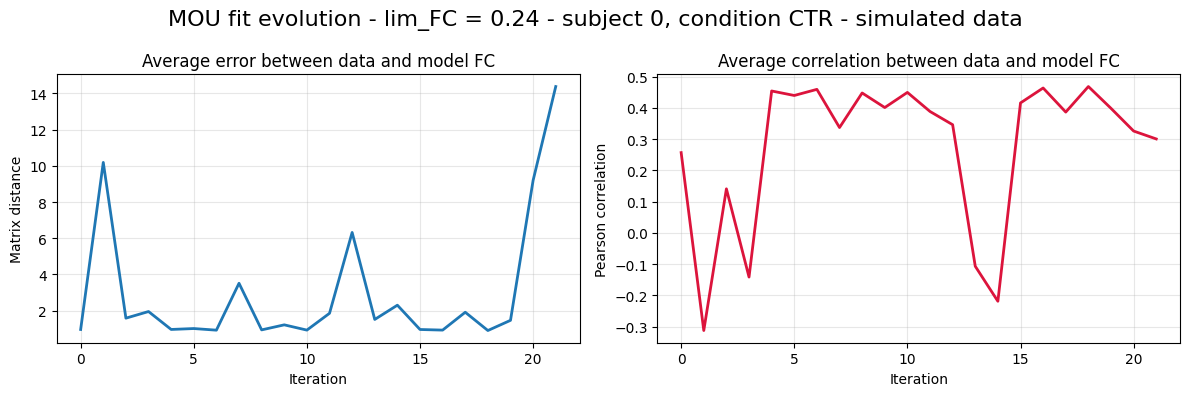

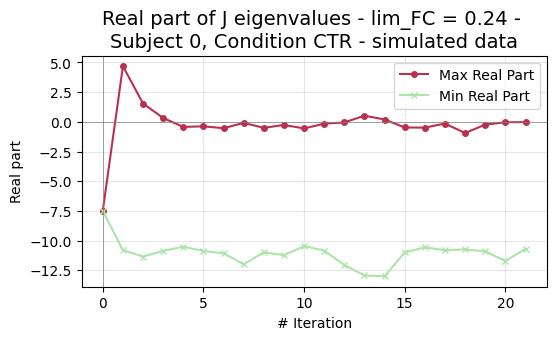

Q_data_temp shape: (2, 68, 68)
sub 0, cond 1: max asymmetry FC0=1.110e-16, FC1=1.110e-16
Q0 finite: True
Q1 finite: True
Q0 symmetric max err: 1.1102230246251565e-16
Q1 diagonal min/max: 0.9999999999999998 1.0
Q1 positive diagonal fraction: 1.0
Q0 norm: 15.177651209258688
Q1 norm: 15.177651209258688


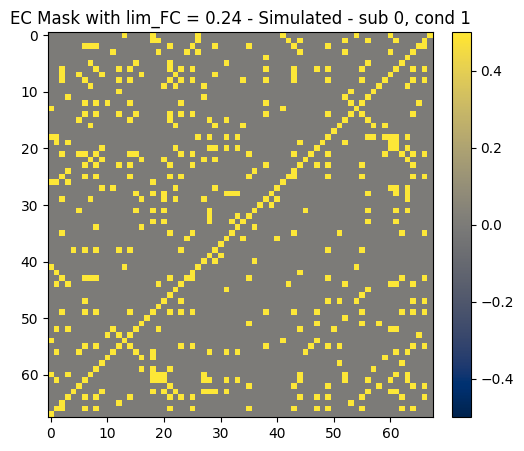

optimisation step: 0 ; model error = 0.936497507547065
optimisation step: 1 ; model error = 1.3088018678404736
optimisation step: 2 ; model error = 0.9105441759627715
optimisation step: 3 ; model error = 0.9166812730813992
optimisation step: 4 ; model error = 0.9175755838738031
optimisation step: 5 ; model error = 0.919484240936844
optimisation step: 6 ; model error = 0.9176479699946953
optimisation step: 7 ; model error = 0.9184601316535241
optimisation step: 8 ; model error = 0.9187661633680952
optimisation step: 9 ; model error = 0.9200592762192552
optimisation step: 10 ; model error = 0.9184288508474917
optimisation step: 11 ; model error = 0.9231097243696436
optimisation step: 12 ; model error = 0.9161970780708968
optimisation step: 13 ; model error = 0.919514035428816
optimisation step: 14 ; model error = 0.9193982923505317
optimisation step: 15 ; model error = 0.9188916125312115
optimisation step: 16 ; model error = 0.9215056789506062
optimisation step: 17 ; model error = 0.9198

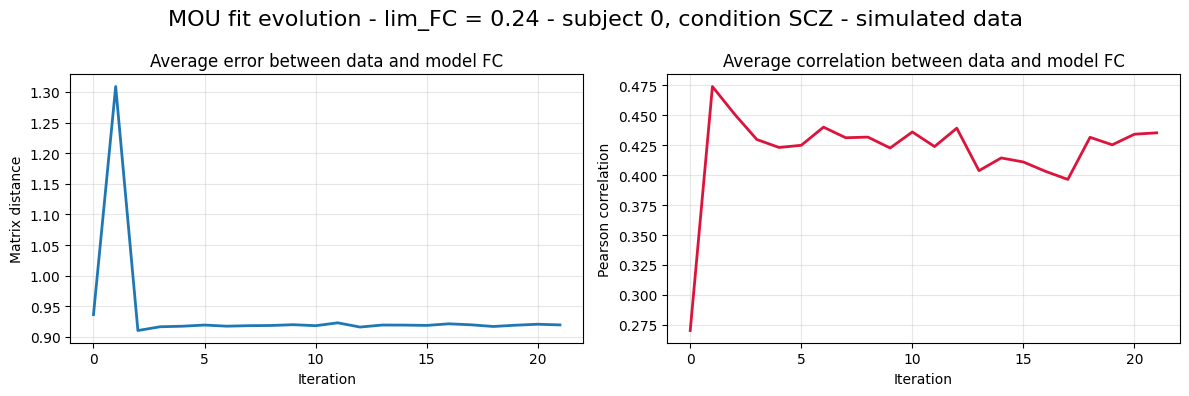

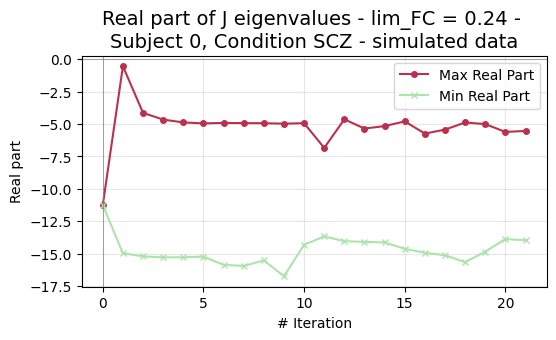

100%|██████████| 1/1 [00:04<00:00,  4.28s/it]

Mean iterations: 22.0
Max iterations: 22
Mean distance FC0: 56.510008651846704
Mean distance FC1: 117038.39279462738


In [51]:
verbose=True

## TEST : change min_iter
min_iter = 20
## END TEST 

# Initialize average FC0 and FC1 distance
avg_dist_FC0 = 0.0
avg_dist_FC1 = 0.0

## TEST : fit MOU with different values of lim_FC
lim_FC_array = np.arange(0.01,0.25, 0.015)
## END TEST 

# loop over lim_FC values
for lim_FC_temp in lim_FC_array:
    print(f"\nTesting lim_FC = {lim_FC_temp:.2f}")
    lim_FC = lim_FC_temp # limit DTI value to determine SC (only connections with larger values are tuned)
    # loop over subject and conditions
    for i_sub in tqdm.tqdm(range(n_sub)):
        for i_cond in range(n_cond):
            # get time series
            Q_data_temp = Q_data[:,i_sub,:,:,i_cond]
            print("Q_data_temp shape:", Q_data_temp.shape)
            # store empirical BOLD variance (48, 68, 152, 2)
            #FC0 = Q_data_temp[0]
            #FC1 = Q_data_temp[1]
            FC0 = np.corrcoef(new_array[i_sub,:,:,i_cond]) 
            FC1 = FC0/np.max(FC0)
            ## debugging
            #FC0 = FC0 + np.eye(N)
            #FC1 = FC1 + np.eye(N)
            #Q_data_temp[0] = FC0
            #Q_data_temp[1] = FC1
            # 1) Basic sanity checks
            print(f"sub {i_sub}, cond {i_cond}: max asymmetry FC0={sym0:.3e}, FC1={sym1:.3e}")
            print("Q0 finite:", np.isfinite(FC0).all())
            print("Q1 finite:", np.isfinite(FC1).all())
            print("Q0 symmetric max err:", np.max(np.abs(FC0 - FC0.T)))
            print("Q1 diagonal min/max:", np.min(np.diag(FC1)), np.max(np.diag(FC1)))
            print("Q1 positive diagonal fraction:", np.mean(np.diag(FC1) > 0))
            print("Q0 norm:", np.linalg.norm(FC0))
            print("Q1 norm:", np.linalg.norm(FC1))
            ##
            mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
            mask_EC[FC1>lim_FC] = True
            for i in range(N):
                mask_EC[i,i] = False # no self connection
                mask_EC[i,N-1-i] = True # additional interhemispherical connections
            ##debugging
            fig_dbg, ax_dbg = plt.subplots(figsize=(6, 5))
            ax_dbg.imshow(mask_EC, vmin=-0.5, vmax=0.5, cmap='bwr')
            # add a colorbar
            plt.colorbar(ax_dbg.imshow(mask_EC, vmin=-0.5, vmax=0.5, cmap='cividis'), ax=ax_dbg, fraction=0.046, pad=0.04)
            ax_dbg.set_title(f"EC Mask with lim_FC = {lim_FC:.2f} - {situations[situation_idx].capitalize()} - sub {i_sub}, cond {i_cond}")
            # Save figure
            fig_name = f"EC_mask_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}_limFC_{lim_FC:.2f}"
            plt.savefig(os.path.join(presentation_figs_dir, f"{fig_name}.{graph_format}"), format=graph_format, dpi=300)
            plt.show()
            plt.close()
            # invert model
            mou_est = MOUv2()
            mou_est.fit_Q(Q_emp = Q_data_temp, mask_C=mask_EC, mask_Sigma=mask_Sigma, algo_version="true", min_iter=min_iter, epsilon_C=0.005, epsilon_Sigma=0.005*N,
                        track_eigs=True, eigs_every=1, eigs_store_full=False, verbose=True)

            # test : save nb of iterations
            iter_mod[i_sub, i_cond] = mou_est.d_fit["iterations"]

            # store results
            J_mod[i_sub,i_cond,:,:] = mou_est.J
            Sigma_mod[i_sub,i_cond,:,:] = mou_est.Sigma
            FC0_mod[i_sub,i_cond,:,:] = spl.solve_lyapunov(J_mod[i_sub,i_cond,:,:].T, -Sigma_mod[i_sub,i_cond,:,:])
            err_mod[i_sub,i_cond] = mou_est.d_fit['distance']
            fit_mod[i_sub,i_cond] = mou_est.d_fit['correlation']
            
            # Update average distances for FC0 and FC1
            avg_dist_FC0 += mou_est.d_fit['distFC0']
            avg_dist_FC1 += mou_est.d_fit['distFC1']

            if verbose:
                print('sub', i_sub, '; cond', i_cond, ':', mou_est.d_fit)
                
                d = mou_est.d_fit
                n_it = int(d["iterations"])

                # Error btw model and data for FC0 and FC1 (matrix distance) -> = 0.5 * (dist_Q0 + dist_Qtau)
                dist_hist = np.asarray(d["distance history"][:n_it])
                # Corr between model and empirical data for FC0 and FC1 -> =  0.5 * (Pearson_Q0  + Pearson_Qtau)
                corr_hist = np.asarray(d["correlation history"][:n_it])

                # Print eigenvalues
                #for iter_idx, eigs in enumerate(d['eigs_history']):
                #   print(f"Iteration {iter_idx}: min real part of eigenvalues = {np.min(np.real(eigs)):.4f}, max real part of eigenvalues = {np.max(np.real(eigs)):.4f}")    

                fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        
                ax[0].plot(dist_hist, lw=2)
                ax[0].set_title("Average error between data and model FC")
                ax[0].set_xlabel("Iteration")
                ax[0].set_ylabel("Matrix distance")
                ax[0].grid(alpha=0.3)

                ax[1].plot(corr_hist, lw=2, color="crimson")
                ax[1].set_title("Average correlation between data and model FC")
                
                ax[1].set_xlabel("Iteration")
                ax[1].set_ylabel("Pearson correlation")
                ax[1].grid(alpha=0.3)

                plt.suptitle(f"MOU fit evolution - lim_FC = {lim_FC:.2f} - subject {i_sub}, condition {conds[i_cond]} - {situations[situation_idx]} data", fontsize=16)
                plt.tight_layout()
                # Save figure
                fig_name = f"MOU_fit_evolution_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}_limFC_{lim_FC:.2f}"
                plt.savefig(os.path.join(presentation_figs_dir, f"{fig_name}.{graph_format}"), format=graph_format, dpi=300)
                plt.show()
                plt.close()

                # Plot evolution of max and min real part of eigenvalues across iterations
                plt.figure(figsize=(6, 3))
                plt.plot(d['eig_iter'], d['eig_max_real'], 'o-', markersize=4, color = '#B9314F',label='Max Real Part')
                plt.plot(d['eig_iter'], d['eig_min_real'], 'x-', markersize=4, color = '#ACE4AA', label='Min Real Part')
                plt.axhline(0, color='gray', lw=0.5)
                plt.axvline(0, color='gray', lw=0.5)
                plt.title(f"Real part of J eigenvalues - lim_FC = {lim_FC:.2f} - \nSubject {i_sub}, Condition {conds[i_cond]} - {situations[situation_idx]} data", fontsize=14)
                plt.ylabel("Real part")
                plt.xlabel("# Iteration")
                plt.grid(alpha=0.3)
                plt.legend()
                fig_name = f"eigenvalues_real_part_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}_limFC_{lim_FC:.2f}"
                plt.savefig(os.path.join(presentation_figs_dir, f"{fig_name}.{graph_format}"), format=graph_format, dpi=300)
                plt.show()
                plt.close()

    print("Mean iterations:", iter_mod.mean())
    print("Max iterations:", iter_mod.max())
    print("Mean distance FC0:", avg_dist_FC0 / (n_sub * n_cond))
    print("Mean distance FC1:", avg_dist_FC1 / (n_sub * n_cond))

### End of test 4.0

#### Test goodness of fit

C:\Users\Bruna\AppData\Local\Temp\ipykernel_15784\3228635675.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_15784\3228635675.py:15: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_15784\3228635675.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=fit_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_15784\3228635675.py:42: UserWarning: The palet

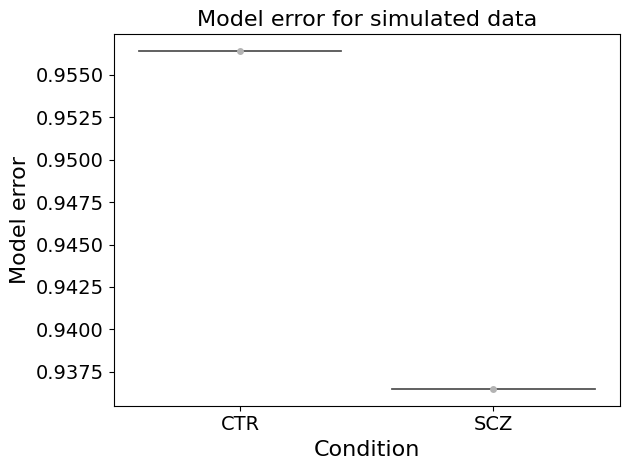

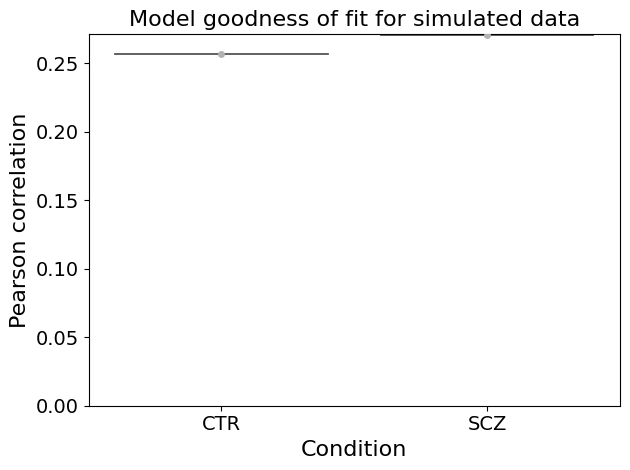

In [25]:
mask_diag = np.eye(N, dtype=bool) # mask for diagonal elements

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]] # colors

# Model error computation
err_mod_tmp = dict()
err_mod_tmp['sum EC'] = err_mod.flatten()
err_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
err_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

err_mod_df = pd.DataFrame(err_mod_tmp)

# Model error plot
plt.figure()
sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
sb.swarmplot(data=err_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
#plt.axis(ymin=0, ymax=0.8)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model error for {situations[situation_idx]} data', fontsize=16)
plt.xlabel('Condition',fontsize=16)
plt.ylabel('Model error',fontsize=16)

plt.tight_layout()
# Save figure
fig_path = os.path.join(presentation_figs_dir, f'MOU_model_error_{situations[situation_idx]}.{graph_format}')
#plt.savefig(res_dir+'model_fit_error.eps', format='eps')
plt.savefig(fig_path, dpi=300)


# Pearson correlation
fit_mod_tmp = dict()
fit_mod_tmp['sum EC'] = fit_mod.flatten()
fit_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
fit_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

fit_mod_df = pd.DataFrame(fit_mod_tmp)

# Correlation violin plot
plt.figure()
sb.violinplot(data=fit_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
sb.swarmplot(data=fit_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
plt.axis(ymin=0)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model goodness of fit for {situations[situation_idx]} data',fontsize=16)
plt.xlabel('Condition',fontsize=16)
plt.ylabel('Pearson correlation',fontsize=16)
plt.tight_layout()

# Save figure
fig_path = os.path.join(presentation_figs_dir, f'MOU_model_goodness_fit_{situations[situation_idx]}.{graph_format}')
plt.savefig(fig_path, dpi=300)


# Example EC

# plt.figure(figsize=(5,4))
# plt.imshow(np.maximum(J_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
# #plt.imshow(J_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
# plt.colorbar()
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel('Target ROI index', fontsize=16)
# plt.ylabel('Source ROI index', fontsize=16)
# plt.tight_layout()
# plt.savefig(res_dir+'example_EC.eps', format='eps')

# # Example EC

# plt.figure(figsize=(5,4))
# #plt.imshow(np.maximum(Sigma_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
# plt.imshow(Sigma_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
# plt.colorbar()
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel('Target ROI index', fontsize=16)
# plt.ylabel('Source ROI index', fontsize=16)
# plt.tight_layout()
# plt.savefig(res_dir+'example_EC.eps', format='eps')

In [132]:
# Print average pearson correlation for each condition
print(f"Average Pearson correlation between model and data FC\n")
print(f"Controls: {fit_mod_df[fit_mod_df['cond'] == 'CTR']['sum EC'].mean():.4f}")
print(f"Schizophrenia: {fit_mod_df[fit_mod_df['cond'] == 'SCZ']['sum EC'].mean():.4f}")

Average Pearson correlation between model and data FC

Controls: 0.2610
Schizophrenia: 0.2643


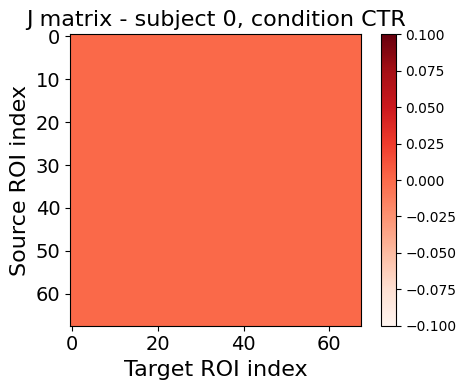

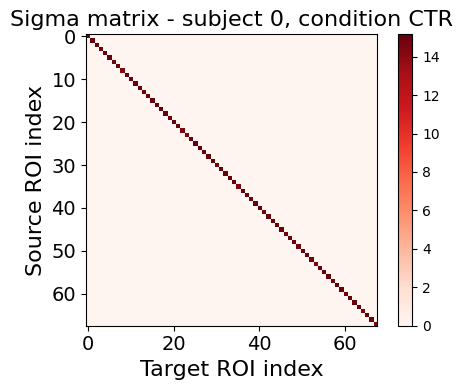

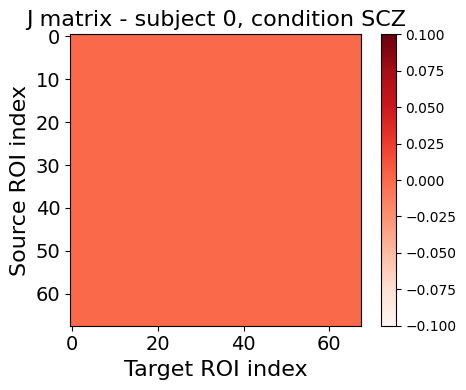

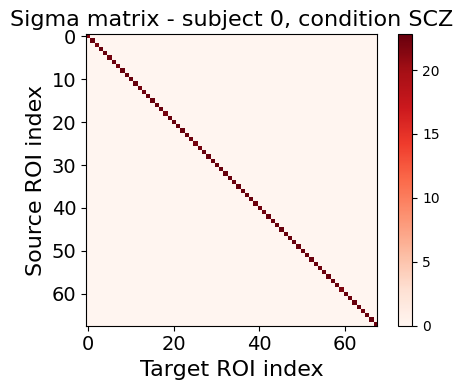

In [55]:
for i_sub in range(n_sub):
    for i_cond in range(n_cond):
        J = J_mod[i_sub, i_cond, :, :]
        Sigma = Sigma_mod[i_sub, i_cond, :, :]
        FC0 = FC0_mod[i_sub, i_cond, :, :]

        # Plotting the jacobian for one subject and conditon
        plt.figure(figsize=(5,4))
        plt.imshow(np.maximum(J_mod[i_sub,i_cond,:,:],0), cmap='Reds')   # Show only the non-negatives
        #plt.imshow(J_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
        plt.colorbar()
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(f"J matrix - subject {i_sub}, condition {conds[i_cond]}", fontsize=16)
        plt.xlabel('Target ROI index', fontsize=16)
        plt.ylabel('Source ROI index', fontsize=16)
        plt.tight_layout()
        #plt.savefig(res_dir+'example_EC.eps', format='eps')
        # Save figure
        fig_path = os.path.join(presentation_figs_dir, f'MOU_J_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}')
        plt.savefig(fig_path, dpi=300)

        ## Plotting sigma for one subject and condition
        plt.figure(figsize=(5,4))
        #plt.imshow(np.maximum(Sigma_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
        plt.imshow(Sigma_mod[i_sub,i_cond,:,:], cmap='Reds')   # Show only the non-negatives
        plt.colorbar()
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(f"Sigma matrix - subject {i_sub}, condition {conds[i_cond]}", fontsize=16)
        plt.xlabel('Target ROI index', fontsize=16)
        plt.ylabel('Source ROI index', fontsize=16)
        plt.tight_layout()
        # Save figure
        fig_path = os.path.join(presentation_figs_dir, f'MOU_Sigma_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}')
        plt.savefig(fig_path, dpi=300)

In [46]:
print(f"The average fluctuation, given by the mean of the diagonal elements of Sigma_mod: {np.mean(np.diag(Sigma_mod[0,0,:,:]))}")

The average fluctuation, given by the mean of the diagonal elements of Sigma_mod: 15.438597035534546


#### Entropy production rate calculation

In [71]:
# transpose to Saclay's framework
EPR = np.zeros([n_sub,n_cond])
Q_indiv = np.zeros([n_sub,n_cond,N,N])

for i_sub in range(n_sub):
    for i_cond in range(n_cond):

        try:
            B = np.copy(-J_mod[i_sub,i_cond,:,:].T) # B=-J
            D = np.copy(0.5 * Sigma_mod[i_sub,i_cond,:,:]) # D=1/2 * Sigma
            S = np.copy(FC0_mod[i_sub,i_cond,:,:])
            
            Q = np.dot(B, S) - D
            Q_indiv[i_sub,i_cond,:,:] = Q
            
            # sanity check
            if True:
                print('should be close to zero:', np.abs(np.dot(B,S) + np.dot(S,B.T) -2*D).max())
            
            # formula from Godreche Luck
            Dinv = np.linalg.pinv(D)
            Sinv = np.linalg.pinv(S)
            
            entropy_prod_rate = -np.trace(np.dot(np.dot(np.dot(Sinv, Q), Dinv), Q))  #-tr(S^(-1)*Q*D^(-1)*Q)
            EPR[i_sub,i_cond] = entropy_prod_rate

        except:
            print('problem with subject/cond:', i_sub, i_cond)
       

#np.save(res_dir+'EPR.npy',EPR)



should be close to zero: 7.549516567451064e-15
should be close to zero: 2.7533531010703882e-14
should be close to zero: 7.549516567451064e-15
should be close to zero: 2.3092638912203256e-14
should be close to zero: 1.5987211554602254e-14
should be close to zero: 1.5987211554602254e-14


C:\Users\Bruna\AppData\Local\Temp\ipykernel_5516\2813494162.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_5516\2813494162.py:22: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)


Text(40.222222222222214, 0.5, 'Entropy production rate')

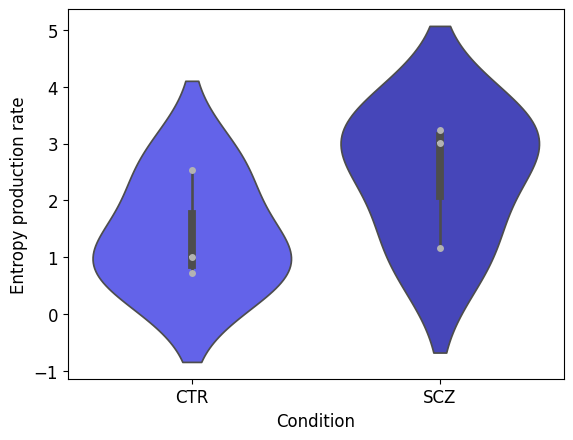

In [72]:
#%% plots

matplotlib.rc('font', size=12) 
matplotlib.rc('xtick', labelsize=12)
matplotlib.rc('ytick', labelsize=12)

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]]
cols2 = [[0.7,0.7,1],[0.6,0.6,1],[0.5,0.5,1],[0.4,0.4,1]]

EPR_tmp = dict()
EPR_tmp['sleep stage'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()
EPR_tmp['EPR'] = EPR.flatten()

EPR_df = pd.DataFrame(EPR_tmp)

#EPR_df=EPR_df.drop(index=13)


# real data

plt.figure()
ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)
sb.swarmplot(data=EPR_df, x='sleep stage', y='EPR', color=[0.7,0.7,0.7])
#plt.axis(ymin=-1.2, ymax=10)

plt.xlabel('Condition', fontsize=12)
plt.ylabel('Entropy production rate', fontsize=12)

#plt.savefig(res_dir+'entropy_prod_rate.eps', format='eps')

C:\Users\Bruna\AppData\Local\Temp\ipykernel_30792\2658677989.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data,


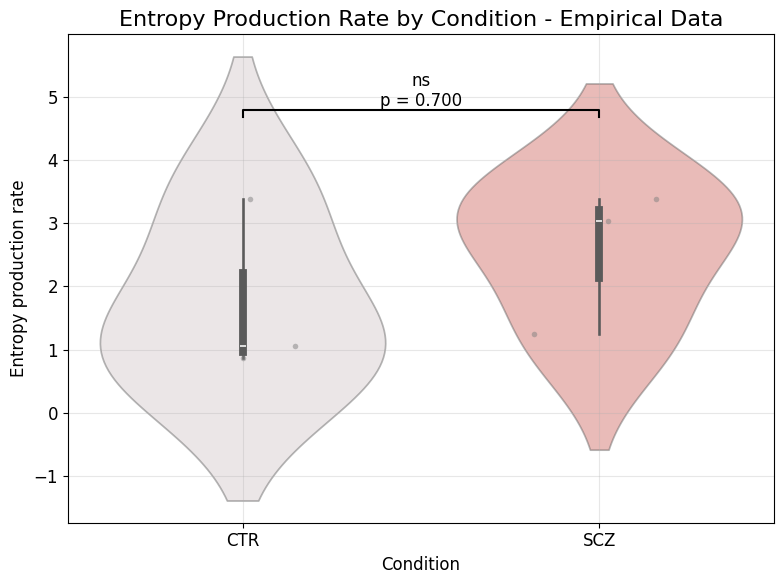


Statistical Test Results:
Mann-Whitney U test statistic: 3.00
p-value: 0.700


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Create sample data (replace with your actual data)
data = pd.DataFrame({
    'Condition': ['CTR']*n_sub + ['SCZ']*n_sub,
    'Entropy_production_rate': np.concatenate([
        EPR_df[EPR_df['sleep stage'] == 'CTR']['EPR'].tolist(),
        EPR_df[EPR_df['sleep stage'] == 'SCZ']['EPR'].tolist()
    ])
})

# Perform statistical test
ctr_data = data[data['Condition'] == 'CTR']['Entropy_production_rate']
scz_data = data[data['Condition'] == 'SCZ']['Entropy_production_rate']

# Perform Mann-Whitney U test (non-parametric test for independent samples)
statistic, p_value = stats.mannwhitneyu(ctr_data, scz_data, alternative='two-sided')

# Colors 
palette = {'CTR': '#D4C6C9', 'SCZ': '#E1544C'}

# Create the figure
plt.figure(figsize=(8, 6))

# Create violin plot
sns.violinplot(data=data, 
               x='Condition', 
               y='Entropy_production_rate',
               palette = palette,
               alpha=0.44)

# Add strip plot (individual points)
sns.stripplot(data=data,
             x='Condition',
             y='Entropy_production_rate',
             color='gray',
             alpha=0.5,
             jitter=0.2,
             size=4)

# Add significance bar
def add_stat_annotation(p_value):
    # Define the significance level markers
    if p_value < 0.001:
        star_string = '***'
    elif p_value < 0.01:
        star_string = '**'
    elif p_value < 0.05:
        star_string = '*'
    else:
        star_string = 'ns'
    
    # Get y coordinates for the bar
    y_max = data['Entropy_production_rate'].max()
    bar_height = y_max + 1.3
    
    # Plot the significance bar
    x1, x2 = 0, 1  # x-coordinates for CTR and SCZ
    bar_height_diff = 0.1
    
    plt.plot([x1, x1, x2, x2], 
            [bar_height, bar_height + bar_height_diff, bar_height + bar_height_diff, bar_height],
            'k-', linewidth=1.5)
    
    # Add star annotation
    plt.text((x1 + x2) * 0.5, bar_height + bar_height_diff,
            f'{star_string}\np = {p_value:.3f}',
            ha='center', va='bottom')

# Add the significance annotation
add_stat_annotation(p_value)

# Customize the plot
plt.title(f'Entropy Production Rate by Condition - {situations[situation_idx].capitalize()} Data', fontsize=16)
plt.xlabel('Condition')
plt.ylabel('Entropy production rate')
#plt.ylim(4, 14)  # Adjust the upper limit if needed to show the significance bar
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

#plt.savefig(res_dir+'entropy_prod_rate_statbar.png', format='png', dpi=300)
fig_path = os.path.join(presentation_figs_dir, f'entropy_prod_rate_statbar_{situations[situation_idx]}.{graph_format}')
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()

# Print statistical test results
print(f'\nStatistical Test Results:')
print(f'Mann-Whitney U test statistic: {statistic:.2f}')
print(f'p-value: {p_value:.3f}')

### Grid search for better hyperparameters for MOU fitting

In [ ]:
# Parameter sweep for MOUv2.fit (Lyapunov)
# Goal: improve distance, correlation, and especially distFC1.
from itertools import product
import numpy as np
import pandas as pd
import tqdm

# 1) Define which subject/condition pairs to use for tuning (keep small for speed)
max_sub_for_sweep = min(n_sub, 2)  # increase to n_sub for full sweep
eval_pairs = [(i_sub, i_cond) for i_sub in range(max_sub_for_sweep) for i_cond in range(n_cond)]
print("Sweep will evaluate pairs:", eval_pairs)

# 2) Hyperparameter grid
grid = {
    "algo_version": ["NeNe2020", "PCB2016"],
    "epsilon_C": [5e-4, 1e-3, 2e-3],
    "epsilon_Sigma": [5e-3, 1e-2, 2e-2],
    "regul_C": [0.0, 0.05, 0.1],
    "regul_Sigma": [0.0, 1e-3],
    "min_iter": [30, 50, 100],
    "max_iter": [2000],     # keep fixed for fair comparison
    "lim_FC": [0.05, 0.1],  # threshold used to build mask_EC from FC
}

keys = list(grid.keys())
values = [grid[k] for k in keys]
n_combos = int(np.prod([len(v) for v in values]))
print("Total parameter combinations:", n_combos)

records = []

for combo in tqdm.tqdm(product(*values), total=n_combos):
    params = dict(zip(keys, combo))

    dist_list = []
    corr_list = []
    distFC0_list = []
    distFC1_list = []
    iter_list = []
    fail_count = 0

    for i_sub, i_cond in eval_pairs:
        ts = new_array[i_sub, :, :, i_cond]  # shape: nodes x time

        # Rebuild EC mask exactly as in your main loop, but with sweepable lim_FC
        FC0 = np.corrcoef(ts)
        FC1 = FC0 / np.max(np.abs(FC0))
        mask_EC_local = np.zeros((N, N), dtype=bool)
        mask_EC_local[FC1 > params["lim_FC"]] = True
        for i in range(N):
            mask_EC_local[i, i] = False
            mask_EC_local[i, N - 1 - i] = True

        mou_est = MOUv2()
        try:
            mou_est.fit(
                ts.T,
                mask_C=mask_EC_local,
                mask_Sigma=mask_Sigma,
                algo_version=params["algo_version"],
                min_iter=params["min_iter"],
                max_iter=params["max_iter"],
                epsilon_C=params["epsilon_C"],
                epsilon_Sigma=params["epsilon_Sigma"],
                regul_C=params["regul_C"],
                regul_Sigma=params["regul_Sigma"],
                verbose=False,
            )
            d = mou_est.d_fit
            dist_list.append(float(d["distance"]))
            corr_list.append(float(d["correlation"]))
            distFC0_list.append(float(d.get("distFC0", np.nan)))
            distFC1_list.append(float(d.get("distFC1", np.nan)))
            iter_list.append(int(d["iterations"]))
        except Exception:
            fail_count += 1

    n_ok = len(dist_list)
    if n_ok == 0:
        continue

    records.append({
        "algo_version": params["algo_version"],
        "epsilon_C": params["epsilon_C"],
        "epsilon_Sigma": params["epsilon_Sigma"],
        "regul_C": params["regul_C"],
        "regul_Sigma": params["regul_Sigma"],
        "min_iter": params["min_iter"],
        "max_iter": params["max_iter"],
        "lim_FC": params["lim_FC"],
        "n_ok": n_ok,
        "n_fail": fail_count,
        "mean_distance": np.mean(dist_list),
        "std_distance": np.std(dist_list),
        "mean_corr": np.mean(corr_list),
        "std_corr": np.std(corr_list),
        "mean_distFC0": np.nanmean(distFC0_list),
        "mean_distFC1": np.nanmean(distFC1_list),
        "mean_iter": np.mean(iter_list),
        "max_iter_used": np.max(iter_list),
    })

results = pd.DataFrame(records)

# Ranking rule: prioritize lower distance and lower distFC1, then higher correlation
results = results.sort_values(
    by=["mean_distance", "mean_distFC1", "mean_corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\nTop 10 parameter sets:")
display(results.head(10))

best = results.iloc[0]
best_fit_kwargs = {
    "algo_version": best["algo_version"],
    "epsilon_C": float(best["epsilon_C"]),
    "epsilon_Sigma": float(best["epsilon_Sigma"]),
    "regul_C": float(best["regul_C"]),
    "regul_Sigma": float(best["regul_Sigma"]),
    "min_iter": int(best["min_iter"]),
    "max_iter": int(best["max_iter"]),
}
best_lim_FC = float(best["lim_FC"])

print("\nBest fit kwargs for your main loop:")
print(best_fit_kwargs)
print("Best lim_FC:", best_lim_FC)

Sweep will evaluate pairs: [(0, 0), (0, 1), (1, 0), (1, 1)]
Total parameter combinations: 648


  0%|          | 3/648 [00:51<3:05:15, 17.23s/it]


KeyboardInterrupt: 

In [ ]:
# Refit full dataset with best grid-search parameters
import numpy as np
import pandas as pd
import scipy.linalg as spl
import tqdm

best = results.iloc[0]
best_fit_kwargs = {
    "algo_version": best["algo_version"],
    "epsilon_C": float(best["epsilon_C"]),
    "epsilon_Sigma": float(best["epsilon_Sigma"]),
    "regul_C": float(best["regul_C"]),
    "regul_Sigma": float(best["regul_Sigma"]),
    "min_iter": int(best["min_iter"]),
    "max_iter": int(best["max_iter"]),
}
best_lim_FC = float(best["lim_FC"])

print("Best parameters:")
print(best_fit_kwargs)
print("best_lim_FC:", best_lim_FC)

# Keep current results as baseline if they exist
err_mod_baseline = None
fit_mod_baseline = None
iter_mod_baseline = None

# New arrays for best run
var_BOLD_best = np.zeros((n_sub, n_cond, N))
J_mod_best = np.zeros((n_sub, n_cond, N, N))
Sigma_mod_best = np.zeros((n_sub, n_cond, N, N))
FC0_mod_best = np.zeros((n_sub, n_cond, N, N))
err_mod_best = np.zeros((n_sub, n_cond))
fit_mod_best = np.zeros((n_sub, n_cond))
iter_mod_best = np.zeros((n_sub, n_cond), dtype=int)
distFC0_best = np.zeros((n_sub, n_cond))
distFC1_best = np.zeros((n_sub, n_cond))

for i_sub in tqdm.tqdm(range(n_sub), desc="Refit with best params"):
    for i_cond in range(n_cond):
        ts = new_array[i_sub, :, :, i_cond]
        var_BOLD_best[i_sub, i_cond, :] = ts.var(axis=1)

        FC0 = np.corrcoef(ts)
        FC1 = FC0 / np.max(np.abs(FC0))
        mask_EC_local = np.zeros((N, N), dtype=bool)
        mask_EC_local[FC1 > best_lim_FC] = True
        for i in range(N):
            mask_EC_local[i, i] = False
            mask_EC_local[i, N - 1 - i] = True

        mou_est = MOUv2()
        mou_est.fit(
            ts.T,
            mask_C=mask_EC_local,
            mask_Sigma=mask_Sigma,
            verbose=False,
            **best_fit_kwargs
        )

        d = mou_est.d_fit
        J_mod_best[i_sub, i_cond, :, :] = mou_est.J
        Sigma_mod_best[i_sub, i_cond, :, :] = mou_est.Sigma
        FC0_mod_best[i_sub, i_cond, :, :] = spl.solve_lyapunov(
            J_mod_best[i_sub, i_cond, :, :].T, -Sigma_mod_best[i_sub, i_cond, :, :]
        )
        err_mod_best[i_sub, i_cond] = float(d["distance"])
        fit_mod_best[i_sub, i_cond] = float(d["correlation"])
        iter_mod_best[i_sub, i_cond] = int(d["iterations"])
        distFC0_best[i_sub, i_cond] = float(d.get("distFC0", np.nan))
        distFC1_best[i_sub, i_cond] = float(d.get("distFC1", np.nan))

# Quick summary
summary_rows = []

if err_mod_baseline is not None:
    summary_rows.append({
        "run": "baseline",
        "mean_distance": float(np.mean(err_mod_baseline)),
        "mean_corr": float(np.mean(fit_mod_baseline)),
        "mean_iter": float(np.mean(iter_mod_baseline)) if iter_mod_baseline is not None else np.nan,
    })

summary_rows.append({
    "run": "best_grid_params",
    "mean_distance": float(np.mean(err_mod_best)),
    "mean_corr": float(np.mean(fit_mod_best)),
    "mean_iter": float(np.mean(iter_mod_best)),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("mean distFC0 (best):", float(np.nanmean(distFC0_best)))
print("mean distFC1 (best):", float(np.nanmean(distFC1_best)))

Best parameters:
{'algo_version': 'PCB2016', 'epsilon_C': 0.002, 'epsilon_Sigma': 0.01, 'regul_C': 0.1, 'regul_Sigma': 0.001, 'min_iter': 100, 'max_iter': 2000}
best_lim_FC: 0.1


Refit with best params: 100%|██████████| 3/3 [00:12<00:00,  4.03s/it]


,run,mean_distance,mean_corr,mean_iter
0,best_grid_params,0.767244,0.43538,102.0


mean distFC0 (best): 0.540366591522204
mean distFC1 (best): 0.9999267013397989


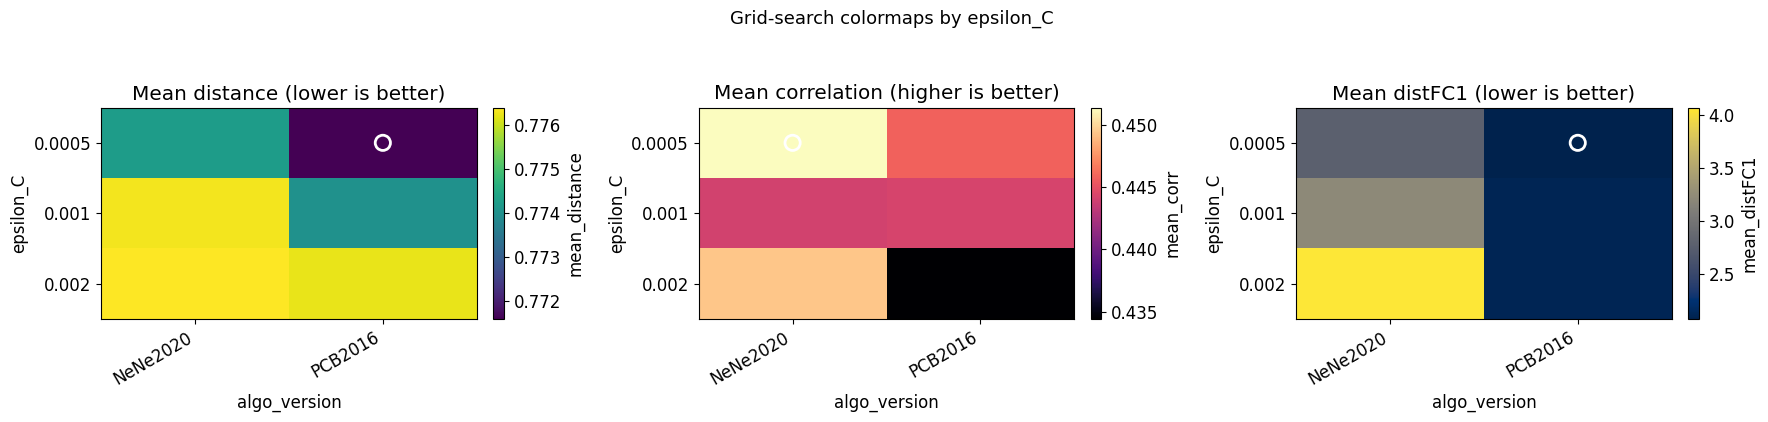

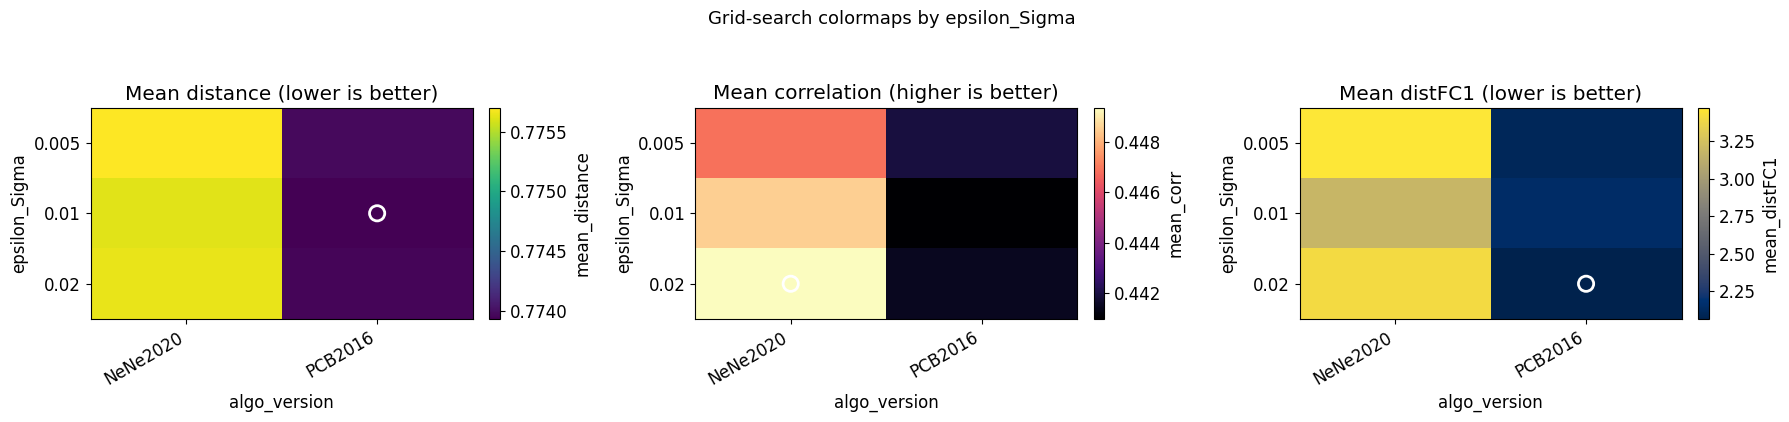

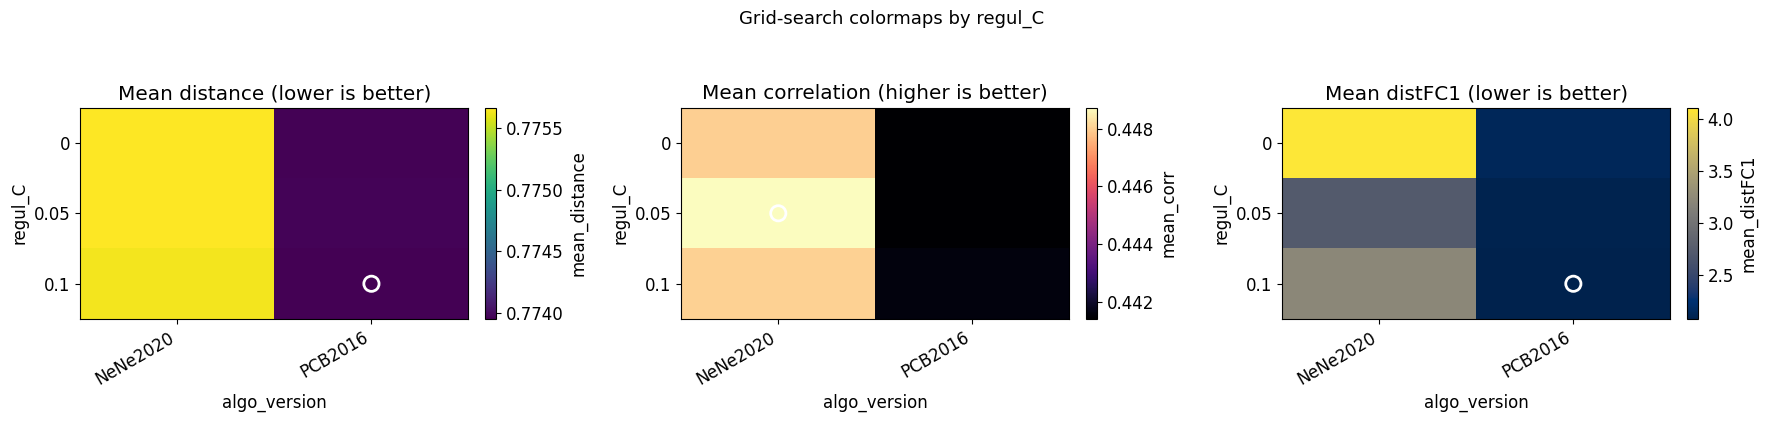

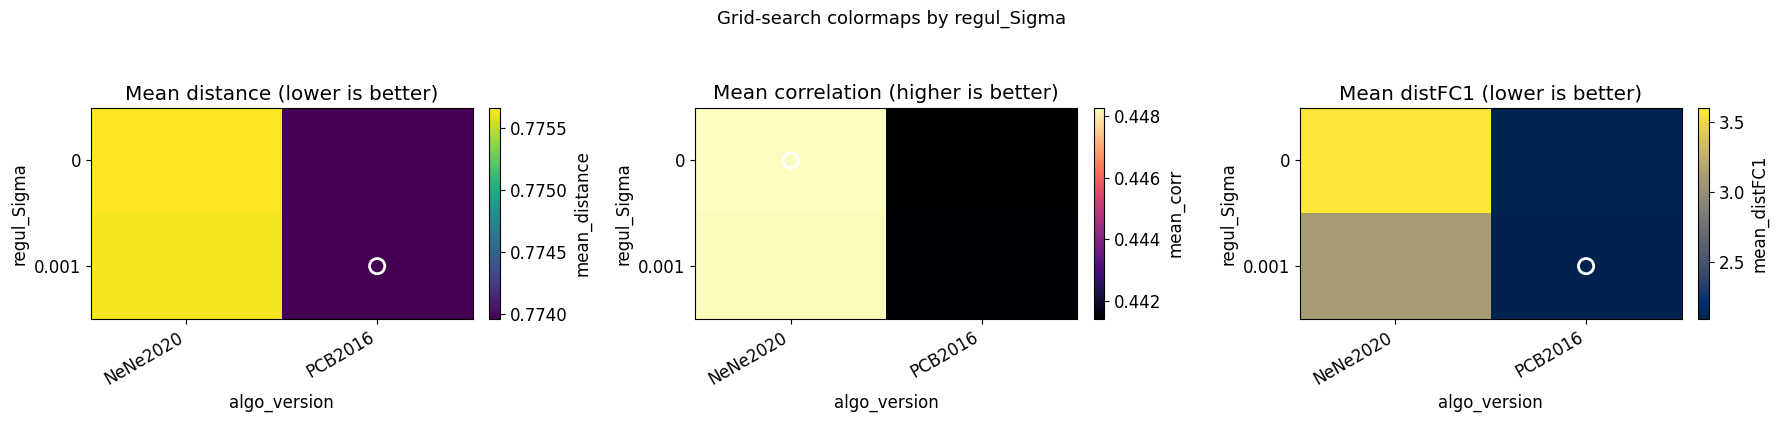

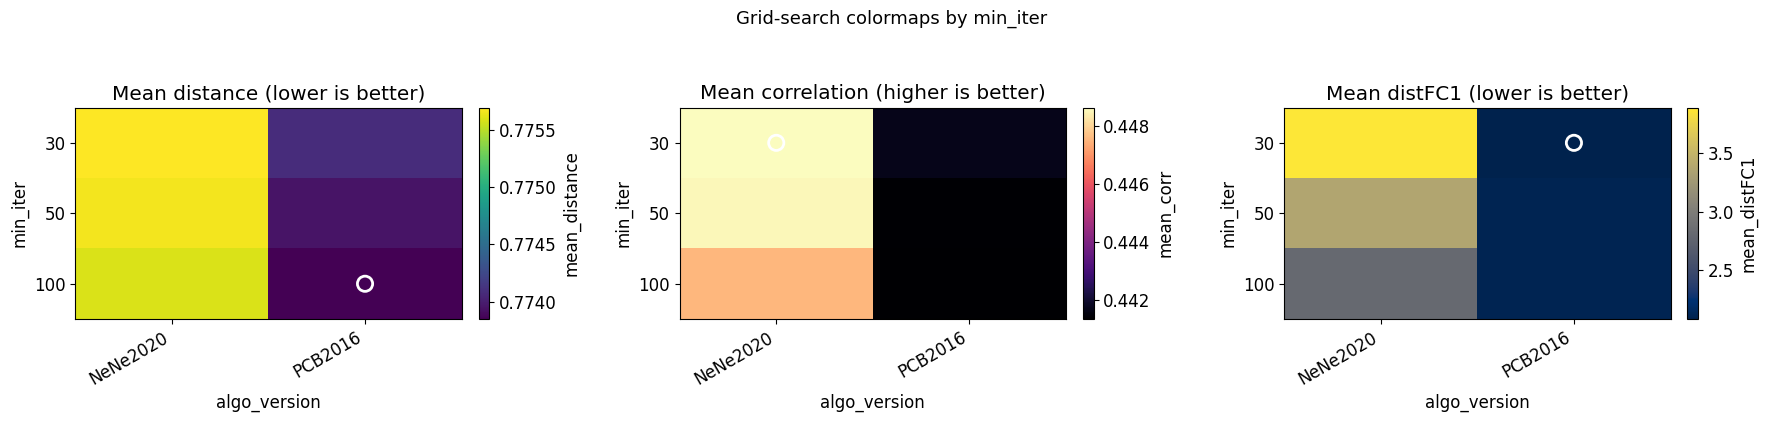

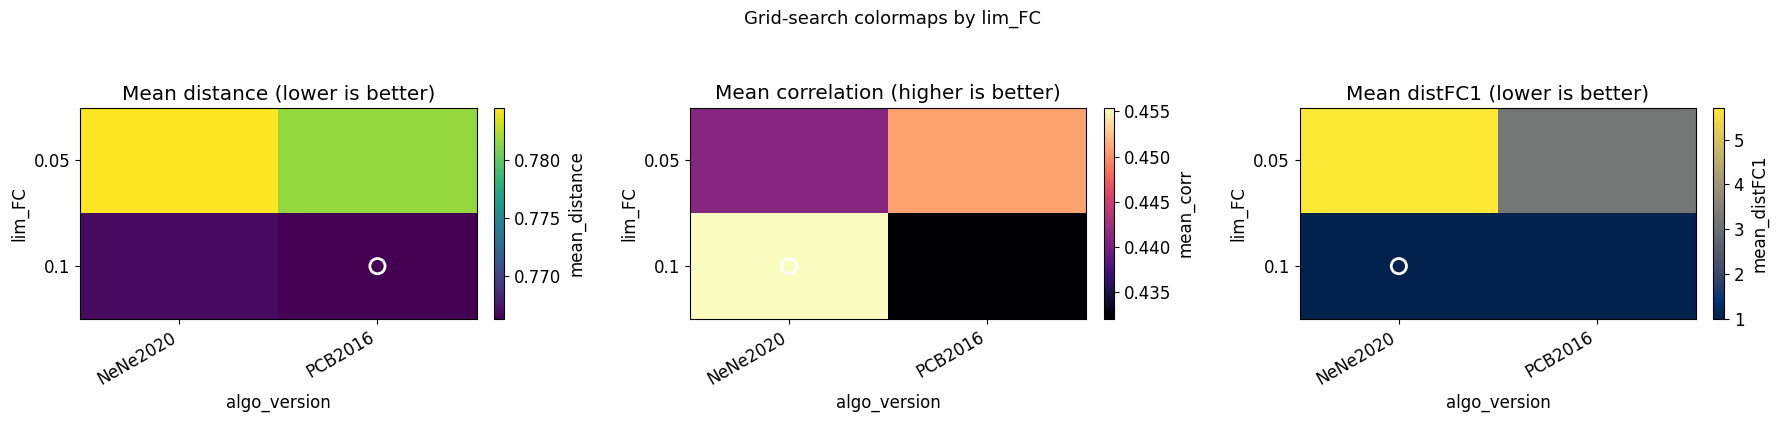

In [ ]:
# Colormap plots per parameter from grid-search results

#if "results" not in globals or results.empty:
 #   raise ValueError("No sweep results found. Run the grid-search cell first.")

params_to_plot = [
    "epsilon_C",
    "epsilon_Sigma",
    "regul_C",
    "regul_Sigma",
    "min_iter",
    "lim_FC",
]

metrics = [
    ("mean_distance", "Mean distance (lower is better)", "viridis", "min"),
    ("mean_corr", "Mean correlation (higher is better)", "magma", "max"),
    ("mean_distFC1", "Mean distFC1 (lower is better)", "cividis", "min"),
]

def _fmt(v):
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    return f"{float(v):.3g}"

for p in params_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, (metric, title, cmap, best_mode) in zip(axes, metrics):
        pt = results.pivot_table(
            index=p,
            columns="algo_version",
            values=metric,
            aggfunc="mean"
        ).sort_index()

        if pt.shape[0] == 0 or pt.shape[1] == 0:
            ax.set_axis_off()
            continue

        im = ax.imshow(pt.values, aspect="auto", cmap=cmap)

        ax.set_title(title)
        ax.set_xlabel("algo_version")
        ax.set_ylabel(p)
        ax.set_xticks(np.arange(len(pt.columns)))
        ax.set_xticklabels([str(c) for c in pt.columns], rotation=30, ha="right")
        ax.set_yticks(np.arange(len(pt.index)))
        ax.set_yticklabels([_fmt(v) for v in pt.index])

        # mark best cell on each heatmap
        vals = pt.values
        if best_mode == "min":
            iy, ix = np.unravel_index(np.nanargmin(vals), vals.shape)
        else:
            iy, ix = np.unravel_index(np.nanargmax(vals), vals.shape)
        ax.scatter(ix, iy, s=120, facecolors="none", edgecolors="white", linewidths=2)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.set_ylabel(metric, rotation=90)

    fig.suptitle(f"Grid-search colormaps by {p}", y=1.05, fontsize=13)
    plt.tight_layout()
    plt.show()